# Spike Detector GUI NPZ Analysis (SS/CS)

This notebook analyzes spike outputs saved by the Spike Detector GUI (`*_analyzed.npz`).

Included analyses:
1. Load and validate all sessions in a folder (same cell count required).
2. Compute SS and CS synchrony (correlation matrix, CCG, shuffle significance).
3. Compute how a user-defined behavior event time modulates SS and CS.

All parameters are centralized in the config cell below.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

NOTEBOOK_OUTPUT_CONFIG = {
    'table_top_n': 12,
    'pair_plot_limit': 6,
}

def display_top(df, n=None, label=None, sort_by=None, ascending=False):
    """Display a bounded, informative table without flooding notebook outputs."""
    n = int(NOTEBOOK_OUTPUT_CONFIG['table_top_n'] if n is None else n)
    view = df.sort_values(sort_by, ascending=ascending) if sort_by is not None and len(df) else df
    if label:
        print(f'{label}: showing {min(len(view), n)} of {len(view)} rows')
    display(view.head(n))

sns.set_theme(style='white', context='talk')
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.dpi': 120
})

In [2]:
# ==============================
# CONFIG
# ==============================
DATA_FOLDER = r'/Volumes/T7 Shield/20260611_A64_2PCs_1'  # root folder containing analyzed sessions
SESSION_GLOB = 'spike_detection/*_analyzed.npz'   # pattern: flat spike_detection/ folder

STRICT_CELL_NAME_MATCH = True  # require identical cell_names ordering across sessions

# Synchrony display options:
# mode: 'pooled' (default), 'per-session', or 'both'
# session_names: None -> all loaded sessions, or list like ['sessionA', 'sessionB']
SYNC_VIEW = {
    'mode': 'pooled',  # synchrony reporting mode
    'session_names': None,  # None means include all loaded sessions
    'show_pooled_heatmaps': True,  # pooled SS/CS correlation matrices
    'show_pooled_distributions': False,  # disabled: remove pooled pairwise synchrony / jitter z distributions
}

SYNC_CONFIG = {
    'sync_metric': 'sttc',  # 'pearson' (binned-count correlation) or 'sttc'
    'ss_bin_ms': 5.0,  # SS bin for Pearson; SS coincidence window for STTC
    'ss_max_lag_ms': 100.0,  # SS lag limit for pair CCG plots
    'cs_bin_ms': 28,  # CS bin for Pearson; CS coincidence window for STTC
    'cs_max_lag_ms': 800.0,  # CS lag limit for pair CCG plots
    'ccg_pairs_top_n': 5,  # top-N strongest pairs shown per session in per-session mode
}

# Optional exclusion of event-modulated response period from the first synchrony calculation block (Cell 8).
# When enabled, exclusion always uses SS_RESPONSE_WINDOW_MS and CS_RESPONSE_WINDOW_MS via EVENT_CONFIG.
SYNC_EXCLUDE_EVENT_MOD_WINDOW = {
    'enabled': False,  # True: remove spikes in response windows before synchrony computation
}

# CCG/ACG panel uses pooled selected sessions by default.
CCG_PANEL = {
    'enabled': True,
    'pooled': True,
    'sessions': 'all-selected',  # used when pooled=False: 'all-selected' | 'first' | 'max-cs' | specific name | list
    'pooled_title': 'Pooled selected sessions',
    'ss_acg_bin_ms': 0.5,
    'ss_acg_window_ms': 50.0,
    'ss_ccg_bin_ms': 0.5,
    'ss_ccg_window_ms': 50.0,
    'cs_ccg_bin_ms': 25.0,
    'cs_ccg_window_ms': 700.0,
    'smooth_sigma_bins': 1.0,
    'normalize': 'count',  # 'count' or 'prob'
    'grid_max_cols': 3,  # square-ish ACG/CCG layouts; blank panels are hidden
    'grid_panel_inches': 3.2,  # compact six-panel CCG layouts
    'grid_aspect': 1.25,  # slightly wider panels improve CCG lag visibility
    'max_ccg_pairs': 6,  # 4 highest + 2 lowest correlations when more pairs exist
}

# Event-centric settings (used in later cells too).
EVENT_CONFIG = {
    'event_time_ms': 10000.0,  # default event onset if no per-session behavior trace is available
    'event_detect_method': 'behavior_puff',  # 'behavior_puff' | 'fixed_time'
    'event_col': 'event_flag',  # behavior CSV column (1 indicates event frames)
    'event_threshold': 0.5,
    'event_min_separation_ms': 100.0,
    'event_csv_glob': 'behavior/*.csv',  # searched inside each session directory
    'event_csv_recursive': True,
    'event_csv_required': False,
    'event_alignment': 'session_time',  # 'session_time' or 'absolute'
    'event_rate_bin_ms': 10.0,
    'event_rate_window_ms': (-800.0, 1200.0),
    'event_sync_window_ms': (-300.0, 500.0),
    'event_sync_bin_ms': 5.0,
    'ss_rate_baseline_ms': (-400.0, -50.0),
    'ss_rate_response_ms': (50.0, 300.0),
    'cs_rate_baseline_ms': (-600.0, -100.0),
    'cs_rate_response_ms': (50.0, 500.0),
    'ss_sync_baseline_ms': (-300.0, -20.0),
    'ss_sync_response_ms': (20.0, 300.0),
    'cs_sync_baseline_ms': (-600.0, -50.0),
    'cs_sync_response_ms': (50.0, 500.0),
}

# One place for pair significance testing in synchrony matrices.
# p-values use a jitter null by default: each spike train is independently jittered
# within +/- jitter_ms, the selected synchrony metric is recomputed, and the observed
# value is compared with this null distribution. q-values are BH-FDR corrected p-values.
SIGNIFICANCE_TEST_CONFIG = {
    'enabled': True,
    'null_method': 'jitter',  # currently 'jitter' is used for matrix significance
    'n_null_shuffles': 1000,
    'seed': 123,
    'tail': 'two-sided',  # 'two-sided', 'right', 'left', or 'adaptive-one-sided'
    'ss_jitter_ms': 25.0,
    'cs_jitter_ms': 400.0,
    'p_floor_label': 1e-5,  # display as p<0.00001 or q<0.00001 below this value
}

SIGNIFICANCE_REPORT_CONFIG = {
    'metric': 'p',  # 'p' for selected p-value, or 'q' for BH-FDR q-value
    'alpha': 0.05,
    'show_on_plot': True,
}

EVENT_DETECTION_CONFIG = {
    'enabled': True,
}

EVENT_LIKELIHOOD_CONFIG = {
    'enabled': True,
}

SPIKE_STATS_CONFIG = {
    'enabled': True,
}

SS_EVENT_BIN_MS = float(EVENT_CONFIG['event_sync_bin_ms'])
CS_EVENT_BIN_MS = float(EVENT_CONFIG['event_sync_bin_ms'])
SS_INSPECTION_WINDOW_MS = tuple(EVENT_CONFIG['ss_sync_response_ms'])
CS_INSPECTION_WINDOW_MS = tuple(EVENT_CONFIG['cs_sync_response_ms'])
SS_RATE_BASELINE_MS = tuple(EVENT_CONFIG['ss_rate_baseline_ms'])
SS_RATE_RESPONSE_MS = tuple(EVENT_CONFIG['ss_rate_response_ms'])
CS_RATE_BASELINE_MS = tuple(EVENT_CONFIG['cs_rate_baseline_ms'])
CS_RATE_RESPONSE_MS = tuple(EVENT_CONFIG['cs_rate_response_ms'])
SS_SYNC_BASELINE_MS = tuple(EVENT_CONFIG['ss_sync_baseline_ms'])
SS_SYNC_RESPONSE_MS = tuple(EVENT_CONFIG['ss_sync_response_ms'])
CS_SYNC_BASELINE_MS = tuple(EVENT_CONFIG['cs_sync_baseline_ms'])
CS_SYNC_RESPONSE_MS = tuple(EVENT_CONFIG['cs_sync_response_ms'])
EVENT_ONSET_MS = float(EVENT_CONFIG['event_time_ms'])

EXPORT_RESULTS = True
EXPORT_PLOTS = True
EXPORT_DIR = os.path.join(DATA_FOLDER, 'analysis_exports', 'svg')

# Keep text as text objects in SVG so Adobe Illustrator can edit labels directly.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['svg.hashsalt'] = 'spike_detector_syn'

_AUTO_SVG_COUNTER = 0

def _sanitize_export_stem(stem):
    s = ''.join(ch if ch.isalnum() or ch in ('-', '_', '.') else '_' for ch in str(stem))
    s = s.strip('._')
    return s or 'figure'

def _save_fig_svg(fig, stem, export_plots=None, export_dir=None):
    do_export = EXPORT_PLOTS if export_plots is None else bool(export_plots)
    if not do_export or fig is None:
        return None
    target_dir = EXPORT_DIR if export_dir is None else str(export_dir)
    os.makedirs(target_dir, exist_ok=True)
    clean_stem = _sanitize_export_stem(stem)
    file_path = os.path.join(target_dir, f'{clean_stem}.svg')
    fig.savefig(file_path, format='svg', bbox_inches='tight')
    return file_path

if not hasattr(plt, '_auto_svg_show_original'):
    plt._auto_svg_show_original = plt.show

def _show_with_auto_svg(*args, **kwargs):
    global _AUTO_SVG_COUNTER
    if bool(globals().get('EXPORT_PLOTS', False)):
        export_dir = globals().get('EXPORT_DIR', EXPORT_DIR)
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            _AUTO_SVG_COUNTER += 1
            stem = f'auto_{_AUTO_SVG_COUNTER:04d}_fig{int(fig_num):03d}'
            _save_fig_svg(fig, stem, export_plots=True, export_dir=export_dir)
    return plt._auto_svg_show_original(*args, **kwargs)

plt.show = _show_with_auto_svg

print('Config ready.')
print(f'DATA_FOLDER: {DATA_FOLDER}')
print(f'SYNC metric: {SYNC_CONFIG["sync_metric"]}')
print(f'SYNC mode: {SYNC_VIEW["mode"]} | show_pooled_distributions={SYNC_VIEW["show_pooled_distributions"]}')
print(f'SVG auto-export: {EXPORT_PLOTS} -> {EXPORT_DIR}')
print('SVG text mode: svg.fonttype=none (editable text in Adobe Illustrator if font is available).')

Config ready.
DATA_FOLDER: /Volumes/T7 Shield/20260611_A64_2PCs_1
SYNC metric: sttc
SYNC mode: pooled | show_pooled_distributions=False
SVG auto-export: True -> /Volumes/T7 Shield/20260611_A64_2PCs_1/analysis_exports/svg
SVG text mode: svg.fonttype=none (editable text in Adobe Illustrator if font is available).


In [3]:
# Global correlation-heatmap color scaling (user setting)
# Fixed range used consistently by all correlation matrices using cmap='vlag'.
CORR_HEATMAP_SCALE = {
    'enabled': True,
    'vmin': -0.1,
    'vmax': 0.1,
    'center': 0.0,
    'apply_to_vlag_only': True,
}

# Shared typography and significance display for every synchrony matrix.
CORR_MATRIX_STYLE = {
    'value_fontsize': 10,
    'stat_fontsize': 7,
    'cell_name_fontsize': 9,
    'title_fontsize': 12,
    'colorbar_label_fontsize': 9,
    'colorbar_tick_fontsize': 8,
    'value_fontweight': 'bold',
}

# Install a safe seaborn heatmap wrapper once; rerunning this cell updates settings only.
if not hasattr(sns, '_heatmap_original'):
    sns._heatmap_original = sns.heatmap


def _heatmap_with_corr_scale(*args, **kwargs):
    cfg = globals().get('CORR_HEATMAP_SCALE', {})
    if bool(cfg.get('enabled', True)):
        use_map = True
        if bool(cfg.get('apply_to_vlag_only', True)):
            use_map = (kwargs.get('cmap', None) == 'vlag')
        if use_map:
            kwargs['vmin'] = float(cfg.get('vmin', -0.1))
            kwargs['vmax'] = float(cfg.get('vmax', 0.1))
            kwargs['center'] = float(cfg.get('center', 0.0))
    ax = sns._heatmap_original(*args, **kwargs)
    style = globals().get('CORR_MATRIX_STYLE', {})
    tick_fs = float(style.get('cell_name_fontsize', 9))
    ax.tick_params(axis='x', labelsize=tick_fs)
    ax.tick_params(axis='y', labelsize=tick_fs)
    if getattr(ax, 'collections', None):
        cbar = ax.collections[0].colorbar
        if cbar is not None:
            cbar.ax.tick_params(labelsize=float(style.get('colorbar_tick_fontsize', 8)))
            cbar.set_label(cbar.ax.get_ylabel(), size=float(style.get('colorbar_label_fontsize', 9)))
    return ax


sns.heatmap = _heatmap_with_corr_scale
print(f"CORR_HEATMAP_SCALE active: enabled={CORR_HEATMAP_SCALE['enabled']}, range=[{CORR_HEATMAP_SCALE['vmin']}, {CORR_HEATMAP_SCALE['vmax']}]")

CORR_HEATMAP_SCALE active: enabled=True, range=[-0.1, 0.1]


## Event-Modulated Spike Likelihood: Definition and Computation

This notebook reports both event-locked rate and event-locked spike likelihood.
They answer different questions and should be interpreted together.

- Event-locked rate asks: how many spikes per second are emitted over time around the event.
- Event-locked likelihood asks: what is the probability that at least one spike occurred in each time bin around the event.

For likelihood at time bin $b$ with bin width $\Delta t$, each cell-session trace contributes a binary value:

$$
L_{k,b}=\begin{cases}
1, & \text{if at least one spike falls in bin } b \\
0, & \text{otherwise}
\end{cases}
$$

where $k$ indexes each pooled trace (cell $\times$ session).
The pooled likelihood curve is then

$$
\hat{p}_b = \frac{1}{K}\sum_{k=1}^{K} L_{k,b}
$$

with standard error

$$
\mathrm{SEM}_b = \sqrt{\frac{\hat{p}_b(1-\hat{p}_b)}{K}}
$$

This makes likelihood robust for sparse events (especially CS), while rate better captures response magnitude for high-rate activity (especially SS).

How to tune windows for event-modulated pair synchrony (Cell 10):

- Set SS event-modulated period with `SS_RATE_RESPONSE_MS` for rate/likelihood, `SS_SYNC_RESPONSE_MS` for sync).
- Set CS event-modulated period with `CS_RATE_RESPONSE_MS` for rate/likelihood, `CS_SYNC_RESPONSE_MS` for sync).
- Baselines are set by `SS_BASELINE_WINDOW_MS` and `CS_BASELINE_WINDOW_MS`.

In [4]:
REQUIRED_KEYS = [
    'time_ms', 'raw_data', 'cs_traces', 'ss_traces',
    'spike_times_cs', 'spike_times_ss', 'cell_names', 'fs', 'raw_sigmas'
]

def _to_1d_float_array(x):
    arr = np.asarray(x, dtype=float).reshape(-1)
    return arr[np.isfinite(arr)]

def _validate_and_normalize_session(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    missing = [k for k in REQUIRED_KEYS if k not in d.files]
    if missing:
        raise ValueError(f'Missing keys: {missing}')

    time_ms = _to_1d_float_array(d['time_ms'])
    if len(time_ms) < 2:
        raise ValueError('time_ms has fewer than 2 samples')

    raw_data = np.asarray(d['raw_data'])
    if raw_data.ndim != 2:
        raise ValueError('raw_data must be 2D [samples, cells]')

    n_samples, n_cells = raw_data.shape
    if len(time_ms) != n_samples:
        raise ValueError(f'time_ms length ({len(time_ms)}) != raw_data samples ({n_samples})')

    cell_names = [str(c) for c in np.asarray(d['cell_names']).tolist()]
    if len(cell_names) != n_cells:
        raise ValueError('cell_names length does not match n_cells')

    spike_times_ss_raw = np.asarray(d['spike_times_ss'], dtype=object)
    spike_times_cs_raw = np.asarray(d['spike_times_cs'], dtype=object)
    if len(spike_times_ss_raw) != n_cells or len(spike_times_cs_raw) != n_cells:
        raise ValueError('spike_times arrays must have one entry per cell')

    spike_times_ss = [_to_1d_float_array(spike_times_ss_raw[i]) for i in range(n_cells)]
    spike_times_cs = [_to_1d_float_array(spike_times_cs_raw[i]) for i in range(n_cells)]

    t0 = float(time_ms[0])
    t1 = float(time_ms[-1])
    for i in range(n_cells):
        spike_times_ss[i] = spike_times_ss[i][(spike_times_ss[i] >= t0) & (spike_times_ss[i] <= t1)]
        spike_times_cs[i] = spike_times_cs[i][(spike_times_cs[i] >= t0) & (spike_times_cs[i] <= t1)]

    dt = np.median(np.diff(time_ms))
    fs_from_time = 1000.0 / dt if dt > 0 else np.nan

    # Derive session name from filename (strip '_analyzed' suffix)
    _fname = os.path.splitext(os.path.basename(npz_path))[0]
    session_name = _fname.replace('_analyzed', '')

    return {
        'session_name': session_name,
        'npz_path': npz_path,
        'time_ms': time_ms,
        'duration_ms': t1 - t0,
        'n_cells': n_cells,
        'cell_names': cell_names,
        'spike_times_ss': spike_times_ss,
        'spike_times_cs': spike_times_cs,
        'fs': float(d['fs']),
        'fs_from_time': fs_from_time,
    }

def load_sessions(data_folder, session_glob='spike_detection/*_analyzed.npz', strict_cell_name_match=True):
    paths = sorted(glob.glob(os.path.join(data_folder, session_glob)))
    if not paths:
        raise FileNotFoundError(f'No session files found at {os.path.join(data_folder, session_glob)}')

    loaded = []
    excluded = []
    ref_n_cells = None
    ref_cell_names = None

    for p in paths:
        try:
            s = _validate_and_normalize_session(p)
            if ref_n_cells is None:
                ref_n_cells = s['n_cells']
                ref_cell_names = s['cell_names']
            else:
                if s['n_cells'] != ref_n_cells:
                    raise ValueError(f'n_cells mismatch: {s["n_cells"]} vs reference {ref_n_cells}')
                if strict_cell_name_match and s['cell_names'] != ref_cell_names:
                    raise ValueError('cell_names mismatch (strict mode)')
            loaded.append(s)
        except Exception as e:
            excluded.append({'path': p, 'reason': str(e)})

    if not loaded:
        raise RuntimeError('All session files failed validation.')

    return loaded, excluded

In [5]:
sessions, excluded_sessions = load_sessions(
    DATA_FOLDER,
    session_glob=SESSION_GLOB,
    strict_cell_name_match=STRICT_CELL_NAME_MATCH,
)

print(f'Loaded sessions: {len(sessions)}')
print(f'Excluded sessions: {len(excluded_sessions)}')
if excluded_sessions:
    print('\nExcluded details:')
    for ex in excluded_sessions:
        print(f'- {ex["path"]}\n  reason: {ex["reason"]}')

n_cells = sessions[0]['n_cells']
cell_names = sessions[0]['cell_names']
summary_df = pd.DataFrame([{
    'session': s['session_name'],
    'duration_ms': s['duration_ms'],
    'n_cells': s['n_cells'],
    'ss_total_spikes': int(sum(len(x) for x in s['spike_times_ss'])),
    'cs_total_spikes': int(sum(len(x) for x in s['spike_times_cs'])),
    'fs_saved': s['fs'],
    'fs_from_time': s['fs_from_time'],
} for s in sessions])
display_top(summary_df, label='Loaded-session summary')

Loaded sessions: 9
Excluded sessions: 1

Excluded details:
- /Volumes/T7 Shield/20260611_A64_2PCs_1/spike_detection/pair_9_analyzed.npz
  reason: n_cells mismatch: 3 vs reference 2


,session,duration_ms,n_cells,ss_total_spikes,cs_total_spikes,fs_saved,fs_from_time
0,pair_10,9999.84,2,365,19,4166.666667,4166.666667
1,pair_11,9999.84,2,437,17,4166.666667,4166.666667
2,pair_13,9999.84,2,403,13,4166.666667,4166.666667
3,pair_14,9999.84,2,400,18,4166.666667,4166.666667
4,pair_15,9999.84,2,402,14,4166.666667,4166.666667
5,pair_4,9999.84,2,368,21,4166.666667,4166.666667
6,pair_5,9999.84,2,353,23,4166.666667,4166.666667
7,pair_7,9999.84,2,421,17,4166.666667,4166.666667
8,pair_8,9999.84,2,415,21,4166.666667,4166.666667


In [6]:
# Shared export helper used by downstream plotting cells
def _save_fig_svg(fig, stem, export_plots=None, export_dir=None):
    do_export = EXPORT_PLOTS if export_plots is None else bool(export_plots)
    if not do_export:
        return None

    out_dir = EXPORT_DIR if export_dir is None else str(export_dir)
    os.makedirs(out_dir, exist_ok=True)
    file_path = os.path.join(out_dir, f"{stem}.svg")
    fig.savefig(file_path, format='svg', bbox_inches='tight')
    return file_path

print('Defined _save_fig_svg helper.')

Defined _save_fig_svg helper.


Spike statistics section is enabled (before synchrony).

Pooled spike statistics by spike type:


,spike_type,n_sessions,n_cells_x_sessions,total_spikes,rate_hz_mean,rate_hz_median,isi_mean_ms_mean,isi_median_ms_median,isi_cv_mean,traces_with_isi
0,CS,9,18,163,0.905570,0.950015,1249.559947,342.3,1.253921,18
1,SS,9,18,3564,19.800317,19.100306,57.775075,39.0,0.912402,18



Per-cell pooled spike statistics (across sessions):


,spike_type,cell,cell_idx,n_sessions,mean_n_spikes,mean_rate_hz,mean_isi_ms,median_isi_ms,mean_isi_cv
0,CS,avr (UG)(),0,9,12.666667,1.266687,689.735767,191.40,1.352636
1,CS,avr (UG)().1,1,9,5.444444,0.544453,1809.384127,825.84,1.142867
2,SS,avr (UG)(),0,9,125.888889,12.589090,78.920669,53.40,0.911284
3,SS,avr (UG)().1,1,9,270.111111,27.011543,36.629482,27.36,0.913519


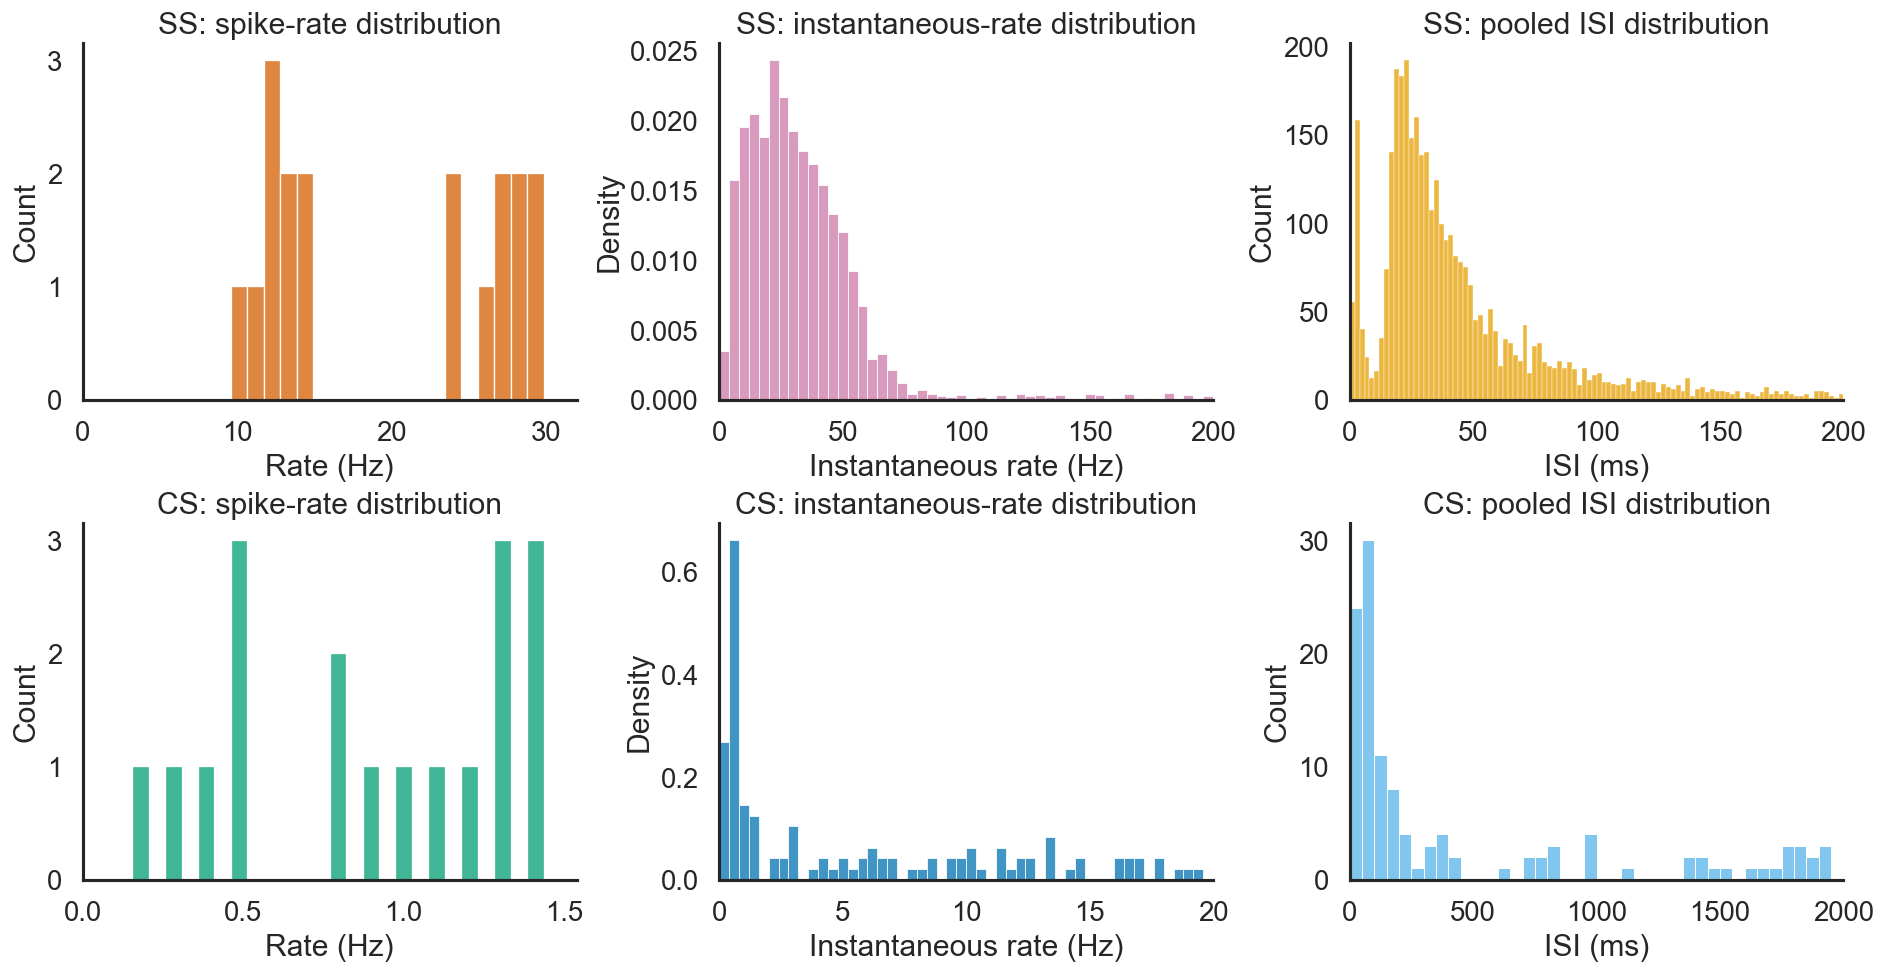

In [7]:
# Spike statistics before synchronization (pooled + per-cell, configurable by SPIKE_STATS_CONFIG).
def _compute_trace_spike_stats(spike_times, duration_s, min_spikes_for_isi=2):
    st = np.sort(np.asarray(spike_times, dtype=float))
    st = st[np.isfinite(st)]
    n_spikes = int(st.size)
    rate_hz = float(n_spikes / duration_s) if duration_s > 0 else np.nan

    if n_spikes >= int(min_spikes_for_isi):
        isi = np.diff(st)
        isi = isi[np.isfinite(isi) & (isi > 0)]
    else:
        isi = np.array([], dtype=float)

    if isi.size > 0:
        isi_mean = float(np.mean(isi))
        isi_median = float(np.median(isi))
        isi_cv = float(np.std(isi, ddof=1) / (isi_mean + 1e-12)) if isi.size > 1 else np.nan
        inst_rate_hz = 1000.0 / isi
        inst_rate_hz = inst_rate_hz[np.isfinite(inst_rate_hz) & (inst_rate_hz > 0)]
    else:
        isi_mean = np.nan
        isi_median = np.nan
        isi_cv = np.nan
        inst_rate_hz = np.array([], dtype=float)

    return {
        'n_spikes': n_spikes,
        'rate_hz': rate_hz,
        'isi_mean_ms': isi_mean,
        'isi_median_ms': isi_median,
        'isi_cv': isi_cv,
        'n_isi': int(isi.size),
        'isi_values_ms': isi,
        'inst_rate_hz': inst_rate_hz,
    }

def _build_spike_stats_tables(sessions_local, spike_types=('SS', 'CS'), min_spikes_for_isi=2):
    rows = []
    isi_pool = {stype: [] for stype in spike_types}
    inst_rate_pool = {stype: [] for stype in spike_types}

    for s in sessions_local:
        duration_s = float(s['duration_ms']) / 1000.0
        for stype in spike_types:
            spikes_by_cell = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
            for i, st in enumerate(spikes_by_cell):
                stats = _compute_trace_spike_stats(st, duration_s, min_spikes_for_isi=min_spikes_for_isi)
                rows.append({
                    'session': s['session_name'],
                    'spike_type': stype,
                    'cell': s['cell_names'][i],
                    'cell_idx': int(i),
                    'duration_s': duration_s,
                    'n_spikes': stats['n_spikes'],
                    'rate_hz': stats['rate_hz'],
                    'isi_mean_ms': stats['isi_mean_ms'],
                    'isi_median_ms': stats['isi_median_ms'],
                    'isi_cv': stats['isi_cv'],
                    'n_isi': stats['n_isi'],
                })
                if stats['n_isi'] > 0:
                    isi_pool[stype].append(stats['isi_values_ms'])
                if stats['inst_rate_hz'].size > 0:
                    inst_rate_pool[stype].append(stats['inst_rate_hz'])

    detail_df = pd.DataFrame(rows)
    for stype in isi_pool:
        isi_pool[stype] = np.concatenate(isi_pool[stype]) if len(isi_pool[stype]) else np.array([], dtype=float)
    for stype in inst_rate_pool:
        inst_rate_pool[stype] = np.concatenate(inst_rate_pool[stype]) if len(inst_rate_pool[stype]) else np.array([], dtype=float)
    return detail_df, isi_pool, inst_rate_pool

def _resolve_plot_max(vals, cfg_max=None, q=0.995, fallback=1.0):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return float(fallback)
    if cfg_max is not None:
        return max(float(cfg_max), float(np.min(vals) * 1.05), float(fallback))
    qv = float(np.quantile(vals, float(q)))
    vmax = max(qv * 1.1, float(np.max(vals) * 1.02 if vals.size < 20 else qv * 1.1), float(fallback))
    return float(vmax)

if SPIKE_STATS_CONFIG.get('enabled', True):
    spike_types = [str(x).upper() for x in SPIKE_STATS_CONFIG.get('spike_types', ['SS', 'CS'])]
    spike_types = [x for x in spike_types if x in {'SS', 'CS'}]
    if not spike_types:
        spike_types = ['SS', 'CS']

    min_spikes_for_isi = int(SPIKE_STATS_CONFIG.get('min_spikes_for_isi', 2))
    detail_df, pooled_isi, pooled_inst_rate = _build_spike_stats_tables(
        sessions,
        spike_types=tuple(spike_types),
        min_spikes_for_isi=min_spikes_for_isi,
    )

    print('Spike statistics section is enabled (before synchrony).')

    if SPIKE_STATS_CONFIG.get('show_pooled_summary', True):
        pooled_summary = (detail_df.groupby('spike_type', as_index=False)
                          .agg(n_sessions=('session', 'nunique'),
                               n_cells_x_sessions=('cell', 'count'),
                               total_spikes=('n_spikes', 'sum'),
                               rate_hz_mean=('rate_hz', 'mean'),
                               rate_hz_median=('rate_hz', 'median'),
                               isi_mean_ms_mean=('isi_mean_ms', 'mean'),
                               isi_median_ms_median=('isi_median_ms', 'median'),
                               isi_cv_mean=('isi_cv', 'mean'),
                               traces_with_isi=('n_isi', lambda x: int(np.sum(np.asarray(x) > 0)))))
        print('\nPooled spike statistics by spike type:')
        display(pooled_summary)

    if SPIKE_STATS_CONFIG.get('show_cell_summary_table', True):
        cell_summary = (detail_df.groupby(['spike_type', 'cell', 'cell_idx'], as_index=False)
                        .agg(n_sessions=('session', 'nunique'),
                             mean_n_spikes=('n_spikes', 'mean'),
                             mean_rate_hz=('rate_hz', 'mean'),
                             mean_isi_ms=('isi_mean_ms', 'mean'),
                             median_isi_ms=('isi_median_ms', 'median'),
                             mean_isi_cv=('isi_cv', 'mean')))
        max_rows_cell = int(SPIKE_STATS_CONFIG.get('max_rows_cell_summary_table', 30))
        print('\nPer-cell pooled spike statistics (across sessions):')
        display(cell_summary.head(max_rows_cell))

    if SPIKE_STATS_CONFIG.get('show_session_cell_table', False):
        max_rows_detail = int(SPIKE_STATS_CONFIG.get('max_rows_session_cell_table', 30))
        print('\nDetailed per-session/per-cell spike statistics:')
        display(detail_df.head(max_rows_detail))

    if SPIKE_STATS_CONFIG.get('show_plots', True):
        show_inst = bool(SPIKE_STATS_CONFIG.get('show_instantaneous_rate_plot', True))
        ncols = 3 if show_inst else 2
        fig, axes = plt.subplots(2, ncols, figsize=(5.2 * ncols, 8), constrained_layout=True)
        axes = np.atleast_2d(axes)

        rate_stat = str(SPIKE_STATS_CONFIG.get('rate_hist_stat', 'count')).lower()
        if rate_stat not in {'count', 'density'}:
            rate_stat = 'count'
        inst_stat = str(SPIKE_STATS_CONFIG.get('inst_rate_hist_stat', 'density')).lower()
        if inst_stat not in {'count', 'density'}:
            inst_stat = 'density'

        for row_idx, stype in enumerate(['SS', 'CS']):
            if stype not in spike_types:
                for c in range(ncols):
                    axes[row_idx, c].axis('off')
                continue

            sub = detail_df[detail_df['spike_type'] == stype]
            rate_color = '#D55E00' if stype == 'SS' else '#009E73'
            isi_color = '#E69F00' if stype == 'SS' else '#56B4E9'
            inst_color = '#CC79A7' if stype == 'SS' else '#0072B2'

            # 1) Spike-rate distribution
            ax_rate = axes[row_idx, 0]
            if len(sub) > 0 and np.isfinite(sub['rate_hz']).any():
                rate_vals = sub['rate_hz'].dropna().values
                rate_max_cfg = SPIKE_STATS_CONFIG.get('ss_rate_plot_max_hz', None) if stype == 'SS' else SPIKE_STATS_CONFIG.get('cs_rate_plot_max_hz', None)
                rate_q = float(SPIKE_STATS_CONFIG.get('ss_rate_plot_max_quantile', 0.995) if stype == 'SS' else SPIKE_STATS_CONFIG.get('cs_rate_plot_max_quantile', 0.995))
                rate_max = _resolve_plot_max(rate_vals, cfg_max=rate_max_cfg, q=rate_q, fallback=1.0)
                rate_bins = int(SPIKE_STATS_CONFIG.get('ss_rate_n_bins', 30) if stype == 'SS' else SPIKE_STATS_CONFIG.get('cs_rate_n_bins', 30))
                rate_edges = np.linspace(0.0, max(1e-6, rate_max), max(5, rate_bins) + 1)
                sns.histplot(rate_vals, bins=rate_edges, stat=rate_stat, ax=ax_rate, color=rate_color)
                ax_rate.set_xlim(0.0, rate_max)
            else:
                ax_rate.text(0.5, 0.5, f'No valid {stype} rate values', ha='center', va='center', transform=ax_rate.transAxes)
            ax_rate.set_title(f'{stype}: spike-rate distribution')
            ax_rate.set_xlabel('Rate (Hz)')
            ax_rate.set_ylabel('Count' if rate_stat == 'count' else 'Density')
            ax_rate.grid(False)

            # 2) Instantaneous spike-rate distribution (next to spike-rate distribution)
            if show_inst:
                ax_inst = axes[row_idx, 1]
                inst_vals = pooled_inst_rate.get(stype, np.array([], dtype=float))
                if inst_vals.size > 0:
                    inst_max = float(SPIKE_STATS_CONFIG.get('ss_inst_rate_plot_max_hz', 200.0) if stype == 'SS' else SPIKE_STATS_CONFIG.get('cs_inst_rate_plot_max_hz', 20.0))
                    inst_bins = int(SPIKE_STATS_CONFIG.get('ss_inst_rate_n_bins', 50) if stype == 'SS' else SPIKE_STATS_CONFIG.get('cs_inst_rate_n_bins', 50))
                    inst_edges = np.linspace(0.0, max(1e-6, inst_max), max(5, inst_bins) + 1)
                    sns.histplot(inst_vals, bins=inst_edges, stat=inst_stat, ax=ax_inst, color=inst_color)
                    ax_inst.set_xlim(0.0, inst_max)
                else:
                    ax_inst.text(0.5, 0.5, f'No valid {stype} instantaneous rates', ha='center', va='center', transform=ax_inst.transAxes)
                ax_inst.set_title(f'{stype}: instantaneous-rate distribution')
                ax_inst.set_xlabel('Instantaneous rate (Hz)')
                ax_inst.set_ylabel('Count' if inst_stat == 'count' else 'Density')
                ax_inst.grid(False)

            # 3) ISI distribution
            isi_col = 2 if show_inst else 1
            ax_isi = axes[row_idx, isi_col]
            isi_vals = pooled_isi.get(stype, np.array([], dtype=float))
            if isi_vals.size > 0:
                if stype == 'SS':
                    _isi_bins = int(SPIKE_STATS_CONFIG.get('ss_isi_n_bins', 100))
                    _isi_max = float(SPIKE_STATS_CONFIG.get('ss_isi_plot_max_ms', 200.0))
                else:
                    _isi_bins = int(SPIKE_STATS_CONFIG.get('cs_isi_n_bins', 40))
                    _isi_max = float(SPIKE_STATS_CONFIG.get('cs_isi_plot_max_ms', 2000.0))
                _isi_edges = np.linspace(0, _isi_max, _isi_bins + 1)
                sns.histplot(isi_vals, bins=_isi_edges, stat='count', ax=ax_isi, color=isi_color)
                ax_isi.set_xlim(0, _isi_max)
            else:
                ax_isi.text(0.5, 0.5, f'No valid {stype} ISI values', ha='center', va='center', transform=ax_isi.transAxes)
            ax_isi.set_title(f'{stype}: pooled ISI distribution')
            ax_isi.set_xlabel('ISI (ms)')
            ax_isi.set_ylabel('Count')
            ax_isi.grid(False)

        _save_fig_svg(fig, 'spike_stats_rate_instRate_isi')
        plt.show()
else:
    print("Spike statistics section is hidden. Set SPIKE_STATS_CONFIG['enabled'] = True to show it.")

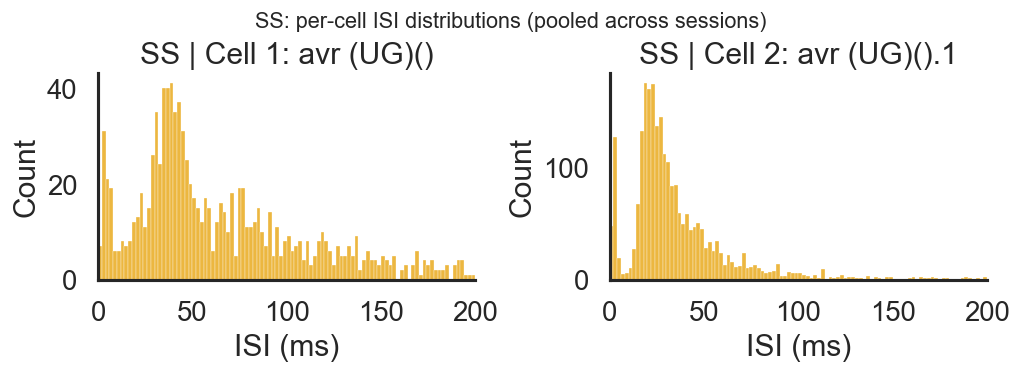

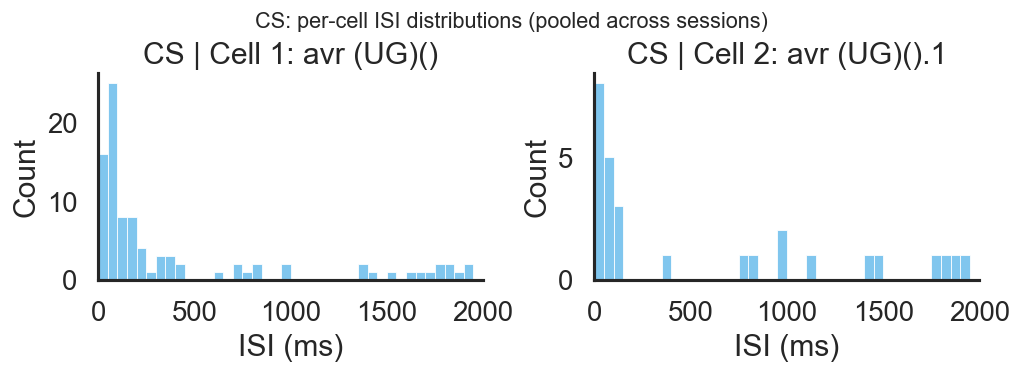

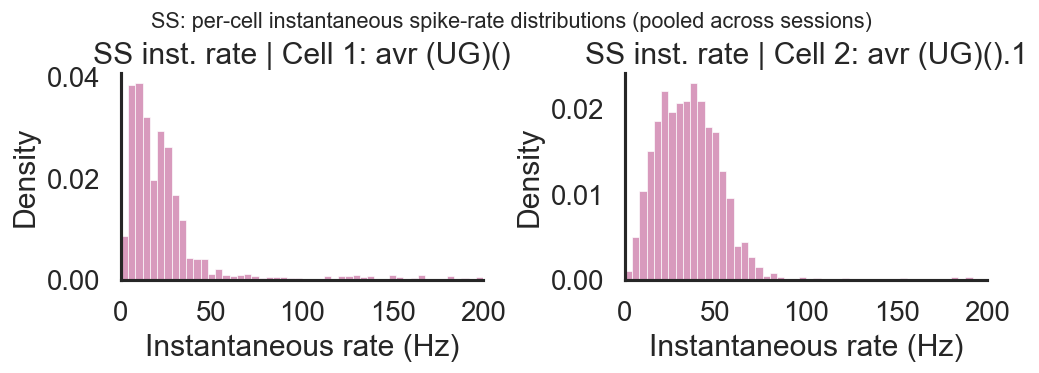

In [8]:
min_spikes_for_isi = int(SPIKE_STATS_CONFIG.get('min_spikes_for_isi', 2))
ss_isi_bins = int(SPIKE_STATS_CONFIG.get('ss_isi_n_bins', 100))
cs_isi_bins = int(SPIKE_STATS_CONFIG.get('cs_isi_n_bins', 40))
ss_isi_max = float(SPIKE_STATS_CONFIG.get('ss_isi_plot_max_ms', 200.0))
cs_isi_max = float(SPIKE_STATS_CONFIG.get('cs_isi_plot_max_ms', 2000.0))

for stype in spike_types:
    per_cell_isi = {}
    for i, cname in enumerate(cell_names):
        chunks = []
        for s in sessions:
            spikes = s['spike_times_ss'][i] if stype == 'SS' else s['spike_times_cs'][i]
            spikes = np.sort(np.asarray(spikes, dtype=float))
            spikes = spikes[np.isfinite(spikes)]
            if spikes.size >= min_spikes_for_isi:
                isi = np.diff(spikes)
                isi = isi[np.isfinite(isi) & (isi > 0)]
                if isi.size > 0:
                    chunks.append(isi)
        if chunks:
            per_cell_isi[(i, str(cname))] = np.concatenate(chunks)

    if not per_cell_isi:
        print(f'No valid {stype} ISI values for per-cell ISI plots.')
        continue

    keys = sorted(per_cell_isi.keys(), key=lambda x: x[0])
    n = len(keys)
    ncols = min(n, max(1, int(np.ceil(np.sqrt(n)))))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for idx, (cell_idx, cell_name) in enumerate(keys):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]
        vals = np.asarray(per_cell_isi[(cell_idx, cell_name)], dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if vals.size > 0:
            _bins = ss_isi_bins if stype == 'SS' else cs_isi_bins
            _max = ss_isi_max if stype == 'SS' else cs_isi_max
            _edges = np.linspace(0, _max, _bins + 1)
            sns.histplot(vals, bins=_edges, stat='count', ax=ax,
                         color=('#E69F00' if stype == 'SS' else '#56B4E9'))
            ax.set_xlim(0, _max)
        else:
            ax.text(0.5, 0.5, 'No ISI values', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{stype} | Cell {cell_idx + 1}: {cell_name}')
        ax.set_xlabel('ISI (ms)')
        ax.set_ylabel('Count')
        ax.grid(False)

    for idx in range(n, nrows * ncols):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    fig.suptitle(f'{stype}: per-cell ISI distributions (pooled across sessions)', fontsize=13)
    _save_fig_svg(fig, f'per_cell_ISI_{stype}')
    plt.show()

# Additional per-cell SS instantaneous spike-rate distribution plots (Hz = 1000 / ISI_ms)
if SPIKE_STATS_CONFIG.get('show_per_cell_ss_inst_rate_plots', True) and ('SS' in spike_types):
    ss_inst_bins = int(SPIKE_STATS_CONFIG.get('ss_inst_rate_n_bins', 50))
    ss_inst_max_cfg = SPIKE_STATS_CONFIG.get('ss_inst_rate_plot_max_hz', 200.0)

    per_cell_ss_inst = {}
    for i, cname in enumerate(cell_names):
        chunks = []
        for s in sessions:
            spikes = np.sort(np.asarray(s['spike_times_ss'][i], dtype=float))
            spikes = spikes[np.isfinite(spikes)]
            if spikes.size >= min_spikes_for_isi:
                isi = np.diff(spikes)
                isi = isi[np.isfinite(isi) & (isi > 0)]
                if isi.size > 0:
                    inst = 1000.0 / isi
                    inst = inst[np.isfinite(inst) & (inst > 0)]
                    if inst.size > 0:
                        chunks.append(inst)
        if chunks:
            per_cell_ss_inst[(i, str(cname))] = np.concatenate(chunks)

    if not per_cell_ss_inst:
        print('No valid SS instantaneous rates for per-cell plots.')
    else:
        keys = sorted(per_cell_ss_inst.keys(), key=lambda x: x[0])
        n = len(keys)
        ncols = min(n, max(1, int(np.ceil(np.sqrt(n)))))
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows), constrained_layout=True)
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        for idx, (cell_idx, cell_name) in enumerate(keys):
            r = idx // ncols
            c = idx % ncols
            ax = axes[r, c]
            vals = np.asarray(per_cell_ss_inst[(cell_idx, cell_name)], dtype=float)
            vals = vals[np.isfinite(vals) & (vals > 0)]
            if vals.size > 0:
                ss_inst_max = float(ss_inst_max_cfg) if ss_inst_max_cfg is not None else float(np.quantile(vals, 0.995) * 1.1)
                ss_inst_max = max(ss_inst_max, 1.0)
                ss_inst_edges = np.linspace(0.0, ss_inst_max, max(5, ss_inst_bins) + 1)
                sns.histplot(vals, bins=ss_inst_edges, stat='density', ax=ax, color='#CC79A7')
                ax.set_xlim(0.0, ss_inst_max)
            else:
                ax.text(0.5, 0.5, 'No SS instantaneous-rate values', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'SS inst. rate | Cell {cell_idx + 1}: {cell_name}')
            ax.set_xlabel('Instantaneous rate (Hz)')
            ax.set_ylabel('Density')
            ax.grid(False)

        for idx in range(n, nrows * ncols):
            r = idx // ncols
            c = idx % ncols
            axes[r, c].axis('off')

        fig.suptitle('SS: per-cell instantaneous spike-rate distributions (pooled across sessions)', fontsize=13)
        _save_fig_svg(fig, 'per_cell_SS_instantaneous_rate')
        plt.show()

In [9]:
def build_binned_counts(spike_times_by_cell, t_start, t_end, bin_ms):
    edges = np.arange(t_start, t_end + bin_ms, bin_ms)
    if len(edges) < 3:
        edges = np.array([t_start, t_end])
    counts = []
    for st in spike_times_by_cell:
        c, _ = np.histogram(st, bins=edges)
        counts.append(c.astype(float))
    return np.asarray(counts), edges

def corr_matrix_from_counts(counts):
    n = counts.shape[0]
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            a, b = counts[i], counts[j]
            if np.std(a) == 0 or np.std(b) == 0:
                r = 0.0
            else:
                r = float(np.corrcoef(a, b)[0, 1])
            out[i, j] = out[j, i] = r
    return out

def _metric_name_from_cfg(cfg=None):
    cfg = cfg or SYNC_CONFIG
    m = str(cfg.get('sync_metric', 'pearson')).strip().lower()
    return m if m in {'pearson', 'sttc'} else 'pearson'

def _spike_count_corr(times_a, times_b, t_start, t_end, bin_ms):
    if t_end <= t_start:
        return np.nan
    edges = np.arange(t_start, t_end + bin_ms, bin_ms)
    if len(edges) < 3:
        return np.nan
    a_counts, _ = np.histogram(times_a, bins=edges)
    b_counts, _ = np.histogram(times_b, bins=edges)
    if np.std(a_counts) == 0 or np.std(b_counts) == 0:
        return np.nan
    return float(np.corrcoef(a_counts, b_counts)[0, 1])

def _proportion_of_spikes_with_partner(times_a, times_b, dt_ms):
    if len(times_a) == 0 or len(times_b) == 0:
        return 0.0
    a = np.sort(np.asarray(times_a, dtype=float))
    b = np.sort(np.asarray(times_b, dtype=float))
    j = 0
    hit = 0
    for t in a:
        while j < len(b) and b[j] < t - dt_ms:
            j += 1
        ok = (j < len(b) and abs(b[j] - t) <= dt_ms)
        if (not ok) and (j > 0):
            ok = abs(b[j - 1] - t) <= dt_ms
        if ok:
            hit += 1
    return float(hit) / float(len(a))

def _time_covered_fraction(times_ms, t_start, t_end, dt_ms):
    t = np.sort(np.asarray(times_ms, dtype=float))
    if t.size == 0:
        return 0.0
    if t_end <= t_start:
        return np.nan
    starts = np.maximum(t - dt_ms, t_start)
    ends = np.minimum(t + dt_ms, t_end)
    valid = ends > starts
    if not np.any(valid):
        return 0.0
    starts = starts[valid]
    ends = ends[valid]
    order = np.argsort(starts)
    starts = starts[order]
    ends = ends[order]
    total = 0.0
    cur_s = starts[0]
    cur_e = ends[0]
    for s, e in zip(starts[1:], ends[1:]):
        if s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            total += (cur_e - cur_s)
            cur_s, cur_e = s, e
    total += (cur_e - cur_s)
    return float(total) / float(t_end - t_start)

def sttc_value(times_a, times_b, t_start, t_end, dt_ms=10.0):
    ta = np.asarray(times_a, dtype=float)
    tb = np.asarray(times_b, dtype=float)
    ta = ta[np.isfinite(ta) & (ta >= t_start) & (ta <= t_end)]
    tb = tb[np.isfinite(tb) & (tb >= t_start) & (tb <= t_end)]
    if ta.size == 0 or tb.size == 0 or t_end <= t_start:
        return np.nan

    dt_ms = float(max(1e-9, dt_ms))
    pa = _proportion_of_spikes_with_partner(ta, tb, dt_ms)
    pb = _proportion_of_spikes_with_partner(tb, ta, dt_ms)
    ta_cov = _time_covered_fraction(ta, t_start, t_end, dt_ms)
    tb_cov = _time_covered_fraction(tb, t_start, t_end, dt_ms)

    d1 = 1.0 - pa * tb_cov
    d2 = 1.0 - pb * ta_cov
    if abs(d1) < 1e-12 or abs(d2) < 1e-12:
        return np.nan

    sttc = 0.5 * (((pa - tb_cov) / d1) + ((pb - ta_cov) / d2))
    return float(np.clip(sttc, -1.0, 1.0))

def pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=None):
    cfg = cfg or SYNC_CONFIG
    metric = _metric_name_from_cfg(cfg)
    if metric == 'sttc':
        return sttc_value(times_a, times_b, t_start, t_end, dt_ms=float(bin_ms))
    return _spike_count_corr(times_a, times_b, t_start, t_end, bin_ms)

def corr_matrix_from_spikes(spike_times_by_cell, t_start, t_end, bin_ms, cfg=None):
    n = len(spike_times_by_cell)
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            v = pair_sync_metric(spike_times_by_cell[i], spike_times_by_cell[j], t_start, t_end, bin_ms, cfg=cfg)
            out[i, j] = out[j, i] = _safe_scalar(v)
    return out

def pair_ccg_probability(times_ref, times_target, bin_ms, max_lag_ms):
    bins = np.arange(-max_lag_ms, max_lag_ms + bin_ms, bin_ms)
    if len(times_ref) == 0 or len(times_target) == 0:
        centers = bins[:-1] + bin_ms / 2
        return centers, np.zeros_like(centers, dtype=float)

    diffs = []
    for t in times_ref:
        i0 = np.searchsorted(times_target, t - max_lag_ms)
        i1 = np.searchsorted(times_target, t + max_lag_ms)
        local = times_target[i0:i1]
        if len(local):
            diffs.extend(local - t)

    counts, edges = np.histogram(diffs, bins=bins)
    prob = counts.astype(float) / max(len(times_ref), 1)
    centers = edges[:-1] + bin_ms / 2
    return centers, prob

def _safe_scalar(x):
    if np.isscalar(x):
        try:
            return float(x)
        except Exception:
            return np.nan
    arr = np.asarray(x).reshape(-1)
    if arr.size == 0:
        return np.nan
    try:
        return float(arr[0])
    except Exception:
        return np.nan

def _gaussian_smooth(y, sigma_bins=1.0):
    sigma_bins = float(sigma_bins)
    if sigma_bins <= 0:
        return y
    radius = max(3, int(np.ceil(4 * sigma_bins)))
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel /= np.sum(kernel)
    return np.convolve(y, kernel, mode='same')


def compute_prob_ccg(times_ref, times_target, bin_ms, window_ms, sigma_bins=1.0, is_acg=False):
    lag, prob = pair_ccg_probability(
        times_ref,
        times_target,
        bin_ms=float(bin_ms),
        max_lag_ms=float(window_ms),
    )
    prob = np.asarray(prob, dtype=float)
    if bool(is_acg):
        zero_mask = np.abs(lag) < (0.5 * float(bin_ms) + 1e-12)
        prob[zero_mask] = 0.0
    prob = _gaussian_smooth(prob, sigma_bins=sigma_bins)
    return lag, prob

def _squareish_grid_shape(n, max_cols=3):
    n = int(n)
    if n <= 0:
        return 0, 0
    max_cols = max(1, int(max_cols))
    ncols = min(max_cols, int(np.ceil(np.sqrt(n))))
    nrows = int(np.ceil(n / ncols))
    while ncols / max(nrows, 1) > 1.5:
        nrows += 1
    return nrows, ncols


def _plot_grid_panels(panel_specs, ncols=None, fig_w=None, row_h=None, suptitle=None, cfg=None):
    n = len(panel_specs)
    if n == 0:
        return

    cfg = cfg or globals().get('CCG_PANEL', {})
    if ncols is None:
        nrows, ncols = _squareish_grid_shape(n, max_cols=cfg.get('grid_max_cols', 3))
    else:
        ncols = max(1, int(ncols))
        nrows = int(np.ceil(n / ncols))

    panel_inches = float(cfg.get('grid_panel_inches', 3.4))
    panel_aspect = float(cfg.get('grid_aspect', 1.05))
    fig_w = float(fig_w) if fig_w is not None else panel_inches * panel_aspect * ncols
    fig_h = float(row_h) * nrows if row_h is not None else panel_inches * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), constrained_layout=True, squeeze=False)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for k, spec in enumerate(panel_specs):
        r = k // ncols
        c = k % ncols
        ax = axes[r, c]
        ax.plot(spec['x'], spec['y'], color=spec['line_color'], lw=2.2)
        ax.fill_between(spec['x'], spec['y'], 0, color=spec['fill_color'], alpha=spec['alpha'])
        ax.axvline(0, color='lightgray', ls='--', lw=1)
        ax.set_box_aspect(1.0 / panel_aspect)
        ax.set_title(spec['title'], fontsize=11)
        if spec.get('ylabel'):
            ax.set_ylabel(spec['ylabel'])
        if spec.get('xlabel'):
            ax.set_xlabel(spec['xlabel'])
        if spec.get('xlim') is not None:
            ax.set_xlim(*spec['xlim'])
        ax.grid(False)

    for k in range(n, nrows * ncols):
        axes.flat[k].set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    return fig, axes

def _pick_cells(session, cfg):
    n = session['n_cells']
    if n < 2:
        return [0] if n == 1 else []

    req = cfg.get('cell_indices', None)
    max_cells = int(cfg.get('max_cells', 4))
    max_cells = min(max_cells, n)
    max_cells = max(2, max_cells)

    if req is None:
        return list(range(max_cells))

    valid = [int(i) for i in req if 0 <= int(i) < n]
    if len(valid) < 2:
        return list(range(max_cells))
    return valid

def _select_ccg_pairs(session, spikes, bin_ms, cfg):
    """Return all six 4-ROI pairs, or 4 highest and 2 lowest correlations."""
    all_pairs = list(combinations(range(int(session['n_cells'])), 2))
    limit = int(cfg.get('max_ccg_pairs', 6))
    if len(all_pairs) <= limit:
        return [(i, j, np.nan, 'all') for i, j in all_pairs]

    session_time = np.asarray(session.get('time_ms', []), dtype=float)
    finite_times = [np.asarray(t, dtype=float) for t in spikes if len(t)]
    if session_time.size >= 2:
        t_start, t_end = float(session_time[0]), float(session_time[-1])
    elif finite_times:
        merged = np.concatenate(finite_times)
        t_start, t_end = float(np.nanmin(merged)), float(np.nanmax(merged))
    else:
        t_start, t_end = 0.0, 1.0

    scored = []
    for i, j in all_pairs:
        score = pair_sync_metric(spikes[i], spikes[j], t_start, t_end, bin_ms, cfg=SYNC_CONFIG)
        scored.append((i, j, float(score) if np.isfinite(score) else np.nan))
    finite = sorted([row for row in scored if np.isfinite(row[2])], key=lambda row: row[2])
    if len(finite) < limit:
        finite_keys = {(i, j) for i, j, _ in finite}
        finite.extend([row for row in scored if (row[0], row[1]) not in finite_keys])
    low = [(i, j, score, 'lowest') for i, j, score in finite[:2]]
    low_keys = {(i, j) for i, j, _, _ in low}
    high = [(i, j, score, 'highest') for i, j, score in reversed(finite) if (i, j) not in low_keys][:4]
    return high + low

def plot_ccg_style_panel(session, cfg):
    idx = _pick_cells(session, cfg)
    if len(idx) < 2:
        print(f"Skipping CCG style panel for {session['session_name']}: need at least 2 valid cells")
        return

    ss = session['spike_times_ss']
    cs = session['spike_times_cs']
    sigma = float(cfg.get('smooth_sigma_bins', 1.2))
    rank_metric_label = _metric_name_from_cfg(SYNC_CONFIG).upper()

    # 1) SS-ACG for each selected cell
    acg_specs = []
    for local_k, ci in enumerate(idx):
        lag, prob = compute_prob_ccg(
            ss[ci], ss[ci],
            bin_ms=cfg['ss_acg_bin_ms'],
            window_ms=cfg['ss_acg_window_ms'],
            sigma_bins=sigma,
            is_acg=True,
        )
        acg_specs.append({
            'x': lag,
            'y': prob,
            'title': f'Cell {local_k + 1} SS-ACG',
            'line_color': '#3AA657',
            'fill_color': '#3AA657',
            'alpha': 0.22,
            'ylabel': 'ACG Prob.' if local_k == 0 else None,
            'xlabel': None,
            'xlim': (-cfg['ss_acg_window_ms'], cfg['ss_acg_window_ms']),
        })
    _plot_grid_panels(
        acg_specs,
        suptitle=f"{session['session_name']} | SS-ACG",
        cfg=cfg,
    )

    # SS and CS are ranked independently because their pair correlations differ.
    ss_pairs = _select_ccg_pairs(session, ss, cfg['ss_ccg_bin_ms'], cfg)
    cs_pairs = _select_ccg_pairs(session, cs, cfg['cs_ccg_bin_ms'], cfg)

    # 2) SS-CCG: six panels for four ROIs; otherwise 4 highest + 2 lowest.
    ss_specs = []
    for i, j, corr_value, rank_group in ss_pairs:
        lag, prob = compute_prob_ccg(
            ss[i], ss[j],
            bin_ms=cfg['ss_ccg_bin_ms'],
            window_ms=cfg['ss_ccg_window_ms'],
            sigma_bins=sigma,
            is_acg=False,
        )
        ss_specs.append({
            'x': lag,
            'y': prob,
            'title': f"SS-CCG: {session['cell_names'][i]} vs {session['cell_names'][j]}" + (f'\n{rank_metric_label}={corr_value:+.3f} ({rank_group})' if np.isfinite(corr_value) else ''),
            'line_color': '#2C2C2C',
            'fill_color': '#2C2C2C',
            'alpha': 0.18,
            'ylabel': 'SS Coinc. Prob.' if len(ss_specs) == 0 else None,
            'xlabel': 'Lag (ms)',
            'xlim': (-cfg['ss_ccg_window_ms'], cfg['ss_ccg_window_ms']),
        })
    _plot_grid_panels(
        ss_specs,
        ncols=3,
        suptitle=f"{session['session_name']} | SS-CCG",
        cfg=cfg,
    )

    # 3) CS-CCG with the same six-panel selection rule.
    cs_specs = []
    for i, j, corr_value, rank_group in cs_pairs:
        lag, prob = compute_prob_ccg(
            cs[i], cs[j],
            bin_ms=cfg['cs_ccg_bin_ms'],
            window_ms=cfg['cs_ccg_window_ms'],
            sigma_bins=sigma,
            is_acg=False,
        )
        cs_specs.append({
            'x': lag,
            'y': prob,
            'title': f"CS-CCG: {session['cell_names'][i]} vs {session['cell_names'][j]}" + (f'\n{rank_metric_label}={corr_value:+.3f} ({rank_group})' if np.isfinite(corr_value) else ''),
            'line_color': '#23A98C',
            'fill_color': '#23A98C',
            'alpha': 0.20,
            'ylabel': 'CS Coinc. Prob.' if len(cs_specs) == 0 else None,
            'xlabel': 'Lag (ms)',
            'xlim': (-cfg['cs_ccg_window_ms'], cfg['cs_ccg_window_ms']),
        })
    _plot_grid_panels(
        cs_specs,
        ncols=3,
        suptitle=f"{session['session_name']} | CS-CCG",
        cfg=cfg,
    )

def shuffle_significance(times_a, times_b, t_start, t_end, bin_ms, n_shuffles=500, cfg=None):
    duration = t_end - t_start
    if duration <= 0 or len(times_a) < 5 or len(times_b) < 5:
        return np.nan, np.nan, np.nan
    cfg = cfg or SYNC_CONFIG
    real_r = pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=cfg)
    if not np.isfinite(real_r):
        return np.nan, np.nan, np.nan

    shuffled = []
    rel = times_b - t_start
    for _ in range(n_shuffles):
        shift = np.random.uniform(0.1 * duration, 0.9 * duration)
        shifted = (rel + shift) % duration + t_start
        shuffled.append(pair_sync_metric(times_a, shifted, t_start, t_end, bin_ms, cfg=cfg))

    shuffled = np.asarray(shuffled, dtype=float)
    shuffled = shuffled[np.isfinite(shuffled)]
    if shuffled.size == 0:
        return np.nan, np.nan, np.nan
    p_two_sided = (np.sum(np.abs(shuffled) >= abs(real_r)) + 1.0) / (len(shuffled) + 1.0)
    z = (real_r - np.mean(shuffled)) / (np.std(shuffled) + 1e-9)
    return _safe_scalar(real_r), _safe_scalar(p_two_sided), _safe_scalar(z)

def compute_session_sync(session, spike_type='SS', cfg=None):
    cfg = cfg or SYNC_CONFIG
    spikes = session['spike_times_ss'] if spike_type.upper() == 'SS' else session['spike_times_cs']
    bin_ms = cfg['ss_bin_ms'] if spike_type.upper() == 'SS' else cfg['cs_bin_ms']

    t0 = float(session['time_ms'][0])
    t1 = float(session['time_ms'][-1])
    counts, edges = build_binned_counts(spikes, t0, t1, bin_ms)
    corr_mat = corr_matrix_from_spikes(spikes, t0, t1, bin_ms, cfg=cfg)

    pair_rows = []
    for i, j in combinations(range(session['n_cells']), 2):
        real_r, p_val, z_score = shuffle_significance(
            spikes[i], spikes[j], t0, t1, bin_ms=bin_ms, n_shuffles=int(globals().get('SIGNIFICANCE_TEST_CONFIG', {}).get('n_null_shuffles', 1000)), cfg=cfg
        )
        pair_rows.append({
            'session': session['session_name'],
            'spike_type': spike_type.upper(),
            'metric': _metric_name_from_cfg(cfg),
            'cell_i': session['cell_names'][i],
            'cell_j': session['cell_names'][j],
            'i': i,
            'j': j,
            'r': _safe_scalar(real_r),
            'p': _safe_scalar(p_val),
            'z': _safe_scalar(z_score),
        })

    return {
        'counts': counts,
        'edges': edges,
        'corr': corr_mat,
        'pair_df': pd.DataFrame(pair_rows),
    }

In [10]:
# Synchrony metric override: supports Pearson (binned-count correlation) and STTC.
def _metric_name_from_cfg(cfg=None):
    cfg = cfg or SYNC_CONFIG
    m = str(cfg.get('sync_metric', 'pearson')).strip().lower()
    return m if m in {'pearson', 'sttc'} else 'pearson'

def _spike_count_corr(times_a, times_b, t_start, t_end, bin_ms):
    if t_end <= t_start:
        return np.nan
    edges = np.arange(t_start, t_end + bin_ms, bin_ms)
    if len(edges) < 3:
        return np.nan
    a_counts, _ = np.histogram(times_a, bins=edges)
    b_counts, _ = np.histogram(times_b, bins=edges)
    if np.std(a_counts) == 0 or np.std(b_counts) == 0:
        return np.nan
    return float(np.corrcoef(a_counts, b_counts)[0, 1])

def _proportion_of_spikes_with_partner(times_a, times_b, dt_ms):
    if len(times_a) == 0 or len(times_b) == 0:
        return 0.0
    a = np.sort(np.asarray(times_a, dtype=float))
    b = np.sort(np.asarray(times_b, dtype=float))
    j = 0
    hit = 0
    for t in a:
        while j < len(b) and b[j] < t - dt_ms:
            j += 1
        ok = (j < len(b) and abs(b[j] - t) <= dt_ms)
        if (not ok) and (j > 0):
            ok = abs(b[j - 1] - t) <= dt_ms
        if ok:
            hit += 1
    return float(hit) / float(len(a))

def _time_covered_fraction(times_ms, t_start, t_end, dt_ms):
    t = np.sort(np.asarray(times_ms, dtype=float))
    if t.size == 0:
        return 0.0
    if t_end <= t_start:
        return np.nan
    starts = np.maximum(t - dt_ms, t_start)
    ends = np.minimum(t + dt_ms, t_end)
    valid = ends > starts
    if not np.any(valid):
        return 0.0
    starts = starts[valid]
    ends = ends[valid]
    order = np.argsort(starts)
    starts = starts[order]
    ends = ends[order]

    total = 0.0
    cur_s = starts[0]
    cur_e = ends[0]
    for s, e in zip(starts[1:], ends[1:]):
        if s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            total += (cur_e - cur_s)
            cur_s, cur_e = s, e
    total += (cur_e - cur_s)
    return float(total) / float(t_end - t_start)

def sttc_value(times_a, times_b, t_start, t_end, dt_ms=10.0):
    ta = np.asarray(times_a, dtype=float)
    tb = np.asarray(times_b, dtype=float)
    ta = ta[np.isfinite(ta) & (ta >= t_start) & (ta <= t_end)]
    tb = tb[np.isfinite(tb) & (tb >= t_start) & (tb <= t_end)]
    if ta.size == 0 or tb.size == 0 or t_end <= t_start:
        return np.nan

    dt_ms = float(max(1e-9, dt_ms))
    pa = _proportion_of_spikes_with_partner(ta, tb, dt_ms)
    pb = _proportion_of_spikes_with_partner(tb, ta, dt_ms)
    ta_cov = _time_covered_fraction(ta, t_start, t_end, dt_ms)
    tb_cov = _time_covered_fraction(tb, t_start, t_end, dt_ms)

    d1 = 1.0 - pa * tb_cov
    d2 = 1.0 - pb * ta_cov
    if abs(d1) < 1e-12 or abs(d2) < 1e-12:
        return np.nan

    sttc = 0.5 * (((pa - tb_cov) / d1) + ((pb - ta_cov) / d2))
    return float(np.clip(sttc, -1.0, 1.0))

def pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=None):
    cfg = cfg or SYNC_CONFIG
    metric = _metric_name_from_cfg(cfg)
    if metric == 'sttc':
        return sttc_value(times_a, times_b, t_start, t_end, dt_ms=float(bin_ms))
    return _spike_count_corr(times_a, times_b, t_start, t_end, bin_ms)

def corr_matrix_from_spikes(spike_times_by_cell, t_start, t_end, bin_ms, cfg=None):
    n = len(spike_times_by_cell)
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            v = pair_sync_metric(spike_times_by_cell[i], spike_times_by_cell[j], t_start, t_end, bin_ms, cfg=cfg)
            out[i, j] = out[j, i] = _safe_scalar(v)
    return out

def shuffle_significance(times_a, times_b, t_start, t_end, bin_ms, n_shuffles=500, cfg=None):
    duration = t_end - t_start
    if duration <= 0 or len(times_a) < 5 or len(times_b) < 5:
        return np.nan, np.nan, np.nan

    cfg = cfg or SYNC_CONFIG
    real_val = pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=cfg)
    if not np.isfinite(real_val):
        return np.nan, np.nan, np.nan

    shuffled = []
    rel = np.asarray(times_b, dtype=float) - t_start
    for _ in range(int(n_shuffles)):
        shift = np.random.uniform(0.1 * duration, 0.9 * duration)
        shifted = (rel + shift) % duration + t_start
        sv = pair_sync_metric(times_a, shifted, t_start, t_end, bin_ms, cfg=cfg)
        if np.isfinite(sv):
            shuffled.append(float(sv))

    shuffled = np.asarray(shuffled, dtype=float)
    if shuffled.size == 0:
        return np.nan, np.nan, np.nan

    p_two_sided = (np.sum(np.abs(shuffled) >= abs(real_val)) + 1.0) / (len(shuffled) + 1.0)
    z = (real_val - np.mean(shuffled)) / (np.std(shuffled) + 1e-9)
    return _safe_scalar(real_val), _safe_scalar(p_two_sided), _safe_scalar(z)

def compute_session_sync(session, spike_type='SS', cfg=None):
    cfg = cfg or SYNC_CONFIG
    spikes = session['spike_times_ss'] if spike_type.upper() == 'SS' else session['spike_times_cs']
    bin_ms = cfg['ss_bin_ms'] if spike_type.upper() == 'SS' else cfg['cs_bin_ms']

    t0 = float(session['time_ms'][0])
    t1 = float(session['time_ms'][-1])
    counts, edges = build_binned_counts(spikes, t0, t1, bin_ms)
    corr_mat = corr_matrix_from_spikes(spikes, t0, t1, bin_ms, cfg=cfg)

    pair_rows = []
    for i, j in combinations(range(session['n_cells']), 2):
        real_val, p_val, z_score = shuffle_significance(
            spikes[i], spikes[j], t0, t1, bin_ms=bin_ms, n_shuffles=int(globals().get('SIGNIFICANCE_TEST_CONFIG', {}).get('n_null_shuffles', 1000)), cfg=cfg
        )
        pair_rows.append({
            'session': session['session_name'],
            'spike_type': spike_type.upper(),
            'metric': _metric_name_from_cfg(cfg),
            'cell_i': session['cell_names'][i],
            'cell_j': session['cell_names'][j],
            'i': i,
            'j': j,
            'r': _safe_scalar(real_val),
            'p': _safe_scalar(p_val),
            'z': _safe_scalar(z_score),
        })

    return {
        'counts': counts,
        'edges': edges,
        'corr': corr_mat,
        'pair_df': pd.DataFrame(pair_rows),
    }

print(f"Synchrony metric active: {_metric_name_from_cfg(SYNC_CONFIG).upper()} (SS dt/bin={float(SYNC_CONFIG['ss_bin_ms']):.2f} ms, CS dt/bin={float(SYNC_CONFIG['cs_bin_ms']):.2f} ms)")

Synchrony metric active: STTC (SS dt/bin=5.00 ms, CS dt/bin=28.00 ms)


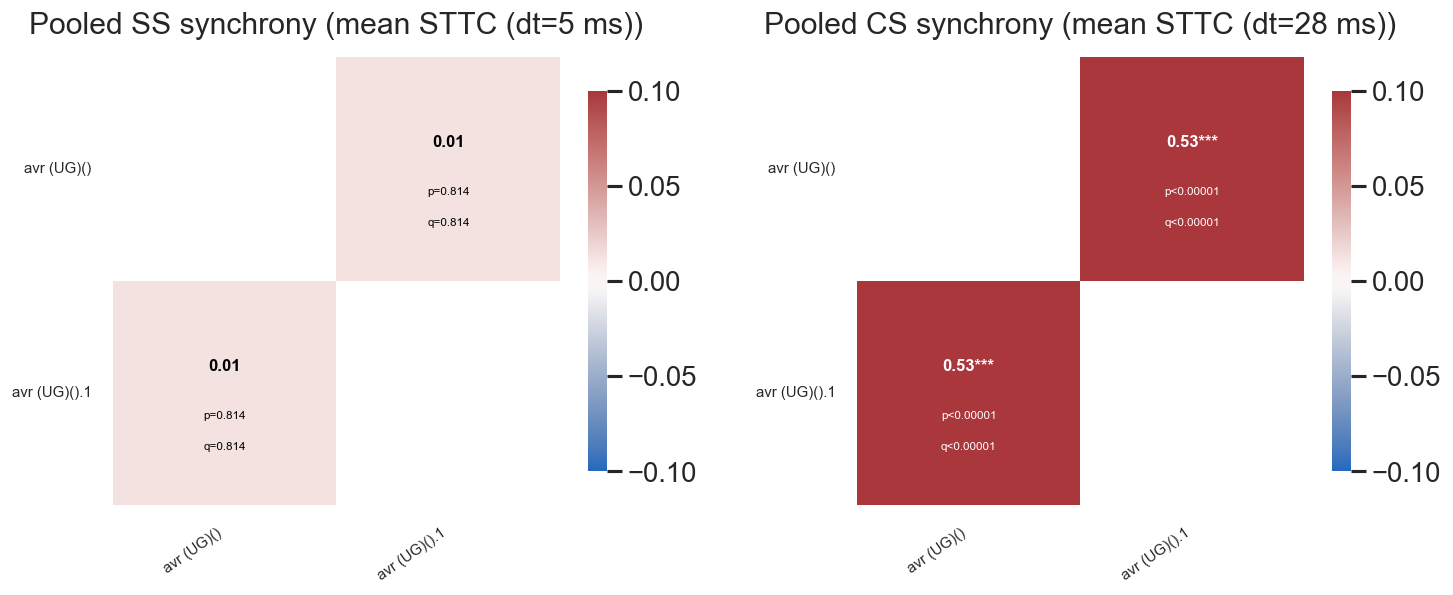

,session,spike_type,metric,cell_i,cell_j,i,j,r,p,z
0,pair_10,SS,sttc,avr (UG)(),avr (UG)().1,0,1,0.030858,0.493506,0.712293
1,pair_10,CS,sttc,avr (UG)(),avr (UG)().1,0,1,0.225057,0.183816,1.687534
2,pair_11,SS,sttc,avr (UG)(),avr (UG)().1,0,1,-0.004928,0.765235,-0.338631
3,pair_11,CS,sttc,avr (UG)(),avr (UG)().1,0,1,NaN,NaN,NaN
4,pair_13,SS,sttc,avr (UG)(),avr (UG)().1,0,1,0.010380,0.999001,-0.022006


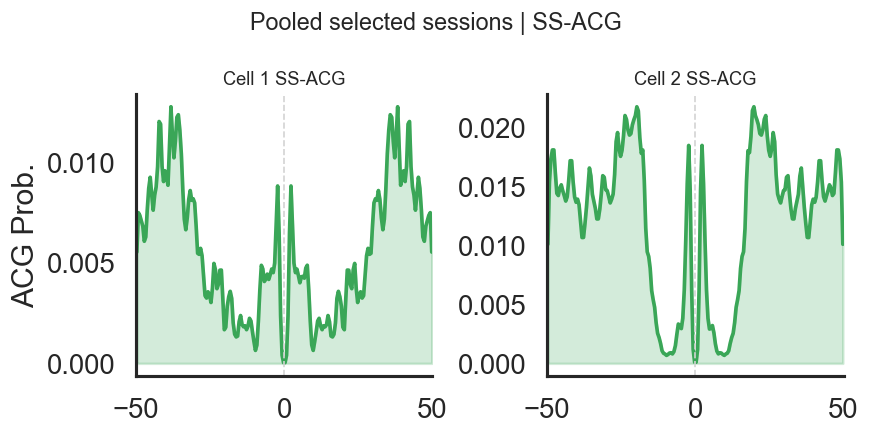

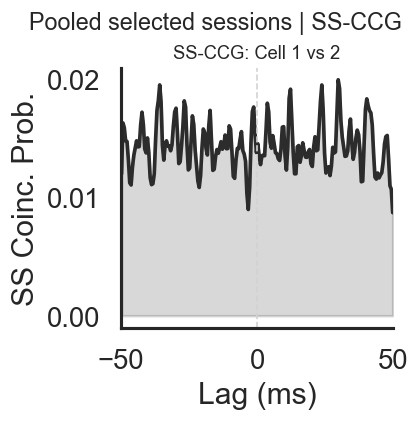

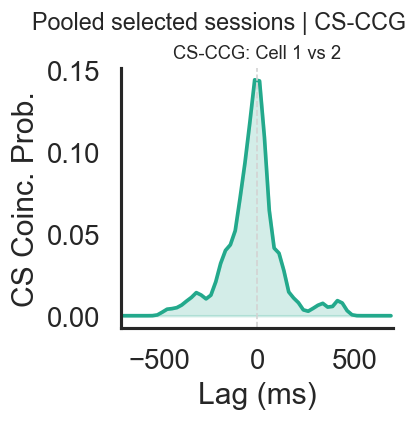

In [11]:
def _metric_name_from_cfg(cfg=None):

    cfg = cfg or SYNC_CONFIG

    m = str(cfg.get('sync_metric', 'pearson')).strip().lower()

    return m if m in {'pearson', 'sttc'} else 'pearson'


def _spike_count_corr(times_a, times_b, t_start, t_end, bin_ms):

    if t_end <= t_start:

        return np.nan

    edges = np.arange(t_start, t_end + bin_ms, bin_ms)

    if len(edges) < 3:

        return np.nan

    a_counts, _ = np.histogram(times_a, bins=edges)

    b_counts, _ = np.histogram(times_b, bins=edges)

    if np.std(a_counts) == 0 or np.std(b_counts) == 0:

        return np.nan

    return float(np.corrcoef(a_counts, b_counts)[0, 1])


def _proportion_of_spikes_with_partner(times_a, times_b, dt_ms):

    if len(times_a) == 0 or len(times_b) == 0:

        return 0.0

    a = np.sort(np.asarray(times_a, dtype=float))

    b = np.sort(np.asarray(times_b, dtype=float))

    j = 0

    hit = 0

    for t in a:

        while j < len(b) and b[j] < t - dt_ms:

            j += 1

        ok = (j < len(b) and abs(b[j] - t) <= dt_ms)

        if (not ok) and (j > 0):

            ok = abs(b[j - 1] - t) <= dt_ms

        if ok:

            hit += 1

    return float(hit) / float(len(a))


def _time_covered_fraction(times_ms, t_start, t_end, dt_ms):

    t = np.sort(np.asarray(times_ms, dtype=float))

    if t.size == 0:

        return 0.0

    if t_end <= t_start:

        return np.nan

    starts = np.maximum(t - dt_ms, t_start)

    ends = np.minimum(t + dt_ms, t_end)

    valid = ends > starts

    if not np.any(valid):

        return 0.0

    starts = starts[valid]

    ends = ends[valid]

    order = np.argsort(starts)

    starts = starts[order]

    ends = ends[order]

    total = 0.0

    cur_s = starts[0]

    cur_e = ends[0]

    for s, e in zip(starts[1:], ends[1:]):

        if s <= cur_e:

            cur_e = max(cur_e, e)

        else:

            total += (cur_e - cur_s)

            cur_s, cur_e = s, e

    total += (cur_e - cur_s)

    return float(total) / float(t_end - t_start)


def sttc_value(times_a, times_b, t_start, t_end, dt_ms=10.0):

    ta = np.asarray(times_a, dtype=float)

    tb = np.asarray(times_b, dtype=float)

    ta = ta[np.isfinite(ta) & (ta >= t_start) & (ta <= t_end)]

    tb = tb[np.isfinite(tb) & (tb >= t_start) & (tb <= t_end)]

    if ta.size == 0 or tb.size == 0 or t_end <= t_start:

        return np.nan

    dt_ms = float(max(1e-9, dt_ms))

    pa = _proportion_of_spikes_with_partner(ta, tb, dt_ms)

    pb = _proportion_of_spikes_with_partner(tb, ta, dt_ms)

    ta_cov = _time_covered_fraction(ta, t_start, t_end, dt_ms)

    tb_cov = _time_covered_fraction(tb, t_start, t_end, dt_ms)

    d1 = 1.0 - pa * tb_cov

    d2 = 1.0 - pb * ta_cov

    if abs(d1) < 1e-12 or abs(d2) < 1e-12:

        return np.nan

    sttc = 0.5 * (((pa - tb_cov) / d1) + ((pb - ta_cov) / d2))

    return float(np.clip(sttc, -1.0, 1.0))


def pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=None):

    cfg = cfg or SYNC_CONFIG

    metric = _metric_name_from_cfg(cfg)

    if metric == 'sttc':

        return sttc_value(times_a, times_b, t_start, t_end, dt_ms=float(bin_ms))

    return _spike_count_corr(times_a, times_b, t_start, t_end, bin_ms)


def corr_matrix_from_spikes(spike_times_by_cell, t_start, t_end, bin_ms, cfg=None):

    n = len(spike_times_by_cell)

    out = np.eye(n, dtype=float)

    for i in range(n):

        for j in range(i + 1, n):

            v = pair_sync_metric(spike_times_by_cell[i], spike_times_by_cell[j], t_start, t_end, bin_ms, cfg=cfg)

            out[i, j] = out[j, i] = _safe_scalar(v)

    return out


def _sync_sig_cfg():

    return globals().get('SIGNIFICANCE_TEST_CONFIG', {})


def _whole_trace_jitter_ms(spike_type):

    cfg = _sync_sig_cfg()

    stype = str(spike_type).strip().upper()

    if stype == 'CS':

        return float(cfg.get('cs_jitter_ms', 600.0))

    return float(cfg.get('ss_jitter_ms', 25.0))


def _selected_null_p(obs, null_arr, tail=None):

    null_arr = np.asarray(null_arr, dtype=float)

    null_arr = null_arr[np.isfinite(null_arr)]

    if null_arr.size == 0 or not np.isfinite(obs):

        return np.nan

    tail = str(tail or _sync_sig_cfg().get('tail', 'two-sided')).strip().lower()

    p_right = float((np.sum(null_arr >= obs) + 1.0) / (null_arr.size + 1.0))

    p_left = float((np.sum(null_arr <= obs) + 1.0) / (null_arr.size + 1.0))

    if tail == 'right':

        return p_right

    if tail == 'left':

        return p_left

    if tail == 'adaptive-one-sided':

        return p_right if obs >= np.nanmean(null_arr) else p_left

    return float(min(1.0, 2.0 * min(p_left, p_right)))


def _format_pq_value(val, label='p', floor=None):

    val = pd.to_numeric(val, errors='coerce')

    if not np.isfinite(val):

        return f'{label}=na'

    floor = float(_sync_sig_cfg().get('p_floor_label', 1e-5) if floor is None else floor)

    if val < floor:

        decimals = max(0, int(np.ceil(-np.log10(floor))))

        return f'{label}<{floor:.{decimals}f}'

    if val < 0.001:

        return f'{label}={val:.5f}'

    if val < 0.01:

        return f'{label}={val:.4f}'

    return f'{label}={val:.3f}'


def _jitter_spikes_in_bounds(times, t_start, t_end, jitter_ms, rng_obj):

    out = np.asarray(times, dtype=float).copy()

    if out.size == 0 or t_end <= t_start:

        return out

    out = out + rng_obj.uniform(-jitter_ms, jitter_ms, size=out.size)

    return np.clip(out, t_start, t_end)


def shuffle_significance(times_a, times_b, t_start, t_end, bin_ms, n_shuffles=None, cfg=None, spike_type='SS', rng=None):

    duration = t_end - t_start

    if duration <= 0 or len(times_a) < 5 or len(times_b) < 5:

        return np.nan, np.nan, np.nan

    cfg = cfg or SYNC_CONFIG

    sig_cfg = _sync_sig_cfg()

    if not bool(sig_cfg.get('enabled', True)):

        real_val = pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=cfg)

        return _safe_scalar(real_val), np.nan, np.nan

    real_val = pair_sync_metric(times_a, times_b, t_start, t_end, bin_ms, cfg=cfg)

    if not np.isfinite(real_val):

        return np.nan, np.nan, np.nan

    jitter_ms = _whole_trace_jitter_ms(spike_type)

    n_shuffles = int(sig_cfg.get('n_null_shuffles', 1000) if n_shuffles is None else n_shuffles)

    rng_obj = np.random.default_rng(int(sig_cfg.get('seed', 123))) if rng is None else rng

    shuffled = []

    for _ in range(n_shuffles):

        jittered_a = _jitter_spikes_in_bounds(times_a, t_start, t_end, jitter_ms, rng_obj)

        jittered_b = _jitter_spikes_in_bounds(times_b, t_start, t_end, jitter_ms, rng_obj)

        shifted_val = pair_sync_metric(jittered_a, jittered_b, t_start, t_end, bin_ms, cfg=cfg)

        if np.isfinite(shifted_val):

            shuffled.append(float(shifted_val))

    shuffled = np.asarray(shuffled, dtype=float)

    shuffled = shuffled[np.isfinite(shuffled)]

    if shuffled.size == 0:

        return np.nan, np.nan, np.nan

    p_val = _selected_null_p(real_val, shuffled, tail=sig_cfg.get('tail', 'two-sided'))

    z = (real_val - np.mean(shuffled)) / (np.std(shuffled) + 1e-9)

    return _safe_scalar(real_val), _safe_scalar(p_val), _safe_scalar(z)


def compute_session_sync(session, spike_type='SS', cfg=None):

    cfg = cfg or SYNC_CONFIG

    stype = str(spike_type).upper()

    spikes = session['spike_times_ss'] if stype == 'SS' else session['spike_times_cs']

    bin_ms = cfg['ss_bin_ms'] if stype == 'SS' else cfg['cs_bin_ms']

    t0 = float(session['time_ms'][0])

    t1 = float(session['time_ms'][-1])

    counts, edges = build_binned_counts(spikes, t0, t1, bin_ms)

    corr_mat = corr_matrix_from_spikes(spikes, t0, t1, bin_ms, cfg=cfg)

    sig_cfg = _sync_sig_cfg()

    n_null = int(sig_cfg.get('n_null_shuffles', 1000))

    rng = np.random.default_rng(int(sig_cfg.get('seed', 123)))

    pair_rows = []

    for i, j in combinations(range(session['n_cells']), 2):

        real_val, p_val, z_score = shuffle_significance(

            spikes[i], spikes[j], t0, t1, bin_ms=bin_ms, n_shuffles=n_null, cfg=cfg, spike_type=stype, rng=rng

        )

        pair_rows.append({

            'session': session['session_name'],

            'spike_type': stype,

            'metric': _metric_name_from_cfg(cfg),

            'cell_i': session['cell_names'][i],

            'cell_j': session['cell_names'][j],

            'i': i,

            'j': j,

            'r': _safe_scalar(real_val),

            'p': _safe_scalar(p_val),

            'z': _safe_scalar(z_score),

        })

    return {

        'counts': counts,

        'edges': edges,

        'corr': corr_mat,

        'pair_df': pd.DataFrame(pair_rows),

    }


def _sync_metric_labels(cfg=None, spike_type=None):

    cfg = cfg or SYNC_CONFIG

    metric = _metric_name_from_cfg(cfg)

    stype = None if spike_type is None else str(spike_type).strip().upper()

    if metric == 'sttc':

        if stype == 'CS':

            dt_ms = float(cfg.get('cs_bin_ms', 30.0))

            dt_label = f'dt={dt_ms:g} ms'

        elif stype == 'SS':

            dt_ms = float(cfg.get('ss_bin_ms', 5.0))

            dt_label = f'dt={dt_ms:g} ms'

        else:

            dt_label = f'SS dt={float(cfg.get("ss_bin_ms", 5.0)):g} ms; CS dt={float(cfg.get("cs_bin_ms", 30.0)):g} ms'

        return {

            'metric': metric,

            'title': f'STTC ({dt_label})',

            'value': 'STTC',

            'mean_title': f'mean STTC ({dt_label})',

        }

    return {

        'metric': metric,

        'title': 'Pearson r',

        'value': 'r',

        'mean_title': 'mean Pearson r',

    }

def _bh_fdr_sync(pvals):

    p = np.asarray(pvals, dtype=float)

    q = np.full_like(p, np.nan, dtype=float)

    finite = np.isfinite(p)

    if not np.any(finite):

        return q

    pf = p[finite]

    order = np.argsort(pf)

    ranked = pf[order]

    m = len(ranked)

    q_ranked = ranked * m / np.arange(1, m + 1)

    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]

    q_ranked = np.clip(q_ranked, 0.0, 1.0)

    back = np.empty_like(q_ranked)

    back[order] = q_ranked

    q[finite] = back

    return q



def _combine_pair_pvalues_fisher(pvals):

    from scipy.stats import chi2

    vals = np.asarray(pvals, dtype=float)

    vals = vals[np.isfinite(vals)]

    vals = vals[(vals > 0.0) & (vals <= 1.0)]

    if vals.size == 0:

        return np.nan

    if vals.size == 1:

        return float(vals[0])

    stat = -2.0 * np.sum(np.log(vals))

    return float(chi2.sf(stat, 2 * vals.size))



def _blank_matrix_diagonal(mat):

    out = np.array(mat, dtype=float, copy=True)

    if out.ndim == 2 and out.shape[0] == out.shape[1]:

        np.fill_diagonal(out, np.nan)

    return out


def _matrix_text_color(val, threshold=None):

    try:

        v = float(val)

    except Exception:

        return 'black'

    if not np.isfinite(v):

        return '#6B7280'

    if threshold is None:

        cfg = globals().get('CORR_HEATMAP_SCALE', {})

        if bool(cfg.get('enabled', False)):

            lim = max(abs(float(cfg.get('vmin', -1.0))), abs(float(cfg.get('vmax', 1.0))))

            threshold = 0.55 * lim

        else:

            threshold = 0.55

    return 'white' if abs(v) >= float(threshold) else 'black'


def _pair_matrix_from_df(cell_names_local, pair_df_local, value_col, diag_value=np.nan):

    n_local = len(cell_names_local)

    mat = np.full((n_local, n_local), np.nan, dtype=float)

    if pair_df_local is None or len(pair_df_local) == 0:

        return _blank_matrix_diagonal(mat)

    for row in pair_df_local.itertuples(index=False):

        ci = str(row.cell_i)

        cj = str(row.cell_j)

        if ci not in cell_names_local or cj not in cell_names_local:

            continue

        i = cell_names_local.index(ci)

        j = cell_names_local.index(cj)

        value = getattr(row, value_col)

        value = _safe_scalar(value)

        mat[i, j] = value

        mat[j, i] = value

    return _blank_matrix_diagonal(mat)



def _aggregate_pair_summary(pair_df_local, spike_type):

    sub = pair_df_local[pair_df_local['spike_type'] == spike_type].copy()

    if sub.empty:

        return pd.DataFrame(columns=['cell_i', 'cell_j', 'mean_metric', 'p', 'q', 'n_sessions'])

    sub['r'] = pd.to_numeric(sub['r'], errors='coerce')

    sub['p'] = pd.to_numeric(sub['p'], errors='coerce')

    rows = []

    for (cell_i, cell_j), grp in sub.groupby(['cell_i', 'cell_j'], sort=False):

        vals = grp['r'].dropna().to_numpy(dtype=float)

        p_vals = grp['p'].dropna().to_numpy(dtype=float)

        rows.append({

            'cell_i': cell_i,

            'cell_j': cell_j,

            'mean_metric': float(np.nanmean(vals)) if vals.size else np.nan,

            'p': _combine_pair_pvalues_fisher(p_vals),

            'n_sessions': int(grp['session'].nunique()),

        })

    out = pd.DataFrame(rows)

    if not out.empty:

        out['q'] = _bh_fdr_sync(out['p'].values)

    return out



def _prepare_session_pair_summary(pair_df_local):

    out = pair_df_local.copy()

    if out.empty:

        out['q'] = []

        return out

    out['r'] = pd.to_numeric(out['r'], errors='coerce')

    out['p'] = pd.to_numeric(out['p'], errors='coerce')

    out['q'] = _bh_fdr_sync(out['p'].values)

    return out



def _p_value_stars(p_val):

    if not np.isfinite(p_val):

        return ''

    if p_val < 0.001:

        return '***'

    if p_val < 0.01:

        return '**'

    if p_val < 0.05:

        return '*'

    return ''


def _overlay_sync_text(ax, value_mat, p_mat=None, q_mat=None, report_metric='p', sig_alpha=0.05, show_on_plot=True):

    style = globals().get('CORR_MATRIX_STYLE', {})
    value_fs = float(style.get('value_fontsize', 10))
    stat_fs = float(style.get('stat_fontsize', 7))
    value_weight = style.get('value_fontweight', 'bold')

    n_local = value_mat.shape[0]

    for i in range(n_local):

        for j in range(n_local):

            val = value_mat[i, j]

            if not np.isfinite(val):

                continue

            x = j + 0.5

            y = i + 0.5

            txt_color = _matrix_text_color(val)

            if i == j:

                ax.text(x, y, f'{val:.2f}', ha='center', va='center', fontsize=value_fs, fontweight=value_weight, color=txt_color)

                continue

            p_val = np.nan if p_mat is None else p_mat[i, j]

            q_val = np.nan if q_mat is None else q_mat[i, j]

            suffix = _p_value_stars(p_val)

            if show_on_plot:

                ax.text(x, y - 0.12, f'{val:.2f}{suffix}', ha='center', va='center', fontsize=value_fs, fontweight=value_weight, color=txt_color)

                p_text = _format_pq_value(p_val, 'p')

                ax.text(x, y + 0.10, p_text, ha='center', va='center', fontsize=stat_fs, color=txt_color)

                if np.isfinite(q_val):

                    ax.text(x, y + 0.24, _format_pq_value(q_val, 'q'), ha='center', va='center', fontsize=stat_fs, color=txt_color)

            else:

                ax.text(x, y, f'{val:.2f}{suffix}', ha='center', va='center', fontsize=value_fs, fontweight=value_weight, color=txt_color)



sync_results = {}

all_pair_stats = []



metric_labels = _sync_metric_labels(SYNC_CONFIG)

sig_report_cfg = globals().get('SIGNIFICANCE_REPORT_CONFIG', {})

show_on_plot = bool(sig_report_cfg.get('show_on_plot', True))

report_metric = str(sig_report_cfg.get('metric', 'p')).strip().lower()

sig_alpha = float(sig_report_cfg.get('alpha', 0.05))



selected_names = SYNC_VIEW.get('session_names', None)

if selected_names is None:

    selected_set = {s['session_name'] for s in sessions}

else:

    selected_set = set(selected_names)



sessions_for_sync = [s for s in sessions if s['session_name'] in selected_set]

if not sessions_for_sync:

    raise ValueError('No sessions matched SYNC_VIEW["session_names"].')



mode = str(SYNC_VIEW.get('mode', 'pooled')).strip().lower()

if mode not in {'pooled', 'per-session', 'both'}:

    raise ValueError("SYNC_VIEW['mode'] must be one of: 'pooled', 'per-session', 'both'")



exclude_event_mod_window = bool(SYNC_EXCLUDE_EVENT_MOD_WINDOW.get('enabled', False))

sync_suffix = ' (event-mod period excluded)' if exclude_event_mod_window else ''



def _remove_event_window_spikes(spike_times, event_time_ms, window_ms):

    w0, w1 = float(window_ms[0]), float(window_ms[1])

    t0 = event_time_ms + w0

    t1 = event_time_ms + w1

    st = np.asarray(spike_times, dtype=float)

    return st[(st < t0) | (st >= t1)]



def _prep_sync_session(session):

    if not exclude_event_mod_window:

        return session

    ss_window = EVENT_CONFIG['ss_rate_response_ms']

    cs_window = EVENT_CONFIG['cs_rate_response_ms']

    out = dict(session)

    out['spike_times_ss'] = [

        _remove_event_window_spikes(st, EVENT_CONFIG['event_time_ms'], ss_window)

        for st in session['spike_times_ss']

    ]

    out['spike_times_cs'] = [

        _remove_event_window_spikes(st, EVENT_CONFIG['event_time_ms'], cs_window)

        for st in session['spike_times_cs']

    ]

    return out



if exclude_event_mod_window:

    print('Synchrony uses spikes with event-modulated response windows removed:')

    print(f"  SS removed window: {EVENT_CONFIG['ss_rate_response_ms']} ms relative to event")

    print(f"  CS removed window: {EVENT_CONFIG['cs_rate_response_ms']} ms relative to event")



if n_cells < 2:

    print('Single-cell dataset detected (n_cells=1). Skipping pairwise synchrony and CCG sections.')

    pair_stats_df = pd.DataFrame(columns=['session', 'spike_type', 'cell_i', 'cell_j', 'i', 'j', 'r', 'p', 'z'])

    if mode in {'pooled', 'both'} and SYNC_VIEW.get('show_pooled_heatmaps', True):

        fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

        for ax, stype in zip(axes, ['SS', 'CS']):

            mat = _blank_matrix_diagonal(np.array([[1.0]]))

            sns.heatmap(mat, cmap='vlag', square=True,

                        xticklabels=cell_names, yticklabels=cell_names, annot=False, ax=ax)

            ax.set_title(f'Pooled {stype} synchrony (single cell){sync_suffix}')

        plt.show()

    if mode in {'per-session', 'both'}:

        for s in sessions_for_sync:

            fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

            for ax, stype in zip(axes, ['SS', 'CS']):

                mat = _blank_matrix_diagonal(np.array([[1.0]]))

                sns.heatmap(mat, cmap='vlag', square=True,

                            xticklabels=cell_names, yticklabels=cell_names, annot=False, ax=ax)

                ax.set_title(f"{s['session_name']}: {stype} synchrony (single cell){sync_suffix}")

            plt.show()

    display(pair_stats_df.head())

else:

    for s in sessions_for_sync:

        s_sync = _prep_sync_session(s)

        ss_res = compute_session_sync(s_sync, 'SS', SYNC_CONFIG)

        cs_res = compute_session_sync(s_sync, 'CS', SYNC_CONFIG)

        sync_results[s['session_name']] = {'SS': ss_res, 'CS': cs_res}

        all_pair_stats.append(ss_res['pair_df'])

        all_pair_stats.append(cs_res['pair_df'])

    pair_stats_df = pd.concat(all_pair_stats, ignore_index=True) if all_pair_stats else pd.DataFrame()

    if not pair_stats_df.empty:

        for col in ['r', 'p', 'z']:

            pair_stats_df[col] = pair_stats_df[col].apply(_safe_scalar)

        pair_stats_df['r'] = pd.to_numeric(pair_stats_df['r'], errors='coerce')

        pair_stats_df['p'] = pd.to_numeric(pair_stats_df['p'], errors='coerce')

        pair_stats_df['z'] = pd.to_numeric(pair_stats_df['z'], errors='coerce')

    pooled_pair_summary = {

        'SS': _aggregate_pair_summary(pair_stats_df, 'SS'),

        'CS': _aggregate_pair_summary(pair_stats_df, 'CS'),

    }

    if mode in {'pooled', 'both'} and SYNC_VIEW.get('show_pooled_heatmaps', True):

        ss_stack = np.stack([sync_results[s['session_name']]['SS']['corr'] for s in sessions_for_sync], axis=0)

        cs_stack = np.stack([sync_results[s['session_name']]['CS']['corr'] for s in sessions_for_sync], axis=0)

        pooled_ss = np.nanmean(ss_stack, axis=0)

        pooled_cs = np.nanmean(cs_stack, axis=0)

        fig_w = max(12.0, 1.2 * n_cells + 6.0)

        fig_h = max(5.0, 0.95 * n_cells + 1.0)

        fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)
        fig.set_constrained_layout_pads(h_pad=0.12, w_pad=0.04, hspace=0.08, wspace=0.08)


        for ax, mat, stype in zip(axes, [pooled_ss, pooled_cs], ['SS', 'CS']):

            metric_labels_stype = _sync_metric_labels(SYNC_CONFIG, stype)

            mat = _blank_matrix_diagonal(mat)

            pair_summary = pooled_pair_summary.get(stype, pd.DataFrame())

            p_mat = _pair_matrix_from_df(cell_names, pair_summary, 'p')

            q_mat = _pair_matrix_from_df(cell_names, pair_summary, 'q')

            sns.heatmap(mat, cmap='vlag', square=True,

                        xticklabels=cell_names, yticklabels=cell_names, annot=False,

                        cbar_kws={'shrink': 0.85, 'label': _metric_name_from_cfg(SYNC_CONFIG).upper()}, ax=ax)

            _overlay_sync_text(ax, mat, p_mat, q_mat, report_metric=report_metric, sig_alpha=sig_alpha, show_on_plot=show_on_plot)

            title = f'Pooled {stype} synchrony ({metric_labels_stype["mean_title"]})'

            ax.set_title(title, pad=14, fontsize=float(CORR_MATRIX_STYLE.get('title_fontsize', 12)))

            ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)

            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

        plt.show()

    if mode in {'per-session', 'both'}:

        for s in sessions_for_sync:

            name = s['session_name']

            fig_w = max(12.0, 1.2 * n_cells + 6.0)

            fig_h = max(5.0, 0.95 * n_cells + 1.0)

            fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)

            for ax, stype in zip(axes, ['SS', 'CS']):

                metric_labels_stype = _sync_metric_labels(SYNC_CONFIG, stype)

                mat = _blank_matrix_diagonal(sync_results[name][stype]['corr'])

                session_pair_df = _prepare_session_pair_summary(sync_results[name][stype]['pair_df'])

                p_mat = _pair_matrix_from_df(cell_names, session_pair_df, 'p')

                q_mat = _pair_matrix_from_df(cell_names, session_pair_df, 'q')

                sns.heatmap(mat, cmap='vlag', square=True,

                            xticklabels=cell_names, yticklabels=cell_names, annot=False,

                            cbar_kws={'shrink': 0.85, 'label': _metric_name_from_cfg(SYNC_CONFIG).upper()}, ax=ax)

                _overlay_sync_text(ax, mat, p_mat, q_mat, report_metric=report_metric, sig_alpha=sig_alpha, show_on_plot=show_on_plot)

                title = f'{name}: {stype} synchrony ({metric_labels_stype["title"]}){sync_suffix}'

                if show_on_plot:

                    title += '\nstars by p; p/q shown in cells (q reference only)'

                ax.set_title(title, fontsize=float(CORR_MATRIX_STYLE.get('title_fontsize', 12)))

                ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)

                ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

            plt.show()

            for stype in ['SS', 'CS']:

                p = sync_results[name][stype]['pair_df'].copy()

                p['r'] = p['r'].apply(_safe_scalar)

                p = p.dropna(subset=['r'])

                if p.empty:

                    continue

                p['abs_metric'] = p['r'].abs()

                metric_labels_stype = _sync_metric_labels(SYNC_CONFIG, stype)

                top = p.sort_values('abs_metric', ascending=False).head(SYNC_CONFIG['ccg_pairs_top_n'])

                n_top = len(top)

                nrows_ccg, ncols_ccg = _squareish_grid_shape(n_top, max_cols=CCG_PANEL.get('grid_max_cols', 3))

                panel_inches = float(CCG_PANEL.get('grid_panel_inches', 3.4))

                panel_aspect = float(CCG_PANEL.get('grid_aspect', 1.05))

                fig, axs = plt.subplots(

                    nrows_ccg, ncols_ccg,

                    figsize=(panel_inches * panel_aspect * ncols_ccg, panel_inches * nrows_ccg),

                    squeeze=False, constrained_layout=True,

                )

                for row_idx, row in enumerate(top.itertuples(index=False)):

                    i, j = int(row.i), int(row.j)

                    spikes = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']

                    bin_ms = SYNC_CONFIG['ss_bin_ms'] if stype == 'SS' else SYNC_CONFIG['cs_bin_ms']

                    lag_ms = SYNC_CONFIG['ss_max_lag_ms'] if stype == 'SS' else SYNC_CONFIG['cs_max_lag_ms']

                    lag, prob = pair_ccg_probability(spikes[i], spikes[j], bin_ms=bin_ms, max_lag_ms=lag_ms)

                    ax = axs.flat[row_idx]

                    ax.plot(lag, prob, color='#2F4B7C', lw=2)

                    ax.set_box_aspect(1.0 / panel_aspect)

                    ax.axvline(0, color='k', ls='--', alpha=0.5)

                    ax.set_title(

                        f'{name} | {stype} | {row.cell_i} vs {row.cell_j} | '

                        f'{metric_labels_stype["value"]}={row.r:.3f}, {_format_pq_value(_safe_scalar(row.p), "p")}, z={_safe_scalar(row.z):.2f}',

                        fontsize=10,

                    )

                    ax.set_xlabel('Lag (ms)')

                    ax.set_ylabel('P(target | reference)')

                for empty_ax in axs.flat[n_top:]:

                    empty_ax.set_visible(False)

                fig.suptitle(f'{name} | top {metric_labels_stype["value"]} CCG pairs', fontsize=14)

                plt.show()

    if mode in {'pooled', 'both'} and not pair_stats_df.empty and SYNC_VIEW.get('show_pooled_distributions', True):

        fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

        r_df = pair_stats_df.dropna(subset=['r'])

        if not r_df.empty:

            sns.histplot(data=r_df, x='r', hue='spike_type', bins=30, stat='density', common_norm=False, ax=axes[0])

        else:

            axes[0].text(0.5, 0.5, 'No valid synchrony values', ha='center', va='center', transform=axes[0].transAxes)

        axes[0].set_title(f'Pooled pairwise synchrony ({metric_labels["value"]}){sync_suffix}')

        z_df = pair_stats_df.dropna(subset=['z'])

        if not z_df.empty:

            sns.histplot(data=z_df, x='z', hue='spike_type', bins=30, stat='density', common_norm=False, ax=axes[1])

        else:

            axes[1].text(0.5, 0.5, 'No valid z values', ha='center', va='center', transform=axes[1].transAxes)

        axes[1].set_title(f'Pooled jitter z-score{sync_suffix}')

        plt.show()

    if CCG_PANEL.get('enabled', True):

        pooled_view = bool(CCG_PANEL.get('pooled', True))

        if pooled_view:

            pooled_title = str(CCG_PANEL.get('pooled_title', 'Pooled selected sessions'))

            sep_ms = float(max(CCG_PANEL.get('ss_acg_window_ms', 50.0), CCG_PANEL.get('ss_ccg_window_ms', 15.0), CCG_PANEL.get('cs_ccg_window_ms', 700.0))) + 5.0

            session_offsets = []

            running_offset = 0.0

            for s in sessions_for_sync:

                session_offsets.append(running_offset)

                running_offset += float(s['duration_ms']) + sep_ms

            pooled_ss = []

            pooled_cs = []

            for i in range(n_cells):

                ss_chunks = []

                cs_chunks = []

                for s, off in zip(sessions_for_sync, session_offsets):

                    ss_chunks.append(np.asarray(s['spike_times_ss'][i], dtype=float) + off)

                    cs_chunks.append(np.asarray(s['spike_times_cs'][i], dtype=float) + off)

                ss_i = np.concatenate(ss_chunks) if ss_chunks else np.array([], dtype=float)

                cs_i = np.concatenate(cs_chunks) if cs_chunks else np.array([], dtype=float)

                pooled_ss.append(np.sort(ss_i))

                pooled_cs.append(np.sort(cs_i))

            pooled_panel_session = {'session_name': pooled_title, 'n_cells': n_cells, 'cell_names': cell_names, 'spike_times_ss': pooled_ss, 'spike_times_cs': pooled_cs}

            plot_ccg_style_panel(pooled_panel_session, CCG_PANEL)

        else:

            target = CCG_PANEL.get('sessions', 'all-selected')

            if isinstance(target, str):

                key = target.strip().lower()

                if key == 'first':

                    sessions_for_ccg = [sessions_for_sync[0]]

                elif key == 'all-selected':

                    sessions_for_ccg = sessions_for_sync

                elif key == 'max-cs':

                    sessions_for_ccg = [max(sessions_for_sync, key=lambda s: sum(len(x) for x in s['spike_times_cs']))]

                else:

                    sessions_for_ccg = [s for s in sessions_for_sync if s['session_name'] == target]

            elif isinstance(target, (list, tuple, set)):

                wanted = set(target)

                sessions_for_ccg = [s for s in sessions_for_sync if s['session_name'] in wanted]

            else:

                sessions_for_ccg = [sessions_for_sync[0]]

            for s in sessions_for_ccg:

                plot_ccg_style_panel(s, CCG_PANEL)

    if not pair_stats_df.empty and n_cells >= 3:

        ss_pairs = pair_stats_df[pair_stats_df['spike_type'] == 'SS'].copy()

        focus_mask = ((ss_pairs['i'] == 0) & (ss_pairs['j'] == 1)) | ((ss_pairs['i'] == 0) & (ss_pairs['j'] == 2))

        ss_focus = ss_pairs[focus_mask].copy()

        if not ss_focus.empty:

            ss_focus_summary = (ss_focus.groupby(['cell_i', 'cell_j'], as_index=False)

                                .agg(n_sessions=('session', 'nunique'),

                                     mean_r=('r', 'mean'),

                                     median_r=('r', 'median'),

                                     mean_z=('z', 'mean'),

                                     frac_p_lt_0_05=('p', lambda x: float(np.mean(x < 0.05)))))

            print('SS interaction summary across loaded sessions (Cell1-Cell2 and Cell1-Cell3):')

            display_top(ss_focus_summary, label='Focused SS pair summary')

    display(pair_stats_df.head())


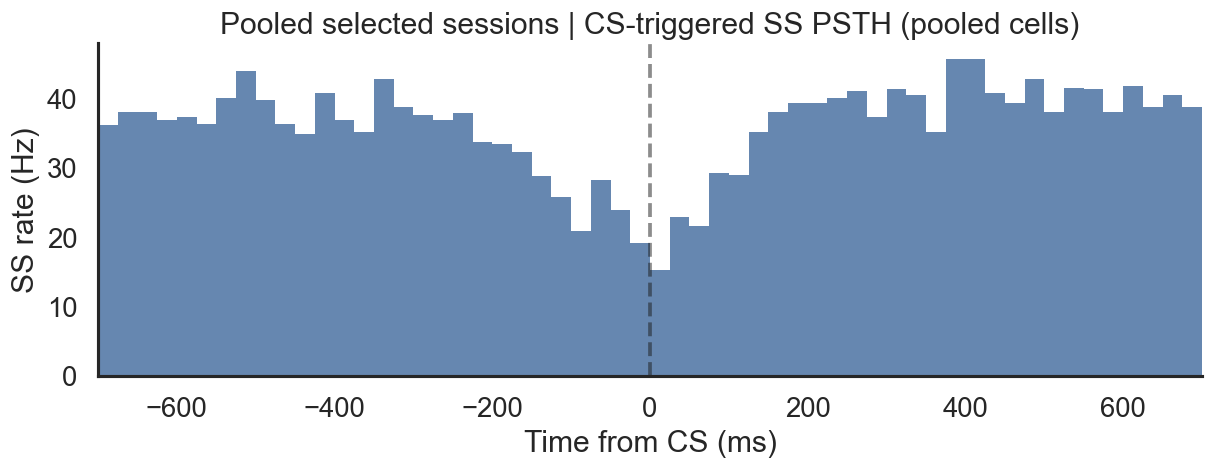

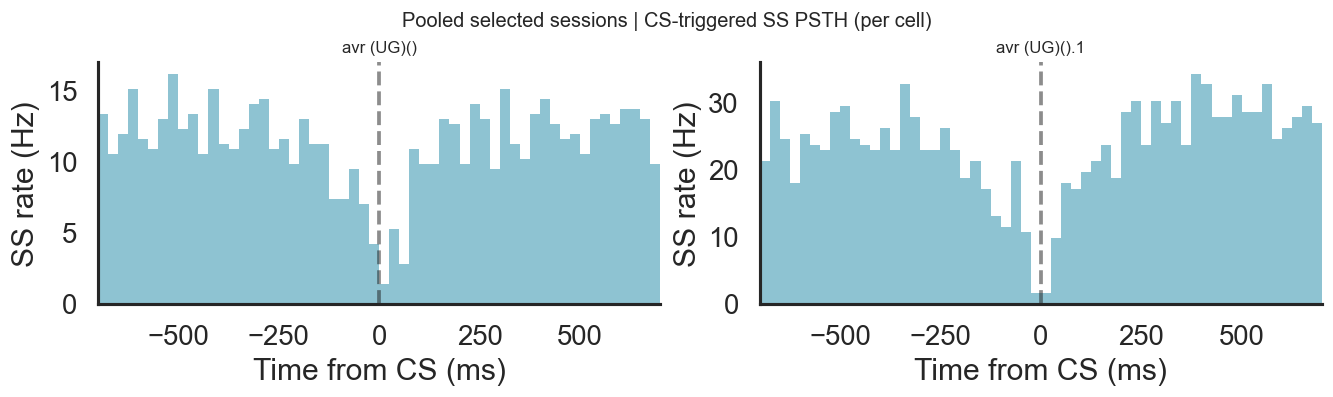

Rendered CS-triggered SS PSTH for pooled traces and per-cell panels.


In [12]:
# CS-triggered SS PSTH panels (pooled + per-cell), placed after CS-CCG output
def _collect_relative_spikes(ref_times_ms, target_times_ms, window_ms):
    ref = np.asarray(ref_times_ms, dtype=float)
    target = np.asarray(target_times_ms, dtype=float)
    if ref.size == 0 or target.size == 0:
        return np.array([], dtype=float)
    target = np.sort(target)
    rel_all = []
    w = float(window_ms)
    for t in ref:
        lo = np.searchsorted(target, t - w, side='left')
        hi = np.searchsorted(target, t + w, side='right')
        if hi > lo:
            rel_all.append(target[lo:hi] - t)
    if not rel_all:
        return np.array([], dtype=float)
    return np.concatenate(rel_all)

def _plot_cs_triggered_ss_psth(session_obj, cfg, panel_title):
    cs_window = float(cfg.get('cs_ccg_window_ms', 700.0))
    bin_ms = float(cfg.get('cs_ccg_bin_ms', 25.0))
    edges = np.arange(-cs_window, cs_window + bin_ms + 1e-9, bin_ms)
    centers = 0.5 * (edges[:-1] + edges[1:])

    pooled_cs = []
    pooled_ss = []
    for i in range(int(session_obj['n_cells'])):
        pooled_cs.append(np.asarray(session_obj['spike_times_cs'][i], dtype=float))
        pooled_ss.append(np.asarray(session_obj['spike_times_ss'][i], dtype=float))
    pooled_cs = np.concatenate(pooled_cs) if pooled_cs else np.array([], dtype=float)
    pooled_ss = np.concatenate(pooled_ss) if pooled_ss else np.array([], dtype=float)

    rel_pool = _collect_relative_spikes(pooled_cs, pooled_ss, cs_window)
    fig, ax = plt.subplots(1, 1, figsize=(10, 3.8), constrained_layout=True)
    if pooled_cs.size > 0 and rel_pool.size > 0:
        counts, _ = np.histogram(rel_pool, bins=edges)
        rate_hz = counts / (max(1, pooled_cs.size) * (bin_ms / 1000.0))
        ax.bar(centers, rate_hz, width=bin_ms, align='center', color='#5E81AC', edgecolor='none', alpha=0.95)
    else:
        ax.text(0.5, 0.5, 'Insufficient pooled CS/SS spikes', ha='center', va='center', transform=ax.transAxes)
    ax.axvline(0.0, color='k', ls='--', alpha=0.5)
    ax.set_xlim(-cs_window, cs_window)
    ax.set_xlabel('Time from CS (ms)')
    ax.set_ylabel('SS rate (Hz)')
    ax.set_title(f'{panel_title} | CS-triggered SS PSTH (pooled cells)')
    plt.show()

    n_cells_local = int(session_obj['n_cells'])
    ncols = int(min(3, max(1, n_cells_local)))
    nrows = int(np.ceil(n_cells_local / ncols))
    fig_w = max(11.0, 4.0 * ncols)
    fig_h = max(3.2, 2.9 * nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False, constrained_layout=True)

    for idx in range(nrows * ncols):
        r = idx // ncols
        c = idx % ncols
        ax = axs[r, c]
        if idx >= n_cells_local:
            ax.axis('off')
            continue

        cs_i = np.asarray(session_obj['spike_times_cs'][idx], dtype=float)
        ss_i = np.asarray(session_obj['spike_times_ss'][idx], dtype=float)
        rel_i = _collect_relative_spikes(cs_i, ss_i, cs_window)
        if cs_i.size > 0 and rel_i.size > 0:
            counts_i, _ = np.histogram(rel_i, bins=edges)
            rate_i_hz = counts_i / (max(1, cs_i.size) * (bin_ms / 1000.0))
            ax.bar(centers, rate_i_hz, width=bin_ms, align='center', color='#88C0D0', edgecolor='none', alpha=0.95)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, fontsize=9)

        ax.axvline(0.0, color='k', ls='--', alpha=0.5)
        ax.set_xlim(-cs_window, cs_window)
        name_i = session_obj['cell_names'][idx] if 'cell_names' in session_obj else f'Cell {idx + 1}'
        ax.set_title(str(name_i), fontsize=10)
        ax.set_xlabel('Time from CS (ms)')
        ax.set_ylabel('SS rate (Hz)')

    fig.suptitle(f'{panel_title} | CS-triggered SS PSTH (per cell)', fontsize=12)
    plt.show()

if CCG_PANEL.get('enabled', True):
    pooled_view = bool(CCG_PANEL.get('pooled', True))
    if pooled_view:
        pooled_title = str(CCG_PANEL.get('pooled_title', 'Pooled selected sessions'))
        sep_ms = float(max(CCG_PANEL.get('ss_acg_window_ms', 50.0), CCG_PANEL.get('ss_ccg_window_ms', 15.0), CCG_PANEL.get('cs_ccg_window_ms', 700.0))) + 5.0

        session_offsets = []
        running_offset = 0.0
        for s in sessions_for_sync:
            session_offsets.append(running_offset)
            running_offset += float(s['duration_ms']) + sep_ms

        pooled_ss = []
        pooled_cs = []
        for i in range(n_cells):
            ss_chunks = []
            cs_chunks = []
            for s, off in zip(sessions_for_sync, session_offsets):
                ss_chunks.append(np.asarray(s['spike_times_ss'][i], dtype=float) + off)
                cs_chunks.append(np.asarray(s['spike_times_cs'][i], dtype=float) + off)
            pooled_ss.append(np.sort(np.concatenate(ss_chunks) if ss_chunks else np.array([], dtype=float)))
            pooled_cs.append(np.sort(np.concatenate(cs_chunks) if cs_chunks else np.array([], dtype=float)))

        pooled_panel_session = {
            'session_name': pooled_title,
            'n_cells': n_cells,
            'cell_names': cell_names,
            'spike_times_ss': pooled_ss,
            'spike_times_cs': pooled_cs,
        }
        _plot_cs_triggered_ss_psth(pooled_panel_session, CCG_PANEL, pooled_title)
    else:
        target = CCG_PANEL.get('sessions', 'all-selected')
        if isinstance(target, str):
            key = target.strip().lower()
            if key == 'first':
                sessions_for_ccg = [sessions_for_sync[0]]
            elif key == 'all-selected':
                sessions_for_ccg = sessions_for_sync
            elif key == 'max-cs':
                sessions_for_ccg = [max(sessions_for_sync, key=lambda s: sum(len(x) for x in s['spike_times_cs']))]
            else:
                sessions_for_ccg = [s for s in sessions_for_sync if s['session_name'] == target]
        elif isinstance(target, (list, tuple, set)):
            wanted = set(target)
            sessions_for_ccg = [s for s in sessions_for_sync if s['session_name'] in wanted]
        else:
            sessions_for_ccg = [sessions_for_sync[0]]

        for s in sessions_for_ccg:
            _plot_cs_triggered_ss_psth(s, CCG_PANEL, s['session_name'])

print('Rendered CS-triggered SS PSTH for pooled traces and per-cell panels.')

In [13]:
# Backward-compatible bin-key aliases for synchrony/event-window cells
if 'ss_sync_bin_ms' not in EVENT_CONFIG:
    EVENT_CONFIG['ss_sync_bin_ms'] = float(EVENT_CONFIG.get('event_sync_bin_ms', SS_EVENT_BIN_MS))
if 'cs_sync_bin_ms' not in EVENT_CONFIG:
    EVENT_CONFIG['cs_sync_bin_ms'] = float(EVENT_CONFIG.get('event_sync_bin_ms', CS_EVENT_BIN_MS))

print('EVENT_CONFIG bin aliases ready:')
print(f"  ss_sync_bin_ms={EVENT_CONFIG['ss_sync_bin_ms']}")
print(f"  cs_sync_bin_ms={EVENT_CONFIG['cs_sync_bin_ms']}")

EVENT_CONFIG bin aliases ready:
  ss_sync_bin_ms=5.0
  cs_sync_bin_ms=5.0



How to decide whether a small SS-CCG peak reflects significant pair correlation:
- Use the windowed STTC value and its jitter null, not the CCG peak height alone (SS dt/bin=5.00 ms).
- In practice, inspect the pair-level shuffle p-value and z-score for each baseline/response window.
- A visually similar near-zero CCG bump across all pairs can come from shared event locking or slow co-modulation, even when pairwise synchrony is not significant.
- Stronger evidence is: small p, large positive z, and reproducibility in the same pair across sessions or windows.

Windowed SS pair significance summary:


,window,cell_i,cell_j,n_event_windows,n_ref_spikes,n_target_spikes,metric_value,p_value,z_score,zero_lag_peak_prob,global_peak_prob,significant_p_lt_0_05
0,baseline,avr (UG)(),avr (UG)().1,9,32,68,0.062275,0.897103,-0.176369,0.00953,0.046788,False
1,response,avr (UG)(),avr (UG)().1,9,0,0,NaN,NaN,NaN,0.00000,0.000000,False


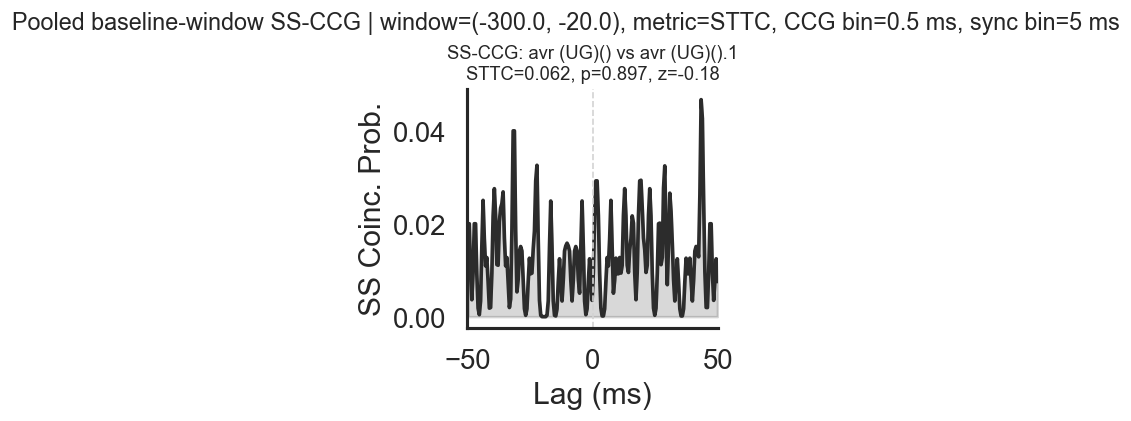

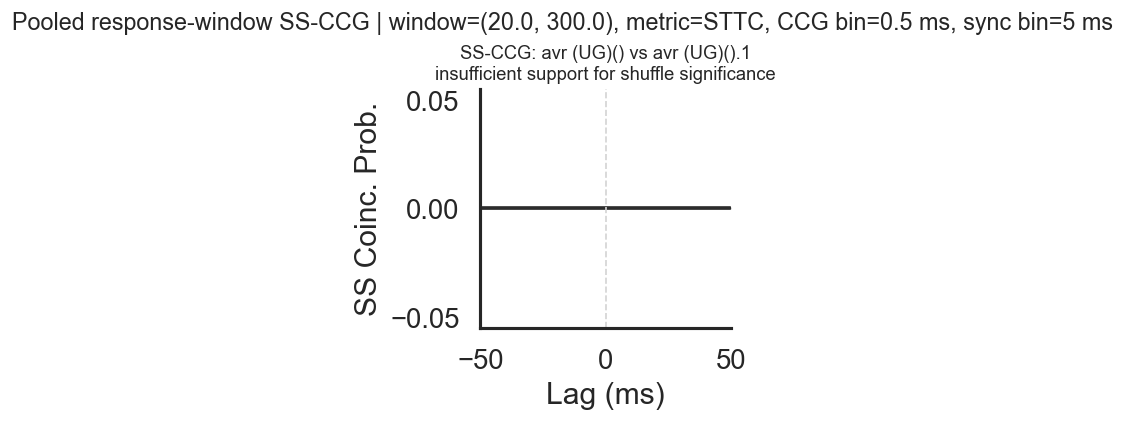

In [14]:
# SS-CCG before vs after puff using the same event windows as SS synchrony analysis,
# but with the same smoothed CCG calculation and grid plotting style as the whole-trace SS-CCG panel.


def _event_times_for_session_safe(session_obj, event_cache_obj):
    if '_get_session_event_times_ms' in globals():
        try:
            return _get_session_event_times_ms(session_obj, EVENT_CONFIG, cache=event_cache_obj)
        except Exception:
            pass
    return np.array([float(EVENT_CONFIG.get('event_time_ms', EVENT_ONSET_MS))], dtype=float)


def _pool_event_window_pair_spikes(sessions_local, cell_i, cell_j, window_rel_ms, sep_ms):
    w0, w1 = float(window_rel_ms[0]), float(window_rel_ms[1])
    window_len = float(w1 - w0)
    if window_len <= 0:
        return {
            'ref': np.array([], dtype=float),
            'target': np.array([], dtype=float),
            't_start': 0.0,
            't_end': 0.0,
            'n_segments': 0,
            'n_ref_spikes': 0,
            'n_target_spikes': 0,
        }

    ref_chunks = []
    target_chunks = []
    running_offset = 0.0
    n_segments = 0
    event_cache = {}

    for s in sessions_local:
        event_times_ms = np.asarray(_event_times_for_session_safe(s, event_cache), dtype=float)
        for event_time_ms in event_times_ms:
            t0 = float(event_time_ms) + w0
            t1 = float(event_time_ms) + w1
            if t1 <= t0:
                continue

            ref = np.asarray(s['spike_times_ss'][cell_i], dtype=float)
            target = np.asarray(s['spike_times_ss'][cell_j], dtype=float)
            ref = ref[(ref >= t0) & (ref < t1)] - t0 + running_offset
            target = target[(target >= t0) & (target < t1)] - t0 + running_offset
            ref_chunks.append(ref)
            target_chunks.append(target)
            running_offset += window_len + sep_ms
            n_segments += 1

    if n_segments == 0:
        return {
            'ref': np.array([], dtype=float),
            'target': np.array([], dtype=float),
            't_start': 0.0,
            't_end': 0.0,
            'n_segments': 0,
            'n_ref_spikes': 0,
            'n_target_spikes': 0,
        }

    ref_pool = np.sort(np.concatenate(ref_chunks)) if ref_chunks else np.array([], dtype=float)
    target_pool = np.sort(np.concatenate(target_chunks)) if target_chunks else np.array([], dtype=float)
    t_end = max(0.0, running_offset - sep_ms)
    return {
        'ref': ref_pool,
        'target': target_pool,
        't_start': 0.0,
        't_end': t_end,
        'n_segments': int(n_segments),
        'n_ref_spikes': int(ref_pool.size),
        'n_target_spikes': int(target_pool.size),
    }


def _windowed_pair_ccg_and_significance(sessions_local, cell_i, cell_j, window_rel_ms, ccg_cfg, sync_bin_ms, sync_cfg):
    ccg_window_ms = float(ccg_cfg['ss_ccg_window_ms'])
    ccg_bin_ms = float(ccg_cfg['ss_ccg_bin_ms'])
    sigma_bins = float(ccg_cfg.get('smooth_sigma_bins', 1.2))
    sep_ms = float(max(ccg_window_ms * 2.0, abs(window_rel_ms[1] - window_rel_ms[0])) + 10.0)

    pooled = _pool_event_window_pair_spikes(sessions_local, cell_i, cell_j, window_rel_ms, sep_ms)
    lag, prob = compute_prob_ccg(
        pooled['ref'],
        pooled['target'],
        bin_ms=ccg_bin_ms,
        window_ms=ccg_window_ms,
        sigma_bins=sigma_bins,
        is_acg=False,
    )

    metric_val, p_val, z_val = shuffle_significance(
        pooled['ref'],
        pooled['target'],
        pooled['t_start'],
        pooled['t_end'],
        bin_ms=sync_bin_ms,
        n_shuffles=int(globals().get('SIGNIFICANCE_TEST_CONFIG', {}).get('n_null_shuffles', 1000)),
        cfg=sync_cfg,
    )

    zero_mask = np.abs(lag) <= max(ccg_bin_ms * 0.5, 1e-9)
    zero_peak = float(np.nanmax(prob[zero_mask])) if np.any(zero_mask) and prob.size else np.nan
    global_peak = float(np.nanmax(prob)) if prob.size else np.nan

    return {
        'lag': lag,
        'prob': prob,
        'metric': _safe_scalar(metric_val),
        'p': _safe_scalar(p_val),
        'z': _safe_scalar(z_val),
        'zero_peak': _safe_scalar(zero_peak),
        'global_peak': _safe_scalar(global_peak),
        'n_segments': int(pooled['n_segments']),
        'n_ref_spikes': int(pooled['n_ref_spikes']),
        'n_target_spikes': int(pooled['n_target_spikes']),
    }


print('\nHow to decide whether a small SS-CCG peak reflects significant pair correlation:')
if _metric_name_from_cfg(SYNC_CONFIG) == 'sttc':
    print(f"- Use the windowed STTC value and its jitter null, not the CCG peak height alone (SS dt/bin={float(SYNC_CONFIG['ss_bin_ms']):.2f} ms).")
else:
    print(f"- Use the windowed Pearson spike-count correlation and its circular-shift null, not the CCG peak height alone (bin={float(EVENT_CONFIG['ss_sync_bin_ms']):g} ms).")
print('- In practice, inspect the pair-level shuffle p-value and z-score for each baseline/response window.')
print('- A visually similar near-zero CCG bump across all pairs can come from shared event locking or slow co-modulation, even when pairwise synchrony is not significant.')
print('- Stronger evidence is: small p, large positive z, and reproducibility in the same pair across sessions or windows.')

if n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping pre/post SS-CCG plots.')
else:
    pair_source = pair_stats_df[pair_stats_df['spike_type'] == 'SS'].copy() if 'pair_stats_df' in globals() else pd.DataFrame()
    if pair_source.empty:
        print('No SS pair statistics available for pre/post SS-CCG plotting.')
    else:
        pair_source['r'] = pd.to_numeric(pair_source['r'], errors='coerce')
        ranked_pairs = (pair_source.groupby(['i', 'j', 'cell_i', 'cell_j'], as_index=False)
                        .agg(mean_r=('r', 'mean'))
                        .sort_values('mean_r', ascending=True))
        if len(ranked_pairs) > int(CCG_PANEL.get('max_ccg_pairs', 6)):
            top_pairs = pd.concat([ranked_pairs.tail(4).sort_values('mean_r', ascending=False), ranked_pairs.head(2)], ignore_index=True)
        else:
            top_pairs = ranked_pairs.sort_values('mean_r', ascending=False)

        baseline_w = EVENT_CONFIG['ss_sync_baseline_ms']
        response_w = EVENT_CONFIG['ss_sync_response_ms']
        sync_bin_ms = float(EVENT_CONFIG['ss_sync_bin_ms'])

        baseline_specs = []
        response_specs = []
        summary_rows = []

        for row in top_pairs.itertuples(index=False):
            i, j = int(row.i), int(row.j)
            c_i, c_j = str(row.cell_i), str(row.cell_j)

            pre_res = _windowed_pair_ccg_and_significance(
                sessions_for_sync, i, j, baseline_w, CCG_PANEL, sync_bin_ms, SYNC_CONFIG
            )
            post_res = _windowed_pair_ccg_and_significance(
                sessions_for_sync, i, j, response_w, CCG_PANEL, sync_bin_ms, SYNC_CONFIG
            )

            metric_label = 'STTC' if _metric_name_from_cfg(SYNC_CONFIG) == 'sttc' else 'r'
            pre_sig = np.isfinite(pre_res['p']) and (pre_res['p'] < 0.05)
            post_sig = np.isfinite(post_res['p']) and (post_res['p'] < 0.05)

            baseline_specs.append({
                'x': pre_res['lag'],
                'y': pre_res['prob'],
                'title': (
                    f'SS-CCG: {c_i} vs {c_j}\n'
                    f'{metric_label}={pre_res["metric"]:.3f}, {_format_pq_value(pre_res["p"], "p")}, z={pre_res["z"]:.2f}'
                    if np.isfinite(pre_res['metric']) and np.isfinite(pre_res['p']) and np.isfinite(pre_res['z'])
                    else f'SS-CCG: {c_i} vs {c_j}\ninsufficient support for shuffle significance'
                ),
                'line_color': '#2C2C2C',
                'fill_color': '#2C2C2C',
                'alpha': 0.18,
                'ylabel': 'SS Coinc. Prob.' if len(baseline_specs) == 0 else None,
                'xlabel': 'Lag (ms)',
                'xlim': (-float(CCG_PANEL['ss_ccg_window_ms']), float(CCG_PANEL['ss_ccg_window_ms'])),
            })
            response_specs.append({
                'x': post_res['lag'],
                'y': post_res['prob'],
                'title': (
                    f'SS-CCG: {c_i} vs {c_j}\n'
                    f'{metric_label}={post_res["metric"]:.3f}, {_format_pq_value(post_res["p"], "p")}, z={post_res["z"]:.2f}'
                    if np.isfinite(post_res['metric']) and np.isfinite(post_res['p']) and np.isfinite(post_res['z'])
                    else f'SS-CCG: {c_i} vs {c_j}\ninsufficient support for shuffle significance'
                ),
                'line_color': '#2C2C2C',
                'fill_color': '#2C2C2C',
                'alpha': 0.18,
                'ylabel': 'SS Coinc. Prob.' if len(response_specs) == 0 else None,
                'xlabel': 'Lag (ms)',
                'xlim': (-float(CCG_PANEL['ss_ccg_window_ms']), float(CCG_PANEL['ss_ccg_window_ms'])),
            })

            summary_rows.extend([
                {
                    'window': 'baseline',
                    'cell_i': c_i,
                    'cell_j': c_j,
                    'n_event_windows': pre_res['n_segments'],
                    'n_ref_spikes': pre_res['n_ref_spikes'],
                    'n_target_spikes': pre_res['n_target_spikes'],
                    'metric_value': pre_res['metric'],
                    'p_value': pre_res['p'],
                    'z_score': pre_res['z'],
                    'zero_lag_peak_prob': pre_res['zero_peak'],
                    'global_peak_prob': pre_res['global_peak'],
                    'significant_p_lt_0_05': bool(pre_sig),
                },
                {
                    'window': 'response',
                    'cell_i': c_i,
                    'cell_j': c_j,
                    'n_event_windows': post_res['n_segments'],
                    'n_ref_spikes': post_res['n_ref_spikes'],
                    'n_target_spikes': post_res['n_target_spikes'],
                    'metric_value': post_res['metric'],
                    'p_value': post_res['p'],
                    'z_score': post_res['z'],
                    'zero_lag_peak_prob': post_res['zero_peak'],
                    'global_peak_prob': post_res['global_peak'],
                    'significant_p_lt_0_05': bool(post_sig),
                },
            ])

        summary_df = pd.DataFrame(summary_rows)
        print('\nWindowed SS pair significance summary:')
        display_top(summary_df, label='Windowed SS pair significance summary', sort_by='metric_value')

        _plot_grid_panels(
            baseline_specs,
            ncols=3,
            suptitle=(
                f"Pooled baseline-window SS-CCG | window={baseline_w}, "
                f"metric={_metric_name_from_cfg(SYNC_CONFIG).upper()}, "
                f"CCG bin={float(CCG_PANEL['ss_ccg_bin_ms']):g} ms, sync bin={sync_bin_ms:g} ms"
            ),
            cfg=CCG_PANEL,
        )
        if EXPORT_PLOTS:
            plt.gcf().savefig(os.path.join(EXPORT_DIR, 'ss_ccg_baseline_sync_window.svg'), format='svg', bbox_inches='tight')
        plt.show()

        _plot_grid_panels(
            response_specs,
            ncols=3,
            suptitle=(
                f"Pooled response-window SS-CCG | window={response_w}, "
                f"metric={_metric_name_from_cfg(SYNC_CONFIG).upper()}, "
                f"CCG bin={float(CCG_PANEL['ss_ccg_bin_ms']):g} ms, sync bin={sync_bin_ms:g} ms"
            ),
            cfg=CCG_PANEL,
        )
        if EXPORT_PLOTS:
            plt.gcf().savefig(os.path.join(EXPORT_DIR, 'ss_ccg_response_sync_window.svg'), format='svg', bbox_inches='tight')
        plt.show()

In [15]:
# Diagnostic: verify event/spike time scales and window occupancy for SS pre/post CCG
diag_rows = []
evt_cache = {}
for s in sessions_for_sync[:min(3, len(sessions_for_sync))]:
    evt = np.asarray(_event_times_for_session_safe(s, evt_cache), dtype=float)
    ss0 = np.asarray(s['spike_times_ss'][0], dtype=float) if int(s['n_cells']) > 0 else np.array([], dtype=float)
    diag_rows.append({
        'session': s['session_name'],
        'n_events': int(evt.size),
        'event_min': float(np.nanmin(evt)) if evt.size else np.nan,
        'event_max': float(np.nanmax(evt)) if evt.size else np.nan,
        'ss0_min': float(np.nanmin(ss0)) if ss0.size else np.nan,
        'ss0_max': float(np.nanmax(ss0)) if ss0.size else np.nan,
        'duration_ms': float(s.get('duration_ms', np.nan)),
    })

diag_df = pd.DataFrame(diag_rows)
print('Event/spike range diagnostic (first sessions):')
display_top(diag_df, label='Event/spike time-scale diagnostics')

if 'top_pairs' in globals() and len(top_pairs) > 0:
    row = next(top_pairs.itertuples(index=False))
    i, j = int(row.i), int(row.j)
    baseline_w = EVENT_CONFIG['ss_sync_baseline_ms']
    response_w = EVENT_CONFIG['ss_sync_response_ms']
    sep_ms = float(max(float(CCG_PANEL['ss_ccg_window_ms']) * 2.0, abs(response_w[1] - response_w[0])) + 10.0)

    pre_pool = _pool_event_window_pair_spikes(sessions_for_sync, i, j, baseline_w, sep_ms)
    post_pool = _pool_event_window_pair_spikes(sessions_for_sync, i, j, response_w, sep_ms)
    print('Top-pair pooled occupancy diagnostic:')
    print({
        'pair': (str(row.cell_i), str(row.cell_j)),
        'baseline_n_segments': int(pre_pool['n_segments']),
        'baseline_ref_spikes': int(pre_pool['n_ref_spikes']),
        'baseline_target_spikes': int(pre_pool['n_target_spikes']),
        'response_n_segments': int(post_pool['n_segments']),
        'response_ref_spikes': int(post_pool['n_ref_spikes']),
        'response_target_spikes': int(post_pool['n_target_spikes']),
    })

Event/spike range diagnostic (first sessions):


,session,n_events,event_min,event_max,ss0_min,ss0_max,duration_ms
0,pair_10,1,10000.0,10000.0,151.92,9967.20,9999.84
1,pair_11,1,10000.0,10000.0,196.32,9991.68,9999.84
2,pair_13,1,10000.0,10000.0,268.08,9969.12,9999.84


Top-pair pooled occupancy diagnostic:
{'pair': ('avr (UG)()', 'avr (UG)().1'), 'baseline_n_segments': 9, 'baseline_ref_spikes': 32, 'baseline_target_spikes': 68, 'response_n_segments': 9, 'response_ref_spikes': 0, 'response_target_spikes': 0}


In [16]:
def _ensure_event_cfg_compat(event_cfg):
    # Backward-compatible aliases so old/new config schemas both work.
    event_cfg.setdefault('ss_window_ms', event_cfg.get('event_rate_window_ms', (-800.0, 1200.0)))
    event_cfg.setdefault('cs_window_ms', event_cfg.get('event_rate_window_ms', (-800.0, 1200.0)))
    event_cfg.setdefault('ss_bin_ms', float(event_cfg.get('event_rate_bin_ms', event_cfg.get('event_sync_bin_ms', 10.0))))
    event_cfg.setdefault('cs_bin_ms', float(event_cfg.get('event_rate_bin_ms', event_cfg.get('event_sync_bin_ms', 10.0))))
    event_cfg.setdefault('ss_sync_bin_ms', float(event_cfg.get('event_sync_bin_ms', event_cfg.get('ss_bin_ms', 5.0))))
    event_cfg.setdefault('cs_sync_bin_ms', float(event_cfg.get('event_sync_bin_ms', event_cfg.get('cs_bin_ms', 5.0))))
    event_cfg.setdefault('behavior_csv_glob', event_cfg.get('event_csv_glob', '**/*.csv'))
    event_cfg.setdefault('auto_detect_event', str(event_cfg.get('event_detect_method', '')).strip().lower() == 'behavior_puff')
    return event_cfg


def event_locked_hist(spike_times, event_time_ms, window_ms, bin_ms):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    rel = spike_times - event_time_ms
    rel = rel[(rel >= w0) & (rel <= w1)]
    bins = np.arange(w0, w1 + bin_ms, bin_ms)
    counts, edges = np.histogram(rel, bins=bins)
    centers = edges[:-1] + bin_ms / 2
    rate_hz = counts.astype(float) / (bin_ms / 1000.0)  # one event/trial per row
    return centers, rate_hz, rel


def event_locked_bin_likelihood(spike_times, event_time_ms, window_ms, bin_ms):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    rel = spike_times - event_time_ms
    rel = rel[(rel >= w0) & (rel <= w1)]
    bins = np.arange(w0, w1 + bin_ms, bin_ms)
    counts, edges = np.histogram(rel, bins=bins)
    centers = edges[:-1] + bin_ms / 2
    likelihood = (counts > 0).astype(float)  # per-bin binary occurrence
    return centers, likelihood


def interval_rate(spike_times, event_time_ms, interval_ms):
    a, b = interval_ms
    t0 = event_time_ms + a
    t1 = event_time_ms + b
    dur_s = (b - a) / 1000.0
    if dur_s <= 0:
        return np.nan
    n = np.sum((spike_times >= t0) & (spike_times < t1))
    return float(n) / dur_s


def interval_spike_likelihood(spike_times, event_time_ms, interval_ms):
    a, b = interval_ms
    t0 = event_time_ms + a
    t1 = event_time_ms + b
    if t1 <= t0:
        return np.nan
    has_spike = np.any((spike_times >= t0) & (spike_times < t1))
    return float(has_spike)


def modulation_metrics(spike_times, event_time_ms, baseline_ms, response_ms):
    base = interval_rate(spike_times, event_time_ms, baseline_ms)
    resp = interval_rate(spike_times, event_time_ms, response_ms)
    eps = 1e-9
    mod_index = (resp - base) / (resp + base + eps)

    # Avoid inflated percent changes when baseline is essentially zero.
    if np.isfinite(base) and abs(base) > 1e-6:
        pct_change = ((resp - base) / base) * 100.0
    else:
        pct_change = np.nan

    return base, resp, mod_index, pct_change


# ---------------------------
# Auto event detection helpers
# ---------------------------
def _find_col_case_insensitive(df, preferred_name, fallbacks=None):
    cols = list(df.columns)
    by_lower = {str(c).strip().lower(): c for c in cols}

    names = [preferred_name] + list(fallbacks or [])
    for n in names:
        key = str(n).strip().lower()
        if key in by_lower:
            return by_lower[key]

    # Last-resort heuristics
    for c in cols:
        cl = str(c).strip().lower()
        if 'arduino' in cl and 'state' in cl:
            return c
    for c in cols:
        cl = str(c).strip().lower()
        if cl.startswith('time'):
            return c
    return None


def _find_behavior_csv_for_session(session, event_cfg):
    token = str(session.get('session_name', '')).strip().lower()
    pattern = str(event_cfg.get('behavior_csv_glob', '**/*.csv'))

    roots = []
    for r in [
        globals().get('DATA_FOLDER', None),
        os.path.dirname(os.path.dirname(str(session.get('npz_path', '')))),
        os.path.dirname(str(session.get('npz_path', ''))),
    ]:
        if r and os.path.isdir(r) and r not in roots:
            roots.append(r)

    candidates = []
    recursive = ('**' in pattern)
    for root in roots:
        candidates.extend(glob.glob(os.path.join(root, pattern), recursive=recursive))

    # Keep unique .csv files only.
    csv_paths = []
    seen = set()
    for p in candidates:
        pl = str(p).lower()
        if not pl.endswith('.csv'):
            continue
        if p not in seen:
            seen.add(p)
            csv_paths.append(p)

    if not csv_paths:
        return None

    # Prefer files whose basename contains session token.
    token_hits = []
    for p in csv_paths:
        b = os.path.splitext(os.path.basename(p))[0].lower()
        if token and token in b:
            score = (0 if b == token else 1, abs(len(b) - len(token)), len(b))
            token_hits.append((score, p))

    if token_hits:
        token_hits.sort(key=lambda x: x[0])
        return token_hits[0][1]

    return None


def _detect_event_times_from_behavior_csv(csv_path, event_cfg):
    if csv_path is None or not os.path.isfile(csv_path):
        return np.array([], dtype=float), None, None

    df = pd.read_csv(csv_path)
    if df.empty:
        return np.array([], dtype=float), None, None

    state_col = _find_col_case_insensitive(
        df,
        event_cfg.get('behavior_state_col', 'Arduino_State'),
        fallbacks=['arduino_state', 'Arduino state', 'state'],
    )
    time_col = _find_col_case_insensitive(
        df,
        event_cfg.get('behavior_time_col_candidates', ['Time_s'])[0],
        fallbacks=event_cfg.get('behavior_time_col_candidates', ['Time_s', 'Time_ms', 'time_s', 'time_ms']),
    )

    if state_col is None or time_col is None:
        return np.array([], dtype=float), state_col, time_col

    state_vals = pd.to_numeric(df[state_col], errors='coerce').to_numpy()
    time_vals = pd.to_numeric(df[time_col], errors='coerce').to_numpy()

    valid = np.isfinite(state_vals) & np.isfinite(time_vals)
    if not np.any(valid):
        return np.array([], dtype=float), state_col, time_col

    on_value = float(event_cfg.get('behavior_state_on_value', 1))
    on_mask = valid & (state_vals == on_value)

    # One puff per rising edge even if Arduino state stays high for multiple rows.
    prev_on = np.r_[False, on_mask[:-1]]
    rising_idx = np.where(on_mask & (~prev_on))[0]

    if rising_idx.size == 0:
        return np.array([], dtype=float), state_col, time_col

    event_times = time_vals[rising_idx].astype(float)

    units_cfg = str(event_cfg.get('behavior_time_units', 's')).strip().lower()
    time_col_l = str(time_col).strip().lower()

    if units_cfg == 'ms':
        event_times_ms = event_times
    elif units_cfg == 's':
        event_times_ms = event_times * 1000.0
    else:
        # Auto fallback by column name if units setting is unexpected.
        event_times_ms = event_times if ('ms' in time_col_l) else (event_times * 1000.0)

    event_times_ms = np.asarray(event_times_ms, dtype=float)
    event_times_ms = event_times_ms[np.isfinite(event_times_ms)]
    event_times_ms = np.unique(np.round(event_times_ms, 6))
    event_times_ms.sort()

    max_events = event_cfg.get('max_events_per_session', None)
    if max_events is not None:
        max_events = int(max_events)
        if max_events > 0:
            event_times_ms = event_times_ms[:max_events]

    return event_times_ms, state_col, time_col


def _get_session_event_times_ms(session, event_cfg, cache=None):
    sess_name = str(session.get('session_name', ''))
    if cache is not None and sess_name in cache:
        return cache[sess_name]

    _ensure_event_cfg_compat(event_cfg)

    auto_detect = bool(event_cfg.get('auto_detect_event', False))
    fallback_time = float(event_cfg.get('event_time_ms', np.nan))

    if not auto_detect:
        out = np.array([fallback_time], dtype=float) if np.isfinite(fallback_time) else np.array([], dtype=float)
        session['event_source'] = 'manual fixed time' if out.size else 'no-event (manual fallback missing)'
        if cache is not None:
            cache[sess_name] = out
        return out

    csv_path = _find_behavior_csv_for_session(session, event_cfg)
    event_times_ms, state_col, time_col = _detect_event_times_from_behavior_csv(csv_path, event_cfg)

    if event_times_ms.size == 0:
        if np.isfinite(fallback_time):
            out = np.array([fallback_time], dtype=float)
            source = 'manual fallback (no auto events found)'
        else:
            out = np.array([], dtype=float)
            source = 'no-event (auto detect found none; fallback missing)'
    else:
        out = event_times_ms
        source = f'auto from CSV: {os.path.basename(csv_path)}'

    session['event_times_ms'] = out
    session['event_source'] = source
    session['behavior_csv_path'] = csv_path

    if bool(event_cfg.get('event_detection_verbose', True)):
        if event_times_ms.size == 0:
            print(f"[event-detect] {sess_name}: no valid auto event found; using fallback {fallback_time:.3f} ms")
        else:
            print(
                f"[event-detect] {sess_name}: detected {len(out)} event(s) from {os.path.basename(csv_path)} "
                f"(state_col={state_col}, time_col={time_col})"
            )

    if cache is not None:
        cache[sess_name] = out
    return out


def run_event_modulation(sessions, event_cfg):
    _ensure_event_cfg_compat(event_cfg)
    rows = []
    pooled = {'SS': [], 'CS': []}
    event_cache = {}

    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, event_cfg, cache=event_cache)

        for event_idx, event_time_ms in enumerate(event_times_ms):
            for stype in ['SS', 'CS']:
                spikes_all = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
                window = event_cfg['ss_window_ms'] if stype == 'SS' else event_cfg['cs_window_ms']
                bin_ms = event_cfg['ss_bin_ms'] if stype == 'SS' else event_cfg['cs_bin_ms']
                base_w = event_cfg['ss_rate_baseline_ms'] if stype == 'SS' else event_cfg['cs_rate_baseline_ms']
                resp_w = event_cfg['ss_rate_response_ms'] if stype == 'SS' else event_cfg['cs_rate_response_ms']

                # Per-cell metrics + collect PETH for pooled summary
                for i, st in enumerate(spikes_all):
                    centers, rate, rel = event_locked_hist(st, event_time_ms, window, bin_ms)
                    base, resp, mi, pct = modulation_metrics(st, event_time_ms, base_w, resp_w)
                    rows.append({
                        'session': s['session_name'],
                        'event_idx': int(event_idx),
                        'event_time_ms': float(event_time_ms),
                        'event_source': s.get('event_source', 'manual'),
                        'spike_type': stype,
                        'cell': s['cell_names'][i],
                        'baseline_hz': base,
                        'response_hz': resp,
                        'mod_index': mi,
                        'pct_change': pct,
                    })
                    pooled[stype].append(rate)

    cols = [
        'session', 'event_idx', 'event_time_ms', 'event_source', 'spike_type', 'cell',
        'baseline_hz', 'response_hz', 'mod_index', 'pct_change'
    ]
    return pd.DataFrame(rows, columns=cols), pooled


def run_event_spike_likelihood(sessions, event_cfg):
    _ensure_event_cfg_compat(event_cfg)
    rows = []
    event_cache = {}

    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, event_cfg, cache=event_cache)

        for event_idx, event_time_ms in enumerate(event_times_ms):
            for stype in ['SS', 'CS']:
                spikes_all = s['spike_times_ss'] if stype == 'SS' else s['spike_times_cs']
                base_w = event_cfg['ss_rate_baseline_ms'] if stype == 'SS' else event_cfg['cs_rate_baseline_ms']
                resp_w = event_cfg['ss_rate_response_ms'] if stype == 'SS' else event_cfg['cs_rate_response_ms']

                for i, st in enumerate(spikes_all):
                    p_base = interval_spike_likelihood(st, event_time_ms, base_w)
                    p_resp = interval_spike_likelihood(st, event_time_ms, resp_w)
                    delta_p = p_resp - p_base if np.isfinite(p_resp) and np.isfinite(p_base) else np.nan
                    rows.append({
                        'session': s['session_name'],
                        'event_idx': int(event_idx),
                        'event_time_ms': float(event_time_ms),
                        'event_source': s.get('event_source', 'manual'),
                        'spike_type': stype,
                        'cell': s['cell_names'][i],
                        'baseline_likelihood': p_base,
                        'response_likelihood': p_resp,
                        'delta_likelihood': delta_p,
                    })
    cols = [
        'session', 'event_idx', 'event_time_ms', 'event_source', 'spike_type', 'cell',
        'baseline_likelihood', 'response_likelihood', 'delta_likelihood'
    ]
    return pd.DataFrame(rows, columns=cols)


event_df, pooled_event = run_event_modulation(sessions, EVENT_CONFIG)

print(f"Event modulation rows: {len(event_df)}")
print(f"Sessions represented in event_df: {event_df['session'].nunique()}")
if 'event_idx' in event_df.columns:
    event_counts = (event_df[['session', 'event_idx']].drop_duplicates()
                    .groupby('session').size().rename('n_events').reset_index())
    print('\nDetected/used event count per session:')
    display_top(event_counts, label='Event counts by session')

# Explicit pooled summaries across sessions (requested)
event_pooled_summary = (event_df.groupby('spike_type', as_index=False)
                        .agg(n_sessions=('session', 'nunique'),
                             n_events=('event_idx', 'nunique'),
                             n_cells=('cell', 'count'),
                             baseline_hz_mean=('baseline_hz', 'mean'),
                             response_hz_mean=('response_hz', 'mean'),
                             mod_index_mean=('mod_index', 'mean'),
                             pct_change_mean=('pct_change', 'mean')))

# Also keep per-session summary for context
event_session_summary = (event_df.groupby(['session', 'spike_type'], as_index=False)
                         .agg(n_events=('event_idx', 'nunique'),
                              n_rows=('cell', 'count'),
                              baseline_hz_mean=('baseline_hz', 'mean'),
                              response_hz_mean=('response_hz', 'mean'),
                              mod_index_mean=('mod_index', 'mean'),
                              pct_change_mean=('pct_change', 'mean')))

print('\nPooled event modulation summary (across all loaded sessions):')
display_top(event_pooled_summary, label='Pooled event summary')

print('\nPer-session event modulation summary:')
display_top(event_session_summary, label='Per-session event summary')

if EVENT_LIKELIHOOD_CONFIG.get('enabled', True):
    event_likelihood_df = run_event_spike_likelihood(sessions, EVENT_CONFIG)
    event_likelihood_summary = (event_likelihood_df.groupby('spike_type', as_index=False)
                                .agg(n_sessions=('session', 'nunique'),
                                     n_events=('event_idx', 'nunique'),
                                     n_cells=('cell', 'count'),
                                     baseline_likelihood_mean=('baseline_likelihood', 'mean'),
                                     response_likelihood_mean=('response_likelihood', 'mean'),
                                     delta_likelihood_mean=('delta_likelihood', 'mean')))
    print('\nPooled event spike-likelihood summary (across all loaded sessions):')
    display_top(event_likelihood_summary, label='Event likelihood summary')

print('\nFirst rows of full event_df:')
display(event_df.head())

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms
Event modulation rows: 36
Sessions represented in event_df: 9

Detected/used event count per session:


,session,n_events
0,pair_10,1
1,pair_11,1
2,pair_13,1
3,pair_14,1
4,pair_15,1
5,pair_4,1
6,pair_5,1
7,pair_7,1
8,pair_8,1



Pooled event modulation summary (across all loaded sessions):


,spike_type,n_sessions,n_events,n_cells,baseline_hz_mean,response_hz_mean,mod_index_mean,pct_change_mean
0,CS,9,1,18,0.444444,0.0,-0.111111,-100.0
1,SS,9,1,18,20.476190,0.0,-1.000000,-100.0



Per-session event modulation summary:


,session,spike_type,n_events,n_rows,baseline_hz_mean,response_hz_mean,mod_index_mean,pct_change_mean
0,pair_10,CS,1,2,0.000000,0.0,0.0,NaN
1,pair_10,SS,1,2,25.714286,0.0,-1.0,-100.0
2,pair_11,CS,1,2,2.000000,0.0,-0.5,-100.0
3,pair_11,SS,1,2,17.142857,0.0,-1.0,-100.0
4,pair_13,CS,1,2,0.000000,0.0,0.0,NaN
5,pair_13,SS,1,2,24.285714,0.0,-1.0,-100.0
6,pair_14,CS,1,2,2.000000,0.0,-0.5,-100.0
7,pair_14,SS,1,2,14.285714,0.0,-1.0,-100.0
8,pair_15,CS,1,2,0.000000,0.0,0.0,NaN
9,pair_15,SS,1,2,24.285714,0.0,-1.0,-100.0


[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms

Pooled event spike-likelihood summary (across all loaded sessions):


,spike_type,n_sessions,n_events,n_cells,baseline_likelihood_mean,response_likelihood_mean,delta_likelihood_mean
0,CS,9,1,18,0.111111,0.0,-0.111111
1,SS,9,1,18,1.000000,0.0,-1.000000



First rows of full event_df:


,session,event_idx,event_time_ms,event_source,spike_type,cell,baseline_hz,response_hz,mod_index,pct_change
0,pair_10,0,10000.0,manual fallback (no auto events found),SS,avr (UG)(),22.857143,0.0,-1.0,-100.0
1,pair_10,0,10000.0,manual fallback (no auto events found),SS,avr (UG)().1,28.571429,0.0,-1.0,-100.0
2,pair_10,0,10000.0,manual fallback (no auto events found),CS,avr (UG)(),0.000000,0.0,0.0,NaN
3,pair_10,0,10000.0,manual fallback (no auto events found),CS,avr (UG)().1,0.000000,0.0,0.0,NaN
4,pair_11,0,10000.0,manual fallback (no auto events found),SS,avr (UG)(),5.714286,0.0,-1.0,-100.0


In [17]:
# Recompute event-modulated paired synchrony with the selected sync metric (Pearson or STTC).
def windowed_pair_sync_metric(times_a, times_b, event_time_ms, window_rel_ms, bin_ms, cfg=None):
    w0, w1 = window_rel_ms
    t0 = event_time_ms + float(w0)
    t1 = event_time_ms + float(w1)
    if t1 <= t0:
        return np.nan
    return pair_sync_metric(times_a, times_b, t0, t1, bin_ms, cfg=cfg)

if n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping metric-aware event pair synchrony recompute.')
else:
    _rows = []
    _event_cache = {}
    for s in sessions:
        _event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache)
        for _event_idx, _event_time_ms in enumerate(_event_times_ms):
            for _spike_type in ['SS', 'CS']:
                _spikes = s['spike_times_ss'] if _spike_type == 'SS' else s['spike_times_cs']
                if _spike_type == 'SS':
                    _baseline_w = EVENT_CONFIG['ss_sync_baseline_ms']
                    _response_w = EVENT_CONFIG['ss_sync_response_ms']
                    _bin_ms = EVENT_CONFIG['ss_sync_bin_ms']
                else:
                    _baseline_w = EVENT_CONFIG['cs_sync_baseline_ms']
                    _response_w = EVENT_CONFIG['cs_sync_response_ms']
                    _bin_ms = EVENT_CONFIG['cs_sync_bin_ms']

                for i, j in combinations(range(s['n_cells']), 2):
                    _r_base = windowed_pair_sync_metric(_spikes[i], _spikes[j], _event_time_ms, _baseline_w, _bin_ms, cfg=SYNC_CONFIG)
                    _r_resp = windowed_pair_sync_metric(_spikes[i], _spikes[j], _event_time_ms, _response_w, _bin_ms, cfg=SYNC_CONFIG)
                    _rows.append({
                        'session': s['session_name'],
                        'event_idx': int(_event_idx),
                        'event_time_ms': float(_event_time_ms),
                        'event_source': s.get('event_source', 'manual'),
                        'spike_type': _spike_type,
                        'metric': _metric_name_from_cfg(SYNC_CONFIG),
                        'i': i,
                        'j': j,
                        'cell_i': s['cell_names'][i],
                        'cell_j': s['cell_names'][j],
                        'r_baseline': _r_base,
                        'r_response': _r_resp,
                    })

    pair_event_sync_df = pd.DataFrame(_rows)
    pair_event_sync_df['r_baseline'] = pd.to_numeric(pair_event_sync_df['r_baseline'], errors='coerce')
    pair_event_sync_df['r_response'] = pd.to_numeric(pair_event_sync_df['r_response'], errors='coerce')

    _finite_pair = np.isfinite(pair_event_sync_df['r_baseline']) & np.isfinite(pair_event_sync_df['r_response'])
    pair_event_sync_df['delta_r'] = np.where(
        _finite_pair,
        pair_event_sync_df['r_response'] - pair_event_sync_df['r_baseline'],
        np.nan,
    )
    paired_sync_df = pair_event_sync_df.loc[_finite_pair].copy()

    if paired_sync_df.empty:
        pooled_pair_event = pd.DataFrame()
    else:
        pooled_pair_event = (
            paired_sync_df.groupby(['spike_type', 'cell_i', 'cell_j'], as_index=False)
            .agg(
                n_sessions=('session', 'nunique'),
                baseline_r_mean=('r_baseline', 'mean'),
                response_r_mean=('r_response', 'mean'),
                delta_r_mean=('delta_r', 'mean'),
                n_valid_paired=('delta_r', 'size'),
            )
        )

    print(f"Metric-aware event pair synchrony recomputed using {_metric_name_from_cfg(SYNC_CONFIG).upper()}.")
    display_top(pair_event_sync_df, label='Event-window pair observations')
    if not pooled_pair_event.empty:
        display_top(pooled_pair_event, label='Pooled event synchrony pairs', sort_by='delta_r_mean')
        print('Heatmaps are rendered in the later significance-aware matrix cell to avoid duplicate baseline/response panels.')

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms
Metric-aware event pair synchrony recomputed using STTC.


,session,event_idx,event_time_ms,event_source,spike_type,metric,i,j,cell_i,cell_j,r_baseline,r_response,delta_r
0,pair_10,0,10000.0,manual fallback (no auto events found),SS,sttc,0,1,avr (UG)(),avr (UG)().1,0.101899,NaN,NaN
1,pair_10,0,10000.0,manual fallback (no auto events found),CS,sttc,0,1,avr (UG)(),avr (UG)().1,NaN,NaN,NaN
2,pair_11,0,10000.0,manual fallback (no auto events found),SS,sttc,0,1,avr (UG)(),avr (UG)().1,-0.160500,NaN,NaN
3,pair_11,0,10000.0,manual fallback (no auto events found),CS,sttc,0,1,avr (UG)(),avr (UG)().1,NaN,NaN,NaN
4,pair_13,0,10000.0,manual fallback (no auto events found),SS,sttc,0,1,avr (UG)(),avr (UG)().1,-0.105524,NaN,NaN


In [18]:
# Pearson helper retained for diagnostics and compatibility with any Pearson-only comparisons.
def windowed_pair_corr(times_a, times_b, event_time_ms, window_rel_ms, bin_ms):
    w0, w1 = window_rel_ms
    t0 = event_time_ms + float(w0)
    t1 = event_time_ms + float(w1)
    if t1 <= t0:
        return np.nan

    edges = np.arange(t0, t1 + bin_ms, bin_ms)
    if len(edges) < 3:
        return np.nan

    a_counts, _ = np.histogram(times_a, bins=edges)
    b_counts, _ = np.histogram(times_b, bins=edges)

    if np.std(a_counts) == 0 or np.std(b_counts) == 0:
        return np.nan

    return float(np.corrcoef(a_counts, b_counts)[0, 1])


def _plot_density_or_sticks(ax, vals, color, empty_msg):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        ax.text(0.5, 0.5, empty_msg, ha='center', va='center', transform=ax.transAxes)
        ax.axvline(0, color='k', ls='--', alpha=0.35)
        ax.set_xlim(-1, 1)
        return

    spread = float(np.ptp(vals))
    n_unique = int(np.unique(np.round(vals, 8)).size)

    if vals.size < 3 or n_unique < 3 or np.isclose(spread, 0.0):
        uniq, cnt = np.unique(np.round(vals, 6), return_counts=True)
        heights = cnt.astype(float) / float(np.max(cnt))
        ax.vlines(uniq, 0, heights, color=color, lw=4, alpha=0.9)
        ax.scatter(uniq, heights, color=color, s=26, zorder=3)
        ax.axvline(0, color='k', ls='--', alpha=0.5)
        if uniq.size == 1:
            span = max(1e-3, abs(float(uniq[0])) * 0.2 + 1e-3)
            ax.set_xlim(float(uniq[0]) - span, float(uniq[0]) + span)
        else:
            pad = max(1e-3, 0.15 * (float(np.max(uniq)) - float(np.min(uniq))))
            ax.set_xlim(float(np.min(uniq)) - pad, float(np.max(uniq)) + pad)
        return

    bins = int(np.clip(np.sqrt(vals.size) * 2.0, 5, 25))
    try:
        sns.histplot(vals, bins=bins, stat='density', color=color, ax=ax)
    except ValueError:
        ax.vlines(vals, 0, 1, color=color, alpha=0.4)
    ax.axvline(0, color='k', ls='--', alpha=0.5)


print('Event-modulated pair heatmaps are produced only once in the later significance-aware matrix cell.')
print('This cell now keeps Pearson helper functions only, so it no longer overwrites metric-aware event synchrony tables or redraws duplicate baseline/response matrices.')
if 'pooled_pair_event' in globals() and isinstance(pooled_pair_event, pd.DataFrame) and not pooled_pair_event.empty:
    print(f"Current pooled event synchrony summary is metric={_metric_name_from_cfg(SYNC_CONFIG).upper()} and remains available in pooled_pair_event.")
    display_top(pooled_pair_event, label='Current pooled event synchrony', sort_by='delta_r_mean')

Event-modulated pair heatmaps are produced only once in the later significance-aware matrix cell.
This cell now keeps Pearson helper functions only, so it no longer overwrites metric-aware event synchrony tables or redraws duplicate baseline/response matrices.


[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using

,session,spike_type,mod_index_mean,mod_index_sem,pct_change_mean
0,pair_10,CS,0.0,0.000000e+00,NaN
1,pair_10,SS,-1.0,4.375000e-12,-100.0
2,pair_11,CS,-0.5,5.000000e-01,-100.0
3,pair_11,SS,-1.0,7.000001e-11,-100.0
4,pair_13,CS,0.0,0.000000e+00,NaN
5,pair_13,SS,-1.0,3.028849e-11,-100.0
6,pair_14,CS,-0.5,5.000000e-01,-100.0
7,pair_14,SS,-1.0,3.333334e-11,-100.0
8,pair_15,CS,0.0,0.000000e+00,NaN
9,pair_15,SS,-1.0,1.325756e-11,-100.0


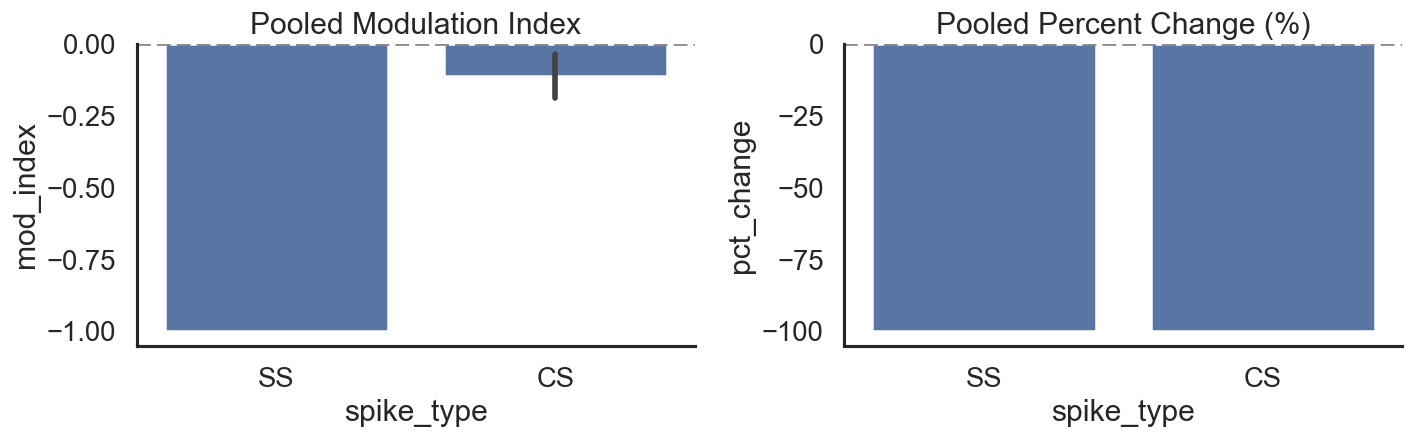

Pooled event-modulated spike likelihood (binary occurrence):


,spike_type,baseline_likelihood,response_likelihood,delta_likelihood
0,CS,0.111111,0.0,-0.111111
1,SS,1.000000,0.0,-1.000000


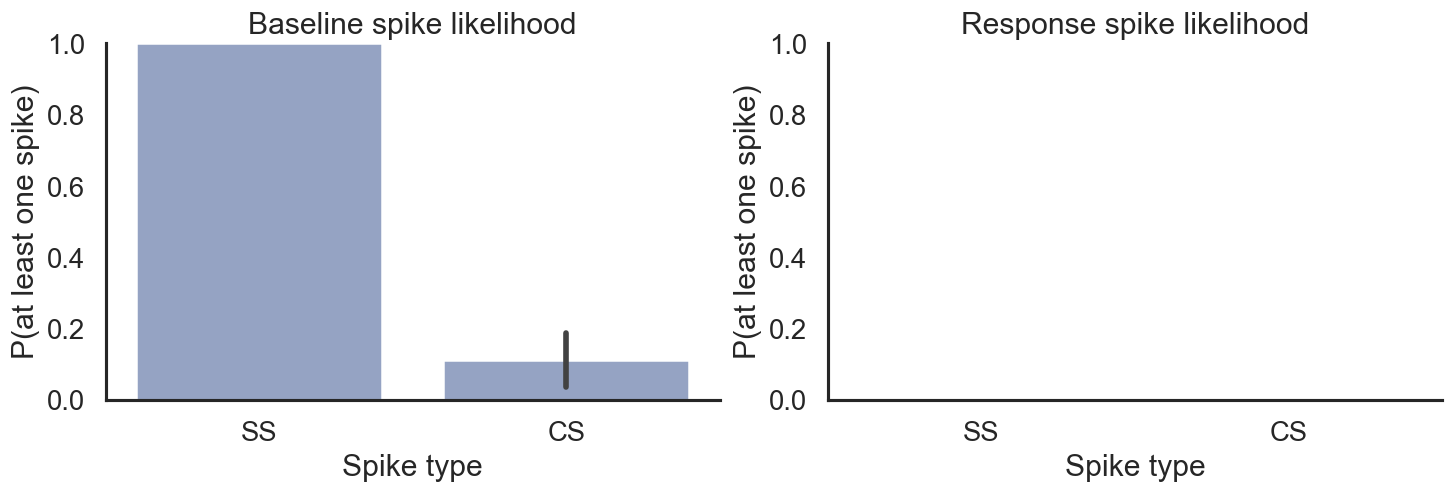

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


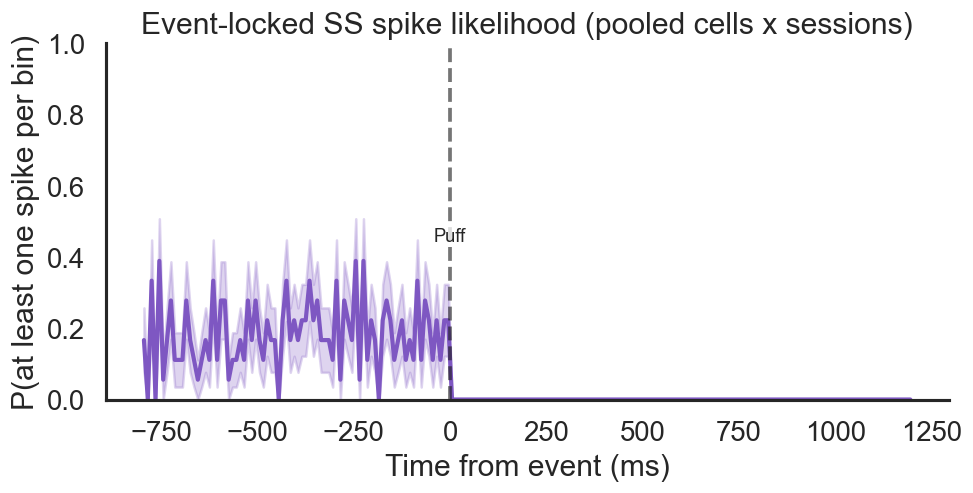

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


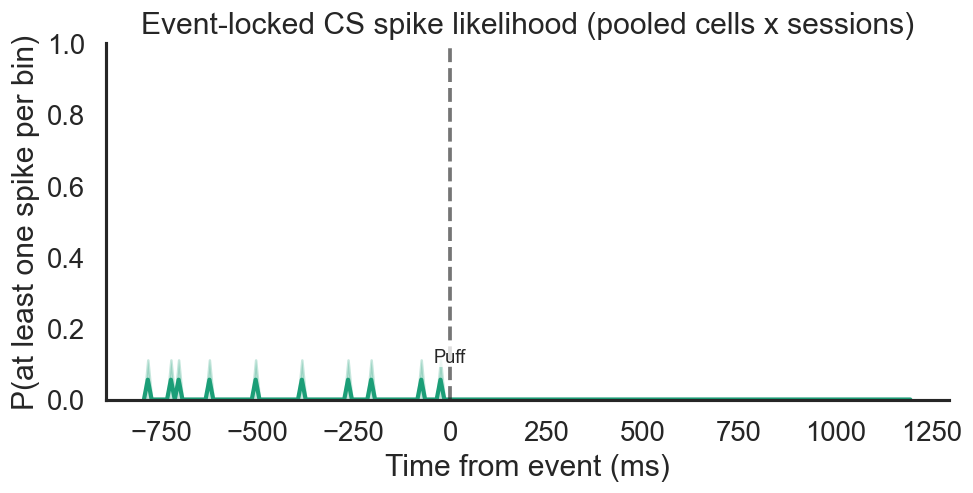

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


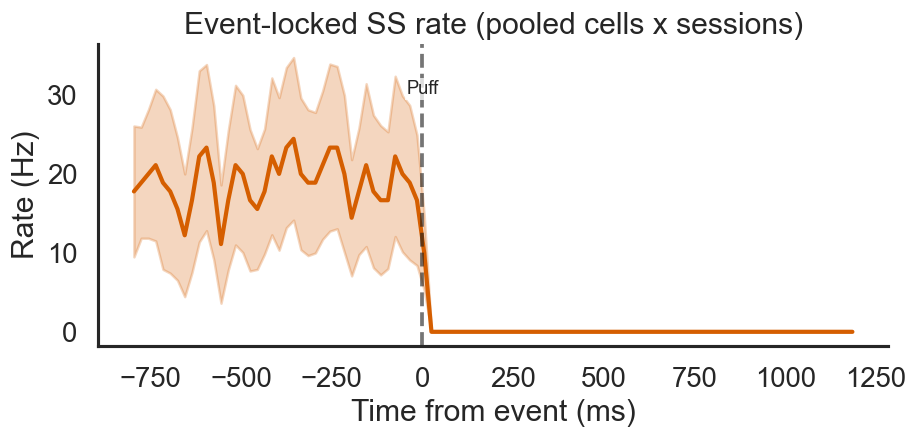

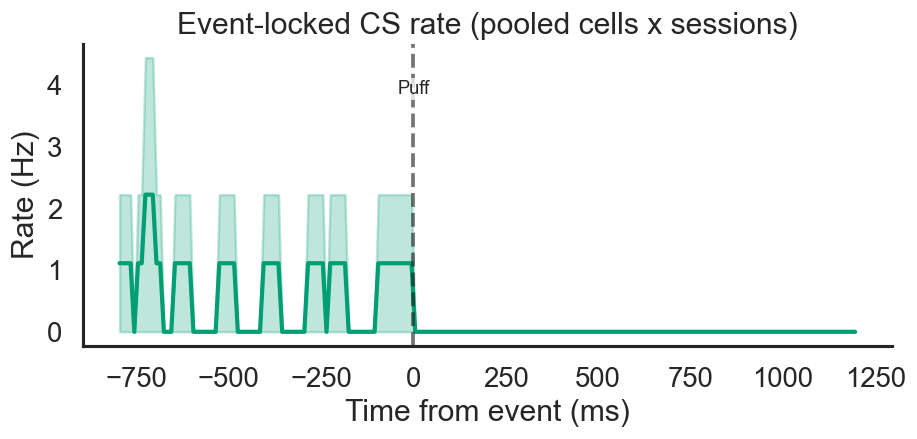


Per-cell pooled modulation summary:


,cell,spike_type,n_sessions,baseline_hz_mean,response_hz_mean,mod_index_mean,pct_change_mean
0,avr (UG)(),CS,9,0.888889,0.0,-0.222222,-100.0
1,avr (UG)(),SS,9,13.333333,0.0,-1.000000,-100.0
2,avr (UG)().1,CS,9,0.000000,0.0,0.000000,NaN
3,avr (UG)().1,SS,9,27.619048,0.0,-1.000000,-100.0



Per-cell SS event-locked rate curves:
[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


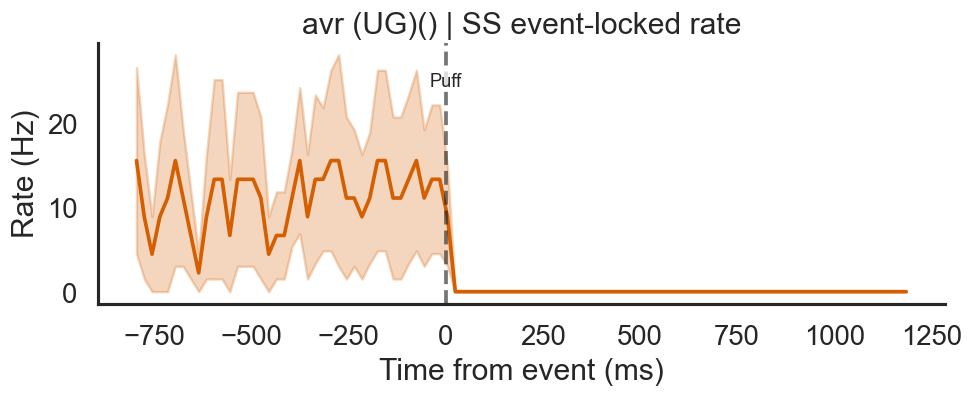

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


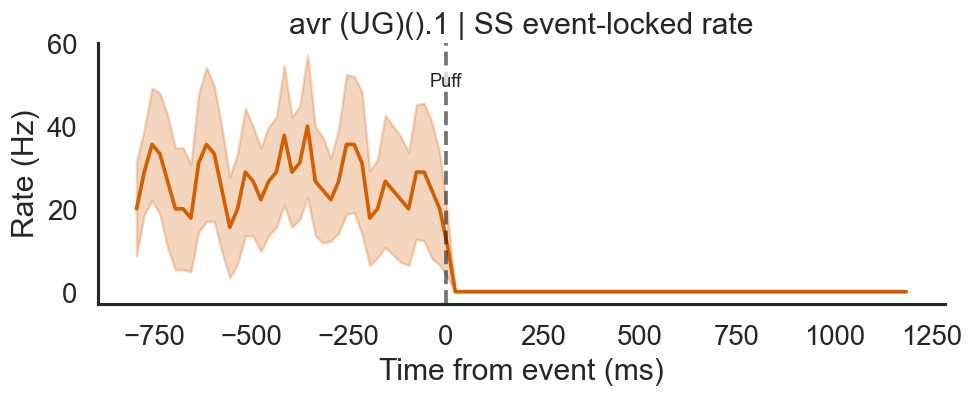

In [19]:
# Refresh pooled event modulation each run to avoid stale pooled curves after config/data changes.
event_df, pooled_event = run_event_modulation(sessions, EVENT_CONFIG)
if EVENT_LIKELIHOOD_CONFIG.get('enabled', True):
    event_likelihood_df = run_event_spike_likelihood(sessions, EVENT_CONFIG)
else:
    event_likelihood_df = pd.DataFrame()
plt.close('all')

def _smooth_curve(y, window=5):
    y = np.asarray(y, dtype=float)
    window = int(max(1, window))
    if window <= 1 or y.size < window:
        return y
    if window % 2 == 0:
        window += 1
    pad = window // 2
    kernel = np.ones(window, dtype=float) / float(window)
    ypad = np.pad(y, (pad, pad), mode='edge')
    return np.convolve(ypad, kernel, mode='valid')

# Per-session modulation summary
if not event_df.empty:
    session_mod = (event_df.groupby(['session', 'spike_type'], as_index=False)
                       .agg(mod_index_mean=('mod_index', 'mean'),
                            mod_index_sem=('mod_index', lambda x: np.std(x, ddof=1) / np.sqrt(max(len(x), 1))),
                            pct_change_mean=('pct_change', 'mean')))
    display_top(session_mod, label='Session modulation summary')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Modulation index bar plot
    mod_df = event_df.dropna(subset=['mod_index']).copy()
    if not mod_df.empty:
        sns.barplot(data=mod_df, x='spike_type', y='mod_index', order=['SS', 'CS'], errorbar='se', ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, 'No valid modulation index values', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].grid(False)
    axes[0].axhline(0, color='k', ls='--', alpha=0.5)
    axes[0].set_title('Pooled Modulation Index')

    # Percent-change bar plot
    pct_df = event_df.dropna(subset=['pct_change']).copy()
    if not pct_df.empty:
        sns.barplot(data=pct_df, x='spike_type', y='pct_change', order=['SS', 'CS'], errorbar='se', ax=axes[1])
    else:
        axes[1].text(0.5, 0.5, 'No valid percent-change values', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].grid(False)
    axes[1].axhline(0, color='k', ls='--', alpha=0.5)
    axes[1].set_title('Pooled Percent Change (%)')

    # Make missing categories explicit (e.g., CS can be all-NaN for pct_change).
    for ax, metric, title_name in [
        (axes[0], 'mod_index', 'Modulation index'),
        (axes[1], 'pct_change', 'Percent change')
    ]:
        valid_types = set(event_df.loc[event_df[metric].notna(), 'spike_type'].unique().tolist())
        missing_types = [t for t in ['SS', 'CS'] if t not in valid_types]
        if missing_types:
            ax.text(0.98, 0.98,
                    f"{title_name} unavailable for: {', '.join(missing_types)}",
                    ha='right', va='top', fontsize=10, transform=ax.transAxes)

    plt.tight_layout()
    _save_fig_svg(fig, 'pooled_modulation_index_pct_change')
    plt.show()

# Event-modulated spike likelihood summary/plot (binary occurrence in configured windows).
if not event_likelihood_df.empty:
    like_summary = (event_likelihood_df.groupby('spike_type', as_index=False)
                    .agg(baseline_likelihood=('baseline_likelihood', 'mean'),
                         response_likelihood=('response_likelihood', 'mean'),
                         delta_likelihood=('delta_likelihood', 'mean')))
    print('Pooled event-modulated spike likelihood (binary occurrence):')
    display_top(like_summary, label='Likelihood summary')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    sns.barplot(data=event_likelihood_df, x='spike_type', y='baseline_likelihood', order=['SS', 'CS'], errorbar='se', ax=axes[0], color='#8DA0CB')
    sns.barplot(data=event_likelihood_df, x='spike_type', y='response_likelihood', order=['SS', 'CS'], errorbar='se', ax=axes[1], color='#66C2A5')
    for ax, ttl in zip(axes, ['Baseline spike likelihood', 'Response spike likelihood']):
        ax.grid(False)
        ax.set_ylim(0, 1.0)
        ax.set_xlabel('Spike type')
        ax.set_ylabel('P(at least one spike)')
        ax.set_title(ttl)
    _save_fig_svg(fig, 'spike_likelihood_baseline_response')
    plt.show()

# Continuous event-locked spike likelihood curves (analogous to event-locked rate curves).
for stype in ['SS', 'CS']:
    if stype == 'SS':
        bin_ms = EVENT_CONFIG['ss_bin_ms']
        w = EVENT_CONFIG['ss_window_ms']
        c = '#7E57C2'
        spikes_accessor = 'spike_times_ss'
    else:
        bin_ms = EVENT_CONFIG['cs_bin_ms']
        w = EVENT_CONFIG['cs_window_ms']
        c = '#1B9E77'
        spikes_accessor = 'spike_times_cs'

    likelihood_rows = []
    event_cache = {}
    for i in range(len(cell_names)):
        for s in sessions:
            event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
            for event_time_ms in event_times_ms:
                _, lk = event_locked_bin_likelihood(
                    s[spikes_accessor][i],
                    event_time_ms,
                    w,
                    bin_ms,
                )
                likelihood_rows.append(lk)

    if len(likelihood_rows) == 0:
        continue
    lk_arr = np.asarray(likelihood_rows, dtype=float)
    lk_mean = np.nanmean(lk_arr, axis=0)
    lk_sem = np.nanstd(lk_arr, axis=0, ddof=1) / np.sqrt(lk_arr.shape[0]) if lk_arr.shape[0] > 1 else np.zeros_like(lk_mean)
    x = np.arange(w[0], w[1], bin_ms) + bin_ms / 2

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.grid(False)
    ax.plot(x, lk_mean, color=c, lw=2.5)
    ax.fill_between(x, np.clip(lk_mean - lk_sem, 0, 1), np.clip(lk_mean + lk_sem, 0, 1), color=c, alpha=0.25)
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ymin, ymax = ax.get_ylim()
    y_txt = ymin + 0.82 * (ymax - ymin)
    ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
    if np.allclose(lk_mean, 0.0):
        ax.text(0.98, 0.96, f'No {stype} spikes in configured event window',
                ha='right', va='top', fontsize=10, transform=ax.transAxes)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'Event-locked {stype} spike likelihood (pooled cells x sessions)')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('P(at least one spike per bin)')
    _save_fig_svg(fig, f'event_locked_{stype}_likelihood')
    plt.show()

# PETH pooled curves
# Use configured SS window directly (no extra zoom expansion).
ss_display_window = EVENT_CONFIG['ss_window_ms']
ss_point_stride = 2

cs_nonzero = False
for stype in ['SS', 'CS']:
    if stype == 'SS':
        bin_ms = EVENT_CONFIG['ss_bin_ms']
        w = ss_display_window
        c = '#D55E00'

        # Recompute pooled SS rates using the configured display window.
        ss_rates = []
        event_cache = {}
        for i in range(len(cell_names)):
            for s in sessions:
                event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
                for event_time_ms in event_times_ms:
                    _, rate, _ = event_locked_hist(
                        s['spike_times_ss'][i],
                        event_time_ms,
                        w,
                        bin_ms,
                    )
                    ss_rates.append(rate)
        if len(ss_rates) == 0:
            continue
        arr = np.asarray(ss_rates, dtype=float)
    else:
        if len(pooled_event[stype]) == 0:
            continue
        arr = np.asarray(pooled_event[stype], dtype=float)
        bin_ms = EVENT_CONFIG['cs_bin_ms']
        w = EVENT_CONFIG['cs_window_ms']
        c = '#009E73'

    mean_curve = np.nanmean(arr, axis=0)
    sem_curve = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean_curve)

    if stype == 'CS':
        cs_nonzero = bool(np.any(mean_curve > 0))

    x = np.arange(w[0], w[1], bin_ms) + bin_ms / 2

    # Smooth curves; for SS also downsample plotted points to 2x sparser.
    mean_plot = _smooth_curve(mean_curve, window=5)
    sem_plot = _smooth_curve(sem_curve, window=5)
    x_plot = x
    if stype == 'SS':
        x_plot = x_plot[::ss_point_stride]
        mean_plot = mean_plot[::ss_point_stride]
        sem_plot = sem_plot[::ss_point_stride]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.grid(False)
    ax.plot(x_plot, mean_plot, color=c, lw=2.5)
    ax.fill_between(x_plot, mean_plot - sem_plot, mean_plot + sem_plot, color=c, alpha=0.25)
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ymin, ymax = ax.get_ylim()
    y_txt = ymin + 0.82 * (ymax - ymin)
    ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
    if np.allclose(mean_curve, 0.0):
        ax.text(0.98, 0.96, f'No {stype} spikes in configured event window',
                ha='right', va='top', fontsize=10, transform=ax.transAxes)
    ax.set_title(f'Event-locked {stype} rate (pooled cells x sessions)')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('Rate (Hz)')
    plt.tight_layout()
    _save_fig_svg(fig, f'event_locked_{stype}_rate')
    plt.show()

if not cs_nonzero:
    print('CS is absent or near-absent in the current event windows; showing detailed SS modulation per cell below.')

# Per-cell modulation summary table (across sessions) - bar plots removed per request
cell_mod = (event_df.groupby(['cell', 'spike_type'], as_index=False)
            .agg(n_sessions=('session', 'nunique'),
                 baseline_hz_mean=('baseline_hz', 'mean'),
                 response_hz_mean=('response_hz', 'mean'),
                 mod_index_mean=('mod_index', 'mean'),
                 pct_change_mean=('pct_change', 'mean')))
print('\nPer-cell pooled modulation summary:')
display_top(cell_mod, label='Cell modulation summary')

# Per-cell SS event-locked rate curves
print('\nPer-cell SS event-locked rate curves:')
for i, cname in enumerate(cell_names):
    ss_rates = []
    event_cache = {}
    for s in sessions:
        event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=event_cache)
        for event_time_ms in event_times_ms:
            _, rate, _ = event_locked_hist(
                s['spike_times_ss'][i],
                event_time_ms,
                ss_display_window,
                EVENT_CONFIG['ss_bin_ms']
            )
            ss_rates.append(rate)

    arr = np.asarray(ss_rates, dtype=float)
    mean_curve = np.nanmean(arr, axis=0)
    sem_curve = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean_curve)
    w = ss_display_window
    bin_ms = EVENT_CONFIG['ss_bin_ms']
    x = np.arange(w[0], w[1], bin_ms) + bin_ms / 2

    mean_plot = _smooth_curve(mean_curve, window=5)[::ss_point_stride]
    sem_plot = _smooth_curve(sem_curve, window=5)[::ss_point_stride]
    x_plot = x[::ss_point_stride]

    fig, ax = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
    ax.grid(False)
    ax.plot(x_plot, mean_plot, color='#D55E00', lw=2.2)
    ax.fill_between(x_plot, mean_plot - sem_plot, mean_plot + sem_plot, color='#D55E00', alpha=0.25)
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ymin, ymax = ax.get_ylim()
    y_txt = ymin + 0.82 * (ymax - ymin)
    ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
    ax.set_title(f'{cname} | SS event-locked rate')
    ax.set_xlabel('Time from event (ms)')
    ax.set_ylabel('Rate (Hz)')
    _save_fig_svg(fig, f'per_cell_SS_rate_{cname}')
    plt.show()


Per-pair event-locked synchrony curves (metric-aware override):
[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


/var/folders/cp/q8802h992_371mtbyj83fz1h0000gn/T/ipykernel_42579/3123542443.py:68: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(arr, axis=0)


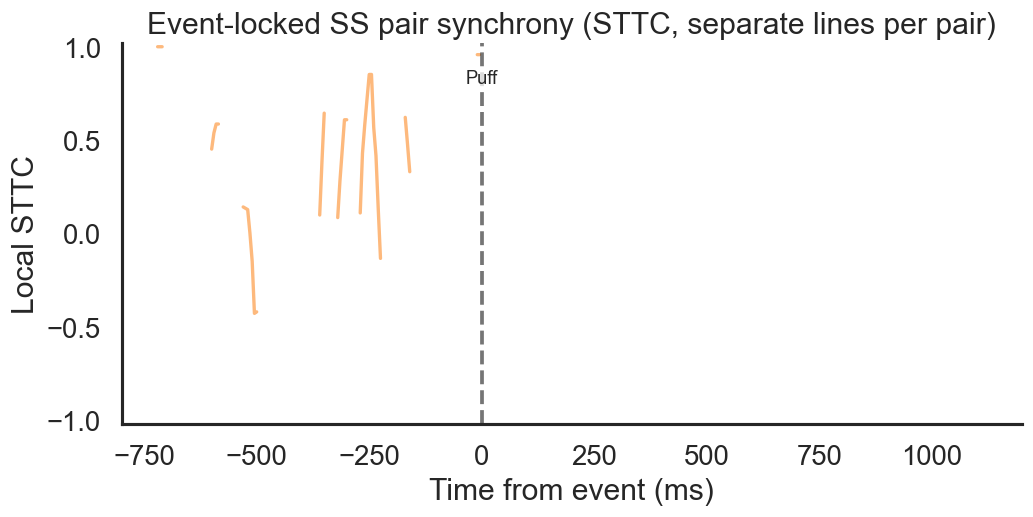

[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event found; using fallback 10000.000 ms


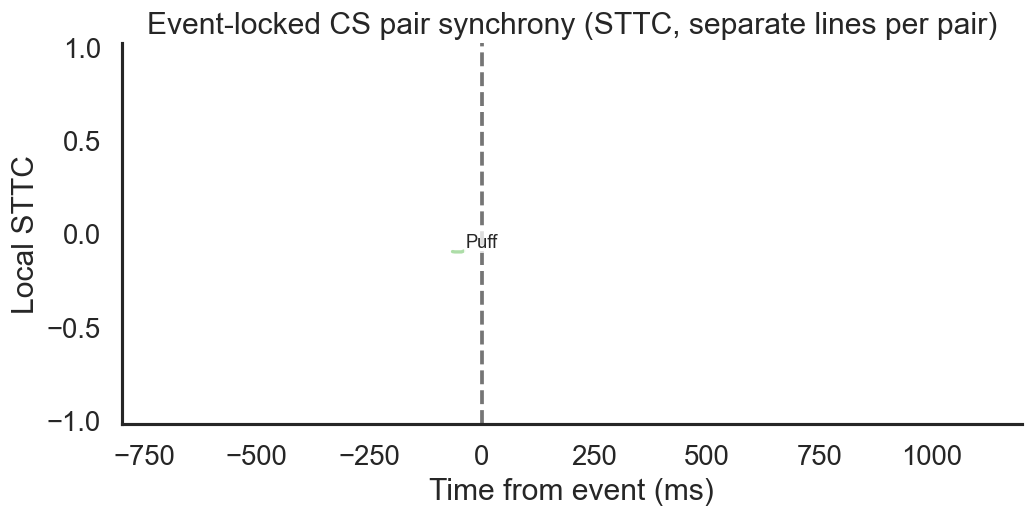

In [20]:
# Metric-aware event-locked pair synchrony curves (overrides Pearson-only version when sync_metric='sttc').
def event_locked_pair_sync_curve_metric(times_a, times_b, event_time_ms, window_ms, bin_ms, sync_window_ms, cfg=None):
    w0, w1 = float(window_ms[0]), float(window_ms[1])
    centers = np.arange(w0, w1 + bin_ms, bin_ms)
    if centers.size < 3:
        return np.array([], dtype=float), np.array([], dtype=float)

    curve = np.full(centers.shape, np.nan, dtype=float)
    half_w = 0.5 * float(sync_window_ms)
    for k, c in enumerate(centers):
        seg = (float(c) - half_w, float(c) + half_w)
        t0 = event_time_ms + seg[0]
        t1 = event_time_ms + seg[1]
        if t1 <= t0:
            continue
        v = pair_sync_metric(times_a, times_b, t0, t1, bin_ms, cfg=cfg)
        curve[k] = v if np.isfinite(v) else np.nan
    return centers, curve

print('\nPer-pair event-locked synchrony curves (metric-aware override):')
if n_cells < 2:
    print('Single-cell dataset detected (n_cells=1). Skipping metric-aware pair curves.')
else:
    for stype in ['SS', 'CS']:
        if stype == 'SS':
            spikes_key = 'spike_times_ss'
            bin_ms = float(EVENT_CONFIG['ss_sync_bin_ms'])
            w = EVENT_CONFIG['ss_window_ms']
            color_map = plt.cm.Oranges
        else:
            spikes_key = 'spike_times_cs'
            bin_ms = float(EVENT_CONFIG['cs_sync_bin_ms'])
            w = EVENT_CONFIG['cs_window_ms']
            color_map = plt.cm.Greens

        sync_window_ms = float(EVENT_CONFIG.get(
            f'{stype.lower()}_sync_curve_window_ms',
            20.0 if stype == 'SS' else 100.0
        ))

        pair_curves = {}
        x_ref = None
        for i, j in combinations(range(n_cells), 2):
            curves = []
            _event_cache_sync_curve = {}
            for s in sessions:
                event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache_sync_curve)
                for event_time_ms in event_times_ms:
                    x, y = event_locked_pair_sync_curve_metric(
                        s[spikes_key][i],
                        s[spikes_key][j],
                        event_time_ms,
                        w,
                        bin_ms,
                        sync_window_ms,
                        cfg=SYNC_CONFIG,
                    )
                    if y.size == 0 or np.all(np.isnan(y)):
                        continue
                    curves.append(y)
                    if x_ref is None:
                        x_ref = x

            if len(curves) == 0:
                continue

            arr = np.asarray(curves, dtype=float)
            mean_curve = np.nanmean(arr, axis=0)
            if np.all(np.isnan(mean_curve)):
                continue
            pair_curves[(i, j)] = _smooth_curve(mean_curve, window=5)

        fig, ax = plt.subplots(figsize=(8.5, 4.2), constrained_layout=True)
        ax.grid(False)

        if not pair_curves or x_ref is None:
            ax.text(0.5, 0.5, f'No valid {stype} pair synchrony curves', ha='center', va='center', transform=ax.transAxes)
            ax.axvline(0, color='k', ls='--', alpha=0.6)
            ax.set_xlim(float(w[0]), float(w[1]))
            ax.set_ylim(-1.02, 1.02)
            ax.set_title(f'Event-locked {stype} pair synchrony')
            ax.set_xlabel('Time from event (ms)')
            ax.set_ylabel(f'Local {_metric_name_from_cfg(SYNC_CONFIG).upper()}')
            _save_fig_svg(fig, f'event_locked_{stype}_pair_sync_metric_override_empty')
            plt.show()
            continue

        pair_keys = sorted(pair_curves.keys())
        colors = color_map(np.linspace(0.35, 0.9, len(pair_keys)))
        for c_idx, (i, j) in enumerate(pair_keys):
            label = f'{cell_names[i]} vs {cell_names[j]}'
            ax.plot(x_ref, pair_curves[(i, j)], lw=2.0, color=colors[c_idx], alpha=0.95, label=label)

        ax.axvline(0, color='k', ls='--', alpha=0.6)
        ymin, ymax = ax.get_ylim()
        y_txt = ymin + 0.82 * (ymax - ymin)
        ax.text(0.0, y_txt, 'Puff', ha='center', va='bottom', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.0))
        ax.set_xlim(float(w[0]), float(w[1]))
        ax.set_ylim(-1.02, 1.02)
        ax.set_title(f'Event-locked {stype} pair synchrony ({_metric_name_from_cfg(SYNC_CONFIG).upper()}, separate lines per pair)')
        ax.set_xlabel('Time from event (ms)')
        ax.set_ylabel(f'Local {_metric_name_from_cfg(SYNC_CONFIG).upper()}')

        _save_fig_svg(fig, f'event_locked_{stype}_pair_sync_metric_override')
        plt.show()

In [21]:
# Pair-level jitter-null with BH-FDR (primary metric = direct windowed synchrony metric)
# Configurable significance tail mode:
#   'adaptive-one-sided' (recommended): uses right-tail for delta >= 0, left-tail for delta < 0
#   'right', 'left', or 'two-sided'.


def _resolve_tail_mode():
    cfg = globals().get('SIGNIFICANCE_TEST_CONFIG', {})
    raw = str(cfg.get('tail', 'adaptive-one-sided')).strip().lower()
    if raw in {'adaptive-one-sided', 'adaptive_one_sided', 'adaptive', 'one-sided-adaptive'}:
        return 'adaptive-one-sided'
    if raw in {'right', 'right-sided', 'right_sided'}:
        return 'right'
    if raw in {'left', 'left-sided', 'left_sided'}:
        return 'left'
    if raw in {'two-sided', 'two_sided', 'two sided', 'two', 'both'}:
        return 'two-sided'
    return 'adaptive-one-sided'


def _active_p_info(tail_mode):
    if tail_mode == 'left':
        return 'p_left', 'P(null <= observed)'
    if tail_mode == 'two-sided':
        return 'p_two_sided', 'min(1, 2 * min(p_left, p_right))'
    if tail_mode == 'adaptive-one-sided':
        return 'p_adaptive', 'if delta>=0 use p_right else p_left'
    return 'p_right', 'P(null >= observed)'


def _bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    if n == 0:
        return np.array([], dtype=float)
    order = np.argsort(p)
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(1, n + 1, dtype=float)
    q = p * n / ranks
    q_sorted = q[order].copy()
    for k in range(n - 2, -1, -1):
        if q_sorted[k] > q_sorted[k + 1]:
            q_sorted[k] = q_sorted[k + 1]
    q[order] = q_sorted
    return np.clip(q, 0.0, 1.0)


def _window_union(*windows):
    return (min(float(w[0]) for w in windows), max(float(w[1]) for w in windows))


def _jitter_within_window(times, event_time_ms, window_ms, jitter_ms, rng_obj):
    t = np.asarray(times, dtype=float)
    if t.size == 0:
        return t
    lo = float(event_time_ms) + float(window_ms[0])
    hi = float(event_time_ms) + float(window_ms[1])
    in_win = (t >= lo) & (t <= hi)
    if not np.any(in_win):
        return np.sort(t.copy())
    out = t.copy()
    out[in_win] = out[in_win] + rng_obj.uniform(-jitter_ms, jitter_ms, size=int(in_win.sum()))
    out[in_win] = np.clip(out[in_win], lo, hi)
    return np.sort(out)


def _windowed_pair_metric(times_a, times_b, event_time_ms, window_rel_ms, bin_ms, cfg=None):
    cfg = cfg or SYNC_CONFIG
    if 'windowed_pair_sync_metric' in globals():
        return windowed_pair_sync_metric(times_a, times_b, event_time_ms, window_rel_ms, bin_ms, cfg=cfg)
    w0, w1 = window_rel_ms
    t0 = event_time_ms + float(w0)
    t1 = event_time_ms + float(w1)
    if t1 <= t0:
        return np.nan
    return pair_sync_metric(times_a, times_b, t0, t1, bin_ms, cfg=cfg)


def _delta_metric_direct(times_a, times_b, event_time_ms, baseline_w, response_w, bin_ms, cfg=None):
    cfg = cfg or SYNC_CONFIG
    v_base = _windowed_pair_metric(times_a, times_b, event_time_ms, baseline_w, bin_ms, cfg=cfg)
    v_resp = _windowed_pair_metric(times_a, times_b, event_time_ms, response_w, bin_ms, cfg=cfg)
    if np.isfinite(v_base) and np.isfinite(v_resp):
        return float(v_resp - v_base)
    return np.nan


metric_name = _metric_name_from_cfg(SYNC_CONFIG).upper()
tail_mode = _resolve_tail_mode()
active_p_col, active_p_desc = _active_p_info(tail_mode)

print(f'── Pair-level jitter-null with BH-FDR (direct windowed {metric_name}) ──\n')
print(
    f"Tail mode: {tail_mode} | active p column: {active_p_col} ({active_p_desc})\n"
    f"q_bh_fdr is BH-corrected from p_selected within each spike type."
)

if n_cells < 2:
    print('Single-cell dataset. Skipping pair-level jitter-null.')
    pair_fdr_df = pd.DataFrame()
else:
    pair_rows = []

    for stype in ['SS', 'CS']:
        if stype == 'SS':
            spikes_key = 'spike_times_ss'
            inspect_w = EVENT_CONFIG['ss_window_ms']
            baseline_w = EVENT_CONFIG['ss_sync_baseline_ms']
            response_w = EVENT_CONFIG['ss_sync_response_ms']
            bin_ms = float(EVENT_CONFIG['ss_sync_bin_ms'])
            jitter_ms = float(SIGNIFICANCE_TEST_CONFIG.get('ss_jitter_ms', 25.0))
        else:
            spikes_key = 'spike_times_cs'
            inspect_w = EVENT_CONFIG['cs_window_ms']
            baseline_w = EVENT_CONFIG['cs_sync_baseline_ms']
            response_w = EVENT_CONFIG['cs_sync_response_ms']
            bin_ms = float(EVENT_CONFIG['cs_sync_bin_ms'])
            jitter_ms = float(SIGNIFICANCE_TEST_CONFIG.get('cs_jitter_ms', 600.0))

        analysis_w = _window_union(inspect_w, baseline_w, response_w)
        n_null = int(SIGNIFICANCE_TEST_CONFIG.get('n_null_shuffles', 1000))
        rng_pair = np.random.default_rng(int(SIGNIFICANCE_TEST_CONFIG.get('seed', 123)))

        print(f"{stype}: inspect={inspect_w}, baseline={baseline_w}, response={response_w}, jitter_window={analysis_w}")

        for i, j in combinations(range(n_cells), 2):
            observed_vals = []
            _event_cache_obs = {}
            for s in sessions:
                event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache_obs)
                for event_time_ms in event_times_ms:
                    d_obs = _delta_metric_direct(
                        s[spikes_key][i],
                        s[spikes_key][j],
                        event_time_ms,
                        baseline_w,
                        response_w,
                        bin_ms,
                        cfg=SYNC_CONFIG,
                    )
                    if np.isfinite(d_obs):
                        observed_vals.append(d_obs)

            if len(observed_vals) == 0:
                continue

            obs_mean = float(np.mean(observed_vals))

            null_means = []
            _event_cache_null = {}
            for _ in range(n_null):
                null_vals = []
                for s in sessions:
                    event_times_ms = _get_session_event_times_ms(s, EVENT_CONFIG, cache=_event_cache_null)
                    for event_time_ms in event_times_ms:
                        ta = _jitter_within_window(s[spikes_key][i], event_time_ms, analysis_w, jitter_ms, rng_pair)
                        tb = _jitter_within_window(s[spikes_key][j], event_time_ms, analysis_w, jitter_ms, rng_pair)
                        d_null = _delta_metric_direct(
                            ta,
                            tb,
                            event_time_ms,
                            baseline_w,
                            response_w,
                            bin_ms,
                            cfg=SYNC_CONFIG,
                        )
                        if np.isfinite(d_null):
                            null_vals.append(d_null)

                if null_vals:
                    null_means.append(float(np.mean(null_vals)))

            if len(null_means) < 10:
                continue

            null_arr = np.asarray(null_means, dtype=float)
            null_mu = float(np.mean(null_arr))
            null_sd = float(np.std(null_arr, ddof=1)) + 1e-12
            p_right = float((np.sum(null_arr >= obs_mean) + 1) / (len(null_arr) + 1))
            p_left = float((np.sum(null_arr <= obs_mean) + 1) / (len(null_arr) + 1))
            p_two = float(min(1.0, 2.0 * min(p_left, p_right)))

            if tail_mode == 'adaptive-one-sided':
                p_selected = p_right if obs_mean >= 0 else p_left
                p_selected_label = 'p_right' if obs_mean >= 0 else 'p_left'
            elif tail_mode == 'left':
                p_selected = p_left
                p_selected_label = 'p_left'
            elif tail_mode == 'two-sided':
                p_selected = p_two
                p_selected_label = 'p_two_sided'
            else:
                p_selected = p_right
                p_selected_label = 'p_right'

            z_like = float((obs_mean - null_mu) / null_sd)
            ci_lo, ci_hi = np.percentile(null_arr, [2.5, 97.5])

            pair_rows.append({
                'metric_method': f'direct_windowed_{_metric_name_from_cfg(SYNC_CONFIG)}',
                'spike_type': stype,
                'cell_i': i,
                'cell_j': j,
                'n_sessions': len(observed_vals),
                'n_null_shuffles': len(null_means),
                'delta_r_obs': round(obs_mean, 6),
                'delta_r_null_mean': round(null_mu, 6),
                'p_right': round(p_right, 6),
                'p_left': round(p_left, 6),
                'p_two_sided': round(p_two, 6),
                'p_selected': round(float(p_selected), 6),
                'p_selected_label': p_selected_label,
                'z_like': round(z_like, 4),
                'null_ci_lo': round(float(ci_lo), 6),
                'null_ci_hi': round(float(ci_hi), 6),
            })

    if pair_rows:
        pair_fdr_df = pd.DataFrame(pair_rows)
        pair_fdr_df['tail_mode'] = tail_mode

        for st in pair_fdr_df['spike_type'].unique():
            mask = pair_fdr_df['spike_type'] == st
            pair_fdr_df.loc[mask, 'q_bh_fdr'] = _bh_fdr(pair_fdr_df.loc[mask, 'p_selected'].values)
        pair_fdr_df['q_bh_fdr'] = pair_fdr_df['q_bh_fdr'].round(6)

        print(f"\nDirect-method FDR summary by spike type ({tail_mode}, metric={metric_name}):")
        for st in pair_fdr_df['spike_type'].unique():
            sub = pair_fdr_df[pair_fdr_df['spike_type'] == st]
            n_sig_05 = int((sub['q_bh_fdr'] <= 0.05).sum())
            n_sig_10 = int((sub['q_bh_fdr'] <= 0.10).sum())
            print(
                f"  {st}: {len(sub)} pairs tested | q<=0.05: {n_sig_05} | q<=0.10: {n_sig_10} | "
                f"min p_selected: {_format_pq_value(sub['p_selected'].min(), 'p')} | max |delta|: {sub['delta_r_obs'].abs().max():.4f}"
            )

        display_top(pair_fdr_df, label='Pair-level jitter-null/FDR results', sort_by='q_bh_fdr', ascending=True)

        if EXPORT_RESULTS:
            fdr_path = os.path.join(EXPORT_DIR, 'pair_jitter_null_fdr.csv')
            pair_fdr_df.to_csv(fdr_path, index=False)
            print(f'Saved: {fdr_path}')
    else:
        pair_fdr_df = pd.DataFrame()
        print('No valid pairs survived jitter-null testing.')

── Pair-level jitter-null with BH-FDR (direct windowed STTC) ──

Tail mode: two-sided | active p column: p_two_sided (min(1, 2 * min(p_left, p_right)))
q_bh_fdr is BH-corrected from p_selected within each spike type.
SS: inspect=(-800.0, 1200.0), baseline=(-300.0, -20.0), response=(20.0, 300.0), jitter_window=(-800.0, 1200.0)
[event-detect] pair_10: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_11: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_13: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_14: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_15: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_4: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_5: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_7: no valid auto event found; using fallback 10000.000 ms
[event-detect] pair_8: no valid auto event 

In [22]:
# Compact summary (text-only) for pair-level jitter-null + BH-FDR results

if 'pair_fdr_df' not in globals() or pair_fdr_df.empty:
    print('pair_fdr_df is missing or empty. Run the pair-level FDR cell first.')
else:
    df = pair_fdr_df.copy()

    for col in ['delta_r_obs', 'delta_r_null_mean', 'p_left', 'p_right', 'p_two_sided', 'p_selected', 'q_bh_fdr', 'z_like']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    tail_mode = str(df['tail_mode'].iloc[0]) if 'tail_mode' in df.columns and len(df) else 'right'
    p_label = str(df['p_selected_label'].iloc[0]) if 'p_selected_label' in df.columns and len(df) else 'p_selected'

    if 'p_selected' not in df.columns:
        fallback_col = 'p_right' if tail_mode == 'right' else ('p_left' if tail_mode == 'left' else 'p_two_sided')
        if fallback_col in df.columns:
            df['p_selected'] = pd.to_numeric(df[fallback_col], errors='coerce')
            p_label = fallback_col

    cfg = globals().get('SIGNIFICANCE_REPORT_CONFIG', {})
    metric_raw = str(cfg.get('metric', 'p')).strip().lower()
    alpha = float(cfg.get('alpha', 0.05))
    if not np.isfinite(alpha):
        alpha = 0.05
    alpha = max(0.0, min(alpha, 1.0))

    if metric_raw in {'q', 'fdr', 'bh', 'q_bh_fdr'}:
        sig_col = 'q_bh_fdr'
        sig_label = 'q_bh_fdr'
    else:
        sig_col = 'p_selected'
        sig_label = p_label

    if sig_col not in df.columns:
        sig_col = 'q_bh_fdr'
        sig_label = 'q_bh_fdr'

    print(
        f'Pair-level significance summary (text only, tail mode={tail_mode}, '
        f'p={p_label}, report_metric={sig_label}, alpha={alpha:g}):'
    )
    for st in sorted(df['spike_type'].dropna().unique().tolist()):
        sub = df[df['spike_type'] == st].copy().sort_values([sig_col, 'cell_i', 'cell_j'])
        print(f"\n[{st}] n_pairs={len(sub)}")
        print(f"  {sig_label}<={alpha:g}: {(sub[sig_col] <= alpha).sum()}")
        print(f"  top 5 smallest {sig_label} values:")

        show_cols = [
            'cell_i', 'cell_j', 'n_sessions', 'delta_r_obs', 'delta_r_null_mean',
            'p_selected', 'q_bh_fdr', sig_col, 'z_like', 'null_ci_lo', 'null_ci_hi'
        ]
        show_cols = [c for c in show_cols if c in sub.columns]

        # Remove any duplicate column names in display list while preserving order.
        dedup_cols = []
        for c in show_cols:
            if c not in dedup_cols:
                dedup_cols.append(c)

        print(sub[dedup_cols].head(5).to_string(index=False))

    print('\nPAIR_LEVEL_FDR_TEXT_SUMMARY_DONE')

pair_fdr_df is missing or empty. Run the pair-level FDR cell first.


In [23]:
def _matrix_text_color(val, threshold=None):

    try:

        v = float(val)

    except Exception:

        return 'black'

    if not np.isfinite(v):

        return '#6B7280'

    if threshold is None:

        cfg = globals().get('CORR_HEATMAP_SCALE', {})

        if bool(cfg.get('enabled', False)):

            lim = max(abs(float(cfg.get('vmin', -1.0))), abs(float(cfg.get('vmax', 1.0))))

            threshold = 0.55 * lim

        else:

            threshold = 0.55

    return 'white' if abs(v) >= float(threshold) else 'black'


def _resolve_sig_metric(p_label):
    cfg = globals().get('SIGNIFICANCE_REPORT_CONFIG', {})
    metric_raw = str(cfg.get('metric', 'p')).strip().lower()
    alpha = float(cfg.get('alpha', 0.05))
    if not np.isfinite(alpha):
        alpha = 0.05
    alpha = max(0.0, min(alpha, 1.0))

    if metric_raw in {'q', 'fdr', 'bh', 'q_bh_fdr'}:
        return 'q_bh_fdr', 'q_bh_fdr', alpha
    return 'p_selected', p_label, alpha


def _build_value_matrix_from_pooled(pooled_df, value_col):
    mat = np.full((n_cells, n_cells), np.nan, dtype=float)
    if pooled_df is None or pooled_df.empty:
        return mat
    for _, row in pooled_df.iterrows():
        ci = str(row['cell_i'])
        cj = str(row['cell_j'])
        if ci not in cell_names or cj not in cell_names:
            continue
        i = cell_names.index(ci)
        j = cell_names.index(cj)
        val = pd.to_numeric(row[value_col], errors='coerce')
        if np.isfinite(val):
            mat[i, j] = float(val)
            mat[j, i] = float(val)
    return mat


def _build_stat_mats_from_pair_fdr(sub):
    q_mat = np.full((n_cells, n_cells), np.nan, dtype=float)
    p_mat = np.full((n_cells, n_cells), np.nan, dtype=float)
    sig_mat = np.full((n_cells, n_cells), np.nan, dtype=float)

    if sub is None or sub.empty:
        return p_mat, q_mat, sig_mat

    tail_mode = str(sub['tail_mode'].iloc[0]) if 'tail_mode' in sub.columns and len(sub) else 'right'
    p_col = 'p_selected' if 'p_selected' in sub.columns else ('p_right' if tail_mode == 'right' else ('p_left' if tail_mode == 'left' else 'p_two_sided'))
    p_label = str(sub['p_selected_label'].iloc[0]) if 'p_selected_label' in sub.columns and len(sub) else p_col
    sig_col, _, _ = _resolve_sig_metric(p_label)
    if sig_col not in sub.columns:
        sig_col = 'q_bh_fdr'

    for _, row in sub.iterrows():
        i = int(row['cell_i'])
        j = int(row['cell_j'])
        p_val = pd.to_numeric(row[p_col], errors='coerce') if p_col in row.index else np.nan
        q_val = pd.to_numeric(row['q_bh_fdr'], errors='coerce') if 'q_bh_fdr' in row.index else np.nan
        s_val = pd.to_numeric(row[sig_col], errors='coerce') if sig_col in row.index else np.nan
        p_mat[i, j] = p_mat[j, i] = p_val
        q_mat[i, j] = q_mat[j, i] = q_val
        sig_mat[i, j] = sig_mat[j, i] = s_val

    return p_mat, q_mat, sig_mat


def _p_value_stars(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return ''


def _overlay_text(ax, value_mat, p_mat, q_mat, sig_mat, sig_alpha, show_on_plot, is_delta_panel):
    style = globals().get('CORR_MATRIX_STYLE', {})
    value_fs = float(style.get('value_fontsize', 10))
    stat_fs = float(style.get('stat_fontsize', 7))
    value_weight = style.get('value_fontweight', 'bold')
    for ci in range(n_cells):
        for cj in range(n_cells):
            x = cj + 0.5
            y = ci + 0.5

            if ci == cj:
                ax.text(x, y, '-', ha='center', va='center', fontsize=11, color='#6B7280')
                continue

            val = value_mat[ci, cj]
            if not np.isfinite(val):
                ax.text(x, y, 'n/a', ha='center', va='center', fontsize=8, color='#6B7280')
                continue

            pv = p_mat[ci, cj] if is_delta_panel else np.nan
            qv = q_mat[ci, cj] if is_delta_panel else np.nan
            stars = _p_value_stars(pv)

            if show_on_plot and is_delta_panel:
                txt_color = _matrix_text_color(val)
                ax.text(x, y - 0.10, f'{val:+.2f}{stars}', ha='center', va='center', fontsize=value_fs, fontweight=value_weight, color=txt_color)
                p_text = _format_pq_value(pv, 'p')
                ax.text(x, y + 0.08, p_text, ha='center', va='center', fontsize=stat_fs, color=txt_color)
                if np.isfinite(qv):
                    ax.text(x, y + 0.22, _format_pq_value(qv, 'q'), ha='center', va='center', fontsize=stat_fs, color=txt_color)
            else:
                suffix = stars if is_delta_panel else ''
                txt_color = _matrix_text_color(val)
                ax.text(x, y, f'{val:+.2f}{suffix}', ha='center', va='center', fontsize=value_fs, fontweight=value_weight, color=txt_color)


def _plot_sync_change_matrix_from_pair_fdr(pair_df, pooled_df):
    if pair_df is None or pair_df.empty:
        print('pair_fdr_df is missing or empty. Run the pair-level FDR cell first.')
        return
    if pooled_df is None or pooled_df.empty:
        print('pooled_pair_event is missing or empty. Run the metric-aware event pair synchrony cell first.')
        return

    show_on_plot = bool(globals().get('SIGNIFICANCE_REPORT_CONFIG', {}).get('show_on_plot', True))
    metric_name = _metric_name_from_cfg(SYNC_CONFIG).upper()

    for stype in sorted(pair_df['spike_type'].unique()):
        sig_sub = pair_df[pair_df['spike_type'] == stype].copy()
        pooled_sub = pooled_df[pooled_df['spike_type'] == stype].copy()
        if pooled_sub.empty:
            print(f'{stype}: pooled_pair_event has no rows.')
            continue

        tail_mode = str(sig_sub['tail_mode'].iloc[0]) if 'tail_mode' in sig_sub.columns and len(sig_sub) else 'right'
        p_label = str(sig_sub['p_selected_label'].iloc[0]) if 'p_selected_label' in sig_sub.columns and len(sig_sub) else 'p_selected'
        sig_col, sig_label, sig_alpha = _resolve_sig_metric(p_label)
        if sig_col not in sig_sub.columns:
            sig_col, sig_label = 'q_bh_fdr', 'q_bh_fdr'

        baseline_mat = _build_value_matrix_from_pooled(pooled_sub, 'baseline_r_mean')
        response_mat = _build_value_matrix_from_pooled(pooled_sub, 'response_r_mean')
        delta_mat = _build_value_matrix_from_pooled(pooled_sub, 'delta_r_mean')
        p_mat, q_mat, sig_mat = _build_stat_mats_from_pair_fdr(sig_sub)

        fig, axes = plt.subplots(1, 3, figsize=(max(15, n_cells * 4.4), max(5, n_cells * 1.4)), constrained_layout=True)
        panels = [
            ('Baseline-window synchrony', baseline_mat, False),
            ('Response-window synchrony', response_mat, False),
            ('Delta synchrony (response - baseline)', delta_mat, True),
        ]

        for ax, (title, mat, is_delta_panel) in zip(axes, panels):
            sns.heatmap(
                mat,
                ax=ax,
                annot=False,
                fmt='',
                cmap='vlag',
                center=0,
                square=True,
                xticklabels=cell_names,
                yticklabels=cell_names,
                linewidths=0.5,
                linecolor='#E5E7EB',
                cbar_kws={'label': metric_name if not is_delta_panel else f'Delta {metric_name}', 'shrink': 0.8},
            )
            _overlay_text(ax, mat, p_mat, q_mat, sig_mat, sig_alpha, show_on_plot, is_delta_panel)
            if is_delta_panel and show_on_plot:
                ax.set_title(f'{title}\n{metric_name} | p/q shown; stars by p_selected', fontsize=float(globals().get('CORR_MATRIX_STYLE', {}).get('title_fontsize', 12)))
            else:
                ax.set_title(f'{title}\n{metric_name}', fontsize=float(globals().get('CORR_MATRIX_STYLE', {}).get('title_fontsize', 12)))
            ax.set_xlabel('')
            ax.set_ylabel('')

        _save_fig_svg(fig, f'sync_change_matrices_{stype}')
        plt.show()

        sig = sig_sub[np.isfinite(sig_sub[sig_col]) & (sig_sub[sig_col] <= sig_alpha)].sort_values(sig_col)
        if len(sig):
            print(f'\n{stype} significant event-modulated pairs ({sig_label} <= {sig_alpha:g}, metric={metric_name}):')
            for _, r in sig.iterrows():
                ci, cj = int(r['cell_i']), int(r['cell_j'])
                p_val = r['p_selected'] if 'p_selected' in r.index else np.nan
                sig_val = r[sig_col] if sig_col in r.index else np.nan
                print(
                    f'  {cell_names[ci]} <-> {cell_names[cj]}: '
                    f'delta={r["delta_r_obs"]:+.4f}  {_format_pq_value(p_val, "p_selected")}  '
                    f'{_format_pq_value(r["q_bh_fdr"], "q")}  {_format_pq_value(sig_val, sig_label)}  z={r["z_like"]:.2f}'
                )
        else:
            print(f'\n{stype}: no pairs reached {sig_label} <= {sig_alpha:g} (metric={metric_name})')

    print('\nSYNC_CHANGE_MATRIX_FDR_DONE')


_plot_sync_change_matrix_from_pair_fdr(pair_fdr_df, pooled_pair_event)

pair_fdr_df is missing or empty. Run the pair-level FDR cell first.


In [24]:
# Diagnostic: why some CS pair correlations are NaN, and does enlarging windows help?
print('CS correlation diagnositic: finite-support checks by pair and window')

def _windowed_pair_corr_debug(times_a, times_b, event_time_ms, window_rel_ms, bin_ms):
    w0, w1 = float(window_rel_ms[0]), float(window_rel_ms[1])
    t0 = float(event_time_ms) + w0
    t1 = float(event_time_ms) + w1
    if t1 <= t0:
        return np.nan, 'bad_window'

    edges = np.arange(t0, t1 + float(bin_ms), float(bin_ms))
    if len(edges) < 3:
        return np.nan, 'too_few_bins'

    a_counts, _ = np.histogram(np.asarray(times_a, dtype=float), bins=edges)
    b_counts, _ = np.histogram(np.asarray(times_b, dtype=float), bins=edges)

    if np.std(a_counts) == 0:
        if np.sum(a_counts) == 0:
            return np.nan, 'a_no_spikes'
        return np.nan, 'a_zero_variance'
    if np.std(b_counts) == 0:
        if np.sum(b_counts) == 0:
            return np.nan, 'b_no_spikes'
        return np.nan, 'b_zero_variance'

    return float(np.corrcoef(a_counts, b_counts)[0, 1]), 'ok'


def _pair_window_support_table(sessions_local, spike_key, baseline_w, response_w, event_time_ms, bin_ms):
    rows = []
    for i, j in combinations(range(n_cells), 2):
        base_ok = 0
        resp_ok = 0
        delta_ok = 0
        base_reasons = {}
        resp_reasons = {}

        for s in sessions_local:
            rb, rb_reason = _windowed_pair_corr_debug(
                s[spike_key][i], s[spike_key][j], event_time_ms, baseline_w, bin_ms
            )
            rr, rr_reason = _windowed_pair_corr_debug(
                s[spike_key][i], s[spike_key][j], event_time_ms, response_w, bin_ms
            )

            base_reasons[rb_reason] = base_reasons.get(rb_reason, 0) + 1
            resp_reasons[rr_reason] = resp_reasons.get(rr_reason, 0) + 1

            if np.isfinite(rb):
                base_ok += 1
            if np.isfinite(rr):
                resp_ok += 1
            if np.isfinite(rb) and np.isfinite(rr):
                delta_ok += 1

        rows.append({
            'pair': f'{cell_names[i]} vs {cell_names[j]}',
            'pair_idx': f'({i},{j})',
            'baseline_ok_sessions': base_ok,
            'response_ok_sessions': resp_ok,
            'delta_ok_sessions': delta_ok,
            'baseline_reasons': base_reasons,
            'response_reasons': resp_reasons,
        })

    return pd.DataFrame(rows)

# Current config check
cs_bin = float(EVENT_CONFIG['cs_sync_bin_ms'])
cs_base = tuple(EVENT_CONFIG['cs_sync_baseline_ms'])
cs_resp = tuple(EVENT_CONFIG['cs_sync_response_ms'])

print(f'Current CS config: baseline={cs_base}, response={cs_resp}, bin_ms={cs_bin}')
current_tbl = _pair_window_support_table(
    sessions_local=sessions,
    spike_key='spike_times_cs',
    baseline_w=cs_base,
    response_w=cs_resp,
    event_time_ms=float(EVENT_CONFIG['event_time_ms']),
    bin_ms=cs_bin,
)
display_top(current_tbl[['pair', 'pair_idx', 'baseline_ok_sessions', 'response_ok_sessions', 'delta_ok_sessions', 'baseline_reasons', 'response_reasons']], label='Current CS finite-support diagnostics', sort_by='delta_ok_sessions')

# Window sweep for CS support
window_candidates = [
    ((-500.0, -100.0), (0.0, 500.0), 'legacy_500ms'),
    ((-800.0, 0.0), (0.0, 800.0), 'current_800ms'),
    ((-1000.0, 0.0), (0.0, 1000.0), 'wider_1000ms'),
    ((-1200.0, 0.0), (0.0, 1200.0), 'wider_1200ms'),
]

sweep_rows = []
for b_w, r_w, tag in window_candidates:
    tbl = _pair_window_support_table(
        sessions_local=sessions,
        spike_key='spike_times_cs',
        baseline_w=b_w,
        response_w=r_w,
        event_time_ms=float(EVENT_CONFIG['event_time_ms']),
        bin_ms=cs_bin,
    )
    for row in tbl.itertuples(index=False):
        sweep_rows.append({
            'window_tag': tag,
            'baseline_w': b_w,
            'response_w': r_w,
            'pair': row.pair,
            'pair_idx': row.pair_idx,
            'delta_ok_sessions': int(row.delta_ok_sessions),
            'baseline_ok_sessions': int(row.baseline_ok_sessions),
            'response_ok_sessions': int(row.response_ok_sessions),
        })

sweep_df = pd.DataFrame(sweep_rows)
print('\nCS window support sweep (higher delta_ok_sessions is better):')
display_top(sweep_df.sort_values(['pair_idx', 'delta_ok_sessions', 'window_tag'], ascending=[True, False, True]), label='CS window support sweep')

CS correlation diagnositic: finite-support checks by pair and window
Current CS config: baseline=(-600.0, -50.0), response=(50.0, 500.0), bin_ms=5.0


,pair,pair_idx,baseline_ok_sessions,response_ok_sessions,delta_ok_sessions,baseline_reasons,response_reasons
0,avr (UG)() vs avr (UG)().1,"(0,1)",1,0,0,"{'a_no_spikes': 7, 'b_no_spikes': 1, 'ok': 1}",{'a_no_spikes': 9}



CS window support sweep (higher delta_ok_sessions is better):


,window_tag,baseline_w,response_w,pair,pair_idx,delta_ok_sessions,baseline_ok_sessions,response_ok_sessions
1,current_800ms,"(-800.0, 0.0)","(0.0, 800.0)",avr (UG)() vs avr (UG)().1,"(0,1)",0,1,0
0,legacy_500ms,"(-500.0, -100.0)","(0.0, 500.0)",avr (UG)() vs avr (UG)().1,"(0,1)",0,0,0
2,wider_1000ms,"(-1000.0, 0.0)","(0.0, 1000.0)",avr (UG)() vs avr (UG)().1,"(0,1)",0,2,0
3,wider_1200ms,"(-1200.0, 0.0)","(0.0, 1200.0)",avr (UG)() vs avr (UG)().1,"(0,1)",0,2,0


In [25]:
# Reinstall/update the heatmap wrapper without overriding the main setting.
# Edit CORR_HEATMAP_SCALE only in the settings cell near the top of the notebook.
CORR_HEATMAP_SCALE = globals().get('CORR_HEATMAP_SCALE', {
    'enabled': True,
    'vmin': -0.1,
    'vmax': 0.1,
    'center': 0.0,
    'apply_to_vlag_only': True,
})

# Keep the shared correlation-matrix style defined near the top of the notebook.
CORR_MATRIX_STYLE = globals().get('CORR_MATRIX_STYLE', {
    'value_fontsize': 10, 'stat_fontsize': 7, 'cell_name_fontsize': 9,
    'title_fontsize': 12, 'colorbar_label_fontsize': 9,
    'colorbar_tick_fontsize': 8, 'value_fontweight': 'bold',
})

# Use SIGNIFICANCE_TEST_CONFIG from the main settings cell.
# Re-running this cell should not override your significance-test parameters.
SIGNIFICANCE_TEST_CONFIG = globals().get('SIGNIFICANCE_TEST_CONFIG', {
    'enabled': True,
    'null_method': 'jitter',
    'n_null_shuffles': 1000,
    'seed': 123,
    'tail': 'two-sided',
    'ss_jitter_ms': 25.0,
    'cs_jitter_ms': 600.0,
    'p_floor_label': 1e-5,
})

# Reporting metric for significance overlays in summary/matrix outputs.
# metric options: 'p' (uses p_selected from current tail mode) or 'q' (BH-FDR q-value)
SIGNIFICANCE_REPORT_CONFIG = {
    'metric': 'p',
    'alpha': 0.05,
    'show_on_plot': True,
}

# Install a safe seaborn heatmap wrapper once; rerunning this cell updates settings only.
if not hasattr(sns, '_heatmap_original'):
    sns._heatmap_original = sns.heatmap


def _heatmap_with_corr_scale(*args, **kwargs):
    cfg = globals().get('CORR_HEATMAP_SCALE', {})
    use_map = True
    if bool(cfg.get('enabled', True)):
        if bool(cfg.get('apply_to_vlag_only', True)):
            use_map = (kwargs.get('cmap', None) == 'vlag')
        if use_map:
            kwargs['vmin'] = float(cfg.get('vmin', -0.1))
            kwargs['vmax'] = float(cfg.get('vmax', 0.1))
            kwargs['center'] = float(cfg.get('center', 0.0))

    ax = sns._heatmap_original(*args, **kwargs)

    if use_map:
        label_fs = globals().get('CORR_MATRIX_STYLE', {}).get('cell_name_fontsize', None)
        if label_fs is not None:
            ax.tick_params(axis='x', labelsize=float(label_fs))
            ax.tick_params(axis='y', labelsize=float(label_fs))

    return ax


sns.heatmap = _heatmap_with_corr_scale
print(
    f"CORR_HEATMAP_SCALE active: enabled={CORR_HEATMAP_SCALE['enabled']}, "
    f"range=[{CORR_HEATMAP_SCALE['vmin']}, {CORR_HEATMAP_SCALE['vmax']}]"
)
print(f"CORR_MATRIX_STYLE cell_name_fontsize: {CORR_MATRIX_STYLE['cell_name_fontsize']}")
print(f"SIGNIFICANCE_TEST_CONFIG tail mode: {SIGNIFICANCE_TEST_CONFIG['tail']}")
print(
    f"SIGNIFICANCE_REPORT_CONFIG: metric={SIGNIFICANCE_REPORT_CONFIG['metric']}, "
    f"alpha={SIGNIFICANCE_REPORT_CONFIG['alpha']}, show_on_plot={SIGNIFICANCE_REPORT_CONFIG['show_on_plot']}"
)

CORR_HEATMAP_SCALE active: enabled=True, range=[-0.1, 0.1]
CORR_MATRIX_STYLE cell_name_fontsize: 9
SIGNIFICANCE_TEST_CONFIG tail mode: two-sided
SIGNIFICANCE_REPORT_CONFIG: metric=p, alpha=0.05, show_on_plot=True
